# Notebook 02. Exploratory Data Analysis for MoA Prediction

This notebook performs structured exploratory data analysis for the MoA Prediction project.

The goal is to understand the dataset patterns before feature engineering and model training.

This EDA will focus on:

- experimental metadata structure,
- scored and nonscored target behavior,
- multi-label target sparsity,
- gene expression feature patterns,
- cell viability feature patterns,
- train-test distribution consistency,
- target co-occurrence,
- representation structure using PCA,
- and feature engineering decisions.

This notebook will not train models.  
This notebook will not create final model-ready features.  
Those steps will be handled in later notebooks.

### Import libraries and define paths

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Interim data folder:", INTERIM_DATA_DIR)
print("Figure output folder:", FIGURE_DIR)

Project root: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\moa-prediction-drug-response
Interim data folder: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\moa-prediction-drug-response\data\interim
Figure output folder: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\moa-prediction-drug-response\outputs\figures


## 0.1 Load Clean Interim Data

In the previous notebook, we completed data integration and saved clean interim files.

In this EDA notebook, we will load those clean files directly from `data/interim/`.

We will not reload raw CSV files here because data validation and integration were already completed in Notebook 01.

In [2]:
train_features = pd.read_parquet(INTERIM_DATA_DIR / "train_features_clean.parquet")
test_features = pd.read_parquet(INTERIM_DATA_DIR / "test_features_clean.parquet")

y_scored = pd.read_parquet(INTERIM_DATA_DIR / "y_scored.parquet")
y_nonscored = pd.read_parquet(INTERIM_DATA_DIR / "y_nonscored.parquet")

train_drug = pd.read_parquet(INTERIM_DATA_DIR / "train_drug_clean.parquet")
train_main_scored = pd.read_parquet(INTERIM_DATA_DIR / "train_main_scored.parquet")
train_with_drug = pd.read_parquet(INTERIM_DATA_DIR / "train_with_drug.parquet")

with open(INTERIM_DATA_DIR / "feature_groups.json", "r") as f:
    feature_groups = json.load(f)

print("Clean interim data loaded successfully.")

Clean interim data loaded successfully.


## 0.2 EDA Asset Overview

Before starting analysis, we check the shapes of the clean files loaded for EDA.

This confirms that the EDA notebook is using the correct outputs from the data integration notebook.

In [3]:
eda_asset_overview = pd.DataFrame({
    "asset_name": [
        "train_features",
        "test_features",
        "y_scored",
        "y_nonscored",
        "train_drug",
        "train_main_scored",
        "train_with_drug",
    ],
    "rows": [
        train_features.shape[0],
        test_features.shape[0],
        y_scored.shape[0],
        y_nonscored.shape[0],
        train_drug.shape[0],
        train_main_scored.shape[0],
        train_with_drug.shape[0],
    ],
    "columns": [
        train_features.shape[1],
        test_features.shape[1],
        y_scored.shape[1],
        y_nonscored.shape[1],
        train_drug.shape[1],
        train_main_scored.shape[1],
        train_with_drug.shape[1],
    ],
})

eda_asset_overview

,asset_name,rows,columns
0,train_features,23814,876
1,test_features,3982,876
2,y_scored,23814,207
3,y_nonscored,23814,403
4,train_drug,23814,2
5,train_main_scored,23814,1082
6,train_with_drug,23814,877


## 0.3 Load Feature Groups

The previous notebook saved the feature groups in `feature_groups.json`.

We load those groups here so that every analysis uses the same column definitions.

In [4]:
ID_COL = feature_groups["id_col"]

metadata_features = feature_groups["metadata_features"]
gene_features = feature_groups["gene_features"]
cell_features = feature_groups["cell_features"]

scored_target_features = feature_groups["scored_target_features"]
nonscored_target_features = feature_groups["nonscored_target_features"]

feature_group_check = pd.DataFrame({
    "group": [
        "ID column",
        "metadata features",
        "gene features",
        "cell features",
        "scored targets",
        "nonscored targets",
    ],
    "count": [
        1,
        len(metadata_features),
        len(gene_features),
        len(cell_features),
        len(scored_target_features),
        len(nonscored_target_features),
    ]
})

feature_group_check

,group,count
0,ID column,1
1,metadata features,3
2,gene features,772
3,cell features,100
4,scored targets,206
5,nonscored targets,402


## 2. Experimental Design and Metadata Audit

The MoA dataset contains three important metadata columns:

- `cp_type`: treatment type
- `cp_time`: treatment duration
- `cp_dose`: treatment dose

These columns describe the experimental condition for each biological sample.

Before analyzing targets or biological features, we first check whether the experimental setup is balanced and whether train and test metadata distributions are similar.

This section helps us decide:

- how metadata should be encoded later,
- whether train and test have distribution shift,
- whether control samples need special treatment,
- and whether metadata interaction features may be useful.

### 2.1 Metadata Cardinality Check

First, we check the number of unique values in each metadata column for both train and test data.

This confirms whether the metadata columns contain the expected categories and whether train/test categories match.

In [5]:
metadata_cardinality_report = []

for col in metadata_features:
    train_unique = sorted(train_features[col].unique().tolist())
    test_unique = sorted(test_features[col].unique().tolist())
    
    metadata_cardinality_report.append({
        "column": col,
        "train_unique_count": train_features[col].nunique(),
        "test_unique_count": test_features[col].nunique(),
        "train_unique_values": train_unique,
        "test_unique_values": test_unique,
        "same_categories": set(train_unique) == set(test_unique),
    })

metadata_cardinality_report = pd.DataFrame(metadata_cardinality_report)
metadata_cardinality_report

,column,train_unique_count,test_unique_count,train_unique_values,test_unique_values,same_categories
0,cp_type,2,2,"[ctl_vehicle, trt_cp]","[ctl_vehicle, trt_cp]",True
1,cp_time,3,3,"[24, 48, 72]","[24, 48, 72]",True
2,cp_dose,2,2,"[D1, D2]","[D1, D2]",True


### 2.2 Train vs Test Metadata Distribution

Next, we compare the percentage distribution of metadata categories between train and test data.

Counts alone can be misleading because train and test have different row counts.  
So we compare percentages instead of only raw counts.

In [6]:
def metadata_distribution_table(train_df, test_df, column):
    train_dist = (
        train_df[column]
        .value_counts(normalize=True)
        .mul(100)
        .rename("train_percent")
        .rename_axis("category")
        .reset_index()
    )
    
    test_dist = (
        test_df[column]
        .value_counts(normalize=True)
        .mul(100)
        .rename("test_percent")
        .rename_axis("category")
        .reset_index()
    )
    
    table = train_dist.merge(
        test_dist,
        on="category",
        how="outer"
    ).fillna(0)
    
    table["percent_difference"] = table["test_percent"] - table["train_percent"]
    table.insert(0, "metadata_column", column)
    
    return table


metadata_distribution_tables = []

for col in metadata_features:
    metadata_distribution_tables.append(
        metadata_distribution_table(train_features, test_features, col)
    )

metadata_distribution_comparison = pd.concat(
    metadata_distribution_tables,
    axis=0,
    ignore_index=True
)

metadata_distribution_comparison

,metadata_column,category,train_percent,test_percent,percent_difference
0,cp_type,ctl_vehicle,7.835727,8.990457,1.154730
1,cp_type,trt_cp,92.164273,91.009543,-1.154730
2,cp_time,24,32.636264,32.646911,0.010647
3,cp_time,48,34.643487,34.580613,-0.062874
4,cp_time,72,32.720249,32.772476,0.052228
5,cp_dose,D1,51.007811,50.904068,-0.103742
6,cp_dose,D2,48.992189,49.095932,0.103742


### 2.3 Visualize Train vs Test Metadata Distribution

Now we visualize train and test metadata distributions using percentage bar plots.

The purpose is to quickly see whether train and test have similar experimental setups.

These plots are more useful than raw count plots because train and test have different numbers of rows.

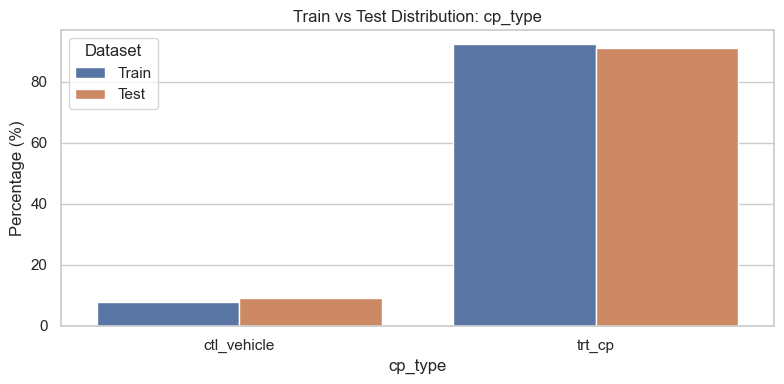

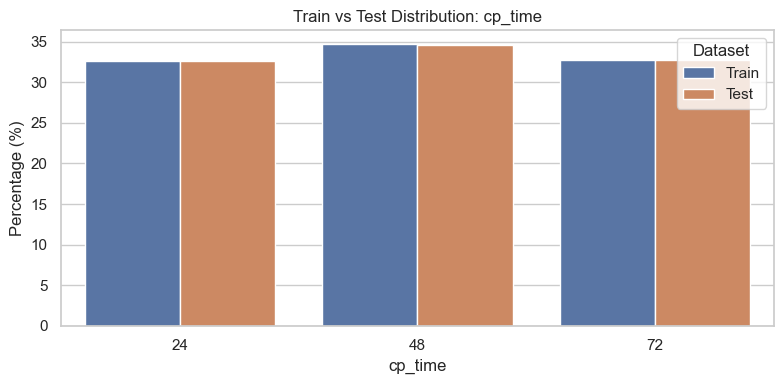

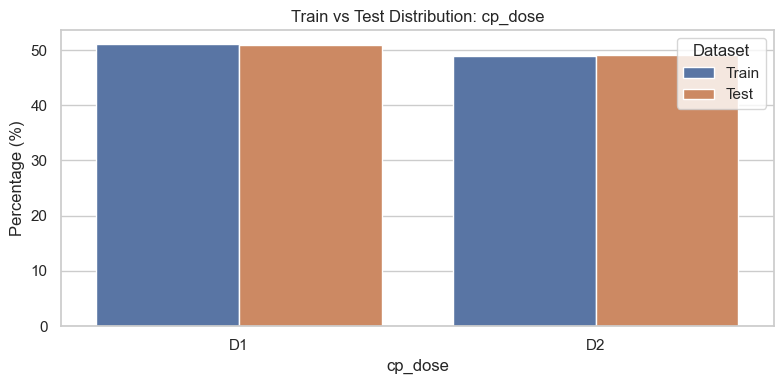

In [7]:
def plot_train_test_metadata_distribution(comparison_df, column):
    plot_df = comparison_df[comparison_df["metadata_column"] == column].copy()
    
    plot_df_long = plot_df.melt(
        id_vars=["category"],
        value_vars=["train_percent", "test_percent"],
        var_name="dataset",
        value_name="percentage"
    )
    
    plot_df_long["dataset"] = plot_df_long["dataset"].replace({
        "train_percent": "Train",
        "test_percent": "Test"
    })
    
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=plot_df_long,
        x="category",
        y="percentage",
        hue="dataset"
    )
    
    plt.title(f"Train vs Test Distribution: {column}")
    plt.xlabel(column)
    plt.ylabel("Percentage (%)")
    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.show()


for col in metadata_features:
    plot_train_test_metadata_distribution(metadata_distribution_comparison, col)

### 2.4 Metadata Analysis: Initial Insights

The metadata distribution comparison shows that train and test have very similar experimental setups.

The `cp_time` and `cp_dose` distributions are almost identical between train and test.  
The `cp_type` distribution has a small difference: test data contains slightly more control samples and slightly fewer treated samples compared with train data.

This difference is small and does not indicate a serious metadata shift.

Key decisions from this section:

- `cp_type`, `cp_time`, and `cp_dose` should be kept as important metadata features.
- These metadata columns should be encoded during feature engineering.
- `ctl_vehicle` control samples should be handled carefully because they have no active MoA targets.
- Interaction features such as `cp_time × cp_dose` may be useful and should be explored next.

### 2.5 Metadata Interaction Analysis

Now we analyze combinations of metadata features.

Single metadata columns looked balanced, but we also need to check whether combinations such as `cp_time × cp_dose` are balanced.

This helps us understand the experimental design more clearly and decide whether interaction features may be useful later.

In [8]:
metadata_interaction_pairs = [
    ("cp_time", "cp_dose"),
    ("cp_type", "cp_time"),
    ("cp_type", "cp_dose"),
]

interaction_tables = {}

for col1, col2 in metadata_interaction_pairs:
    interaction_name = f"{col1}_x_{col2}"
    
    interaction_table = (
        train_features
        .groupby([col1, col2])
        .size()
        .reset_index(name="train_count")
    )
    
    interaction_table["train_percent"] = (
        interaction_table["train_count"] / len(train_features) * 100
    )
    
    interaction_tables[interaction_name] = interaction_table
    
    print(f"\n{interaction_name}")
    display(interaction_table)


cp_time_x_cp_dose


,cp_time,cp_dose,train_count,train_percent
0,24,D1,3886,16.318132
1,24,D2,3886,16.318132
2,48,D1,4354,18.283363
3,48,D2,3896,16.360124
4,72,D1,3907,16.406316
5,72,D2,3885,16.313933



cp_type_x_cp_time


,cp_type,cp_time,train_count,train_percent
0,ctl_vehicle,24,606,2.544722
1,ctl_vehicle,48,648,2.721088
2,ctl_vehicle,72,612,2.569917
3,trt_cp,24,7166,30.091543
4,trt_cp,48,7602,31.922399
5,trt_cp,72,7180,30.150332



cp_type_x_cp_dose


,cp_type,cp_dose,train_count,train_percent
0,ctl_vehicle,D1,951,3.993449
1,ctl_vehicle,D2,915,3.842278
2,trt_cp,D1,11196,47.014361
3,trt_cp,D2,10752,45.149912


### 2.5.1 Train vs Test Metadata Interaction Comparison

Now we compare metadata interaction percentages between train and test.

This helps us check whether train and test have similar experimental combinations, not only similar individual metadata columns.

In [9]:
def interaction_distribution_table(train_df, test_df, col1, col2):
    train_dist = (
        train_df
        .groupby([col1, col2])
        .size()
        .reset_index(name="train_count")
    )
    train_dist["train_percent"] = train_dist["train_count"] / len(train_df) * 100

    test_dist = (
        test_df
        .groupby([col1, col2])
        .size()
        .reset_index(name="test_count")
    )
    test_dist["test_percent"] = test_dist["test_count"] / len(test_df) * 100

    table = train_dist.merge(
        test_dist,
        on=[col1, col2],
        how="outer"
    ).fillna(0)

    table["percent_difference"] = table["test_percent"] - table["train_percent"]
    table.insert(0, "interaction", f"{col1}_x_{col2}")

    return table


interaction_comparison_tables = []

for col1, col2 in metadata_interaction_pairs:
    interaction_comparison_tables.append(
        interaction_distribution_table(train_features, test_features, col1, col2)
    )

metadata_interaction_comparison = pd.concat(
    interaction_comparison_tables,
    axis=0,
    ignore_index=True
)

metadata_interaction_comparison

,interaction,cp_time,cp_dose,train_count,train_percent,test_count,test_percent,percent_difference,cp_type
0,cp_time_x_cp_dose,24.0,D1,3886,16.318132,648,16.273230,-0.044903,NaN
1,cp_time_x_cp_dose,24.0,D2,3886,16.318132,652,16.373682,0.055549,NaN
2,cp_time_x_cp_dose,48.0,D1,4354,18.283363,725,18.206931,-0.076432,NaN
3,cp_time_x_cp_dose,48.0,D2,3896,16.360124,652,16.373682,0.013557,NaN
4,cp_time_x_cp_dose,72.0,D1,3907,16.406316,654,16.423908,0.017592,NaN
5,cp_time_x_cp_dose,72.0,D2,3885,16.313933,651,16.348569,0.034636,NaN
6,cp_type_x_cp_time,24.0,NaN,606,2.544722,116,2.913109,0.368387,ctl_vehicle
7,cp_type_x_cp_time,48.0,NaN,648,2.721088,124,3.114013,0.392925,ctl_vehicle
8,cp_type_x_cp_time,72.0,NaN,612,2.569917,118,2.963335,0.393418,ctl_vehicle
9,cp_type_x_cp_time,24.0,NaN,7166,30.091543,1184,29.733802,-0.357741,trt_cp


### 2.5.2 Visualize Time-Dose Experimental Balance

The `cp_time × cp_dose` interaction is especially important because treatment time and dose may jointly affect biological response.

We visualize this interaction using heatmaps for train and test data.

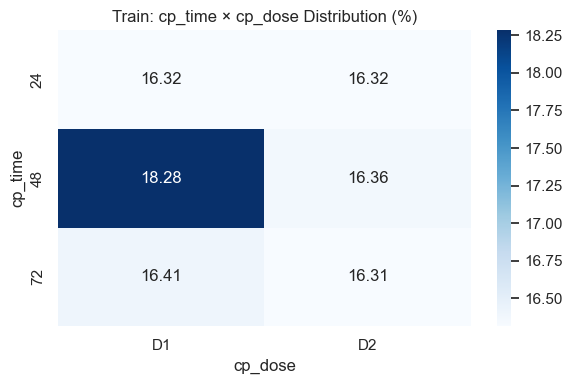

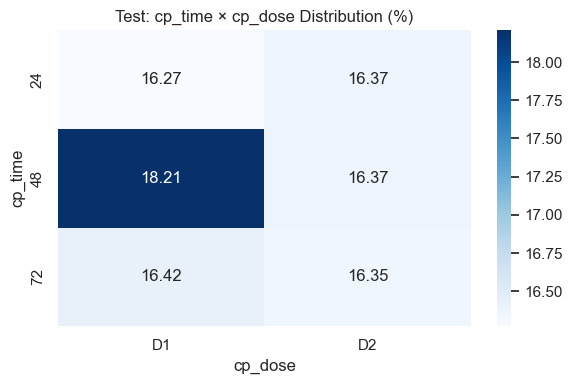

In [10]:
def plot_time_dose_heatmap(df, title):
    heatmap_data = (
        df
        .groupby(["cp_time", "cp_dose"])
        .size()
        .reset_index(name="count")
    )
    
    heatmap_data["percent"] = heatmap_data["count"] / len(df) * 100
    
    heatmap_pivot = heatmap_data.pivot(
        index="cp_time",
        columns="cp_dose",
        values="percent"
    )
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        heatmap_pivot,
        annot=True,
        fmt=".2f",
        cmap="Blues"
    )
    plt.title(title)
    plt.xlabel("cp_dose")
    plt.ylabel("cp_time")
    plt.tight_layout()
    plt.show()


plot_time_dose_heatmap(train_features, "Train: cp_time × cp_dose Distribution (%)")
plot_time_dose_heatmap(test_features, "Test: cp_time × cp_dose Distribution (%)")

### 2.6 Metadata Interaction Insights and Decisions

The metadata interaction analysis shows that the experimental design is mostly balanced between train and test.

The `cp_time × cp_dose` heatmaps are especially useful because treatment duration and dose may jointly affect biological response. Both train and test show very similar time-dose patterns. The `48 × D1` group is slightly larger than the other time-dose combinations, but this pattern appears in both train and test, so it does not indicate a serious train-test shift.

The `cp_type × cp_time` and `cp_type × cp_dose` combinations also show the expected structure. Control samples are a small portion of the dataset and are distributed across time and dose conditions. Test data has slightly more control samples than train data, but the difference is small.

Main conclusions:

- Metadata combinations are consistent between train and test.
- There is no strong experimental-design distribution shift.
- `cp_time × cp_dose` may be useful as an interaction feature.
- `cp_type` should be kept because it separates treated and control samples.
- Control samples should be handled carefully during final prediction because they have no active MoA targets.

## 3. Scored Target Behavior and Multi-Label Structure

The scored target matrix contains the main MoA labels that the model must predict.

Each column represents one scored MoA target, and each row represents one sample.

This is a multi-label classification problem because a sample can have zero, one, or multiple active target labels.

In this section, we analyze:

- target sparsity,
- target imbalance,
- target frequency,
- sample-level multi-label behavior,
- and how target activity changes under experimental conditions.

The goal is to convert target analysis into useful modeling and feature engineering decisions.

### 3.1 Target Matrix Sparsity Overview

Before analyzing individual targets, we first examine the full scored target matrix.

This helps us understand the overall label structure:

- how many samples exist,
- how many scored targets exist,
- how many total label entries exist,
- how many labels are positive,
- how many labels are negative,
- and how sparse the target matrix is.

This is important because sparse multi-label targets require probability-based models and careful validation.

In [11]:
scored_target_features

['5-alpha_reductase_inhibitor',
 '11-beta-hsd1_inhibitor',
 'acat_inhibitor',
 'acetylcholine_receptor_agonist',
 'acetylcholine_receptor_antagonist',
 'acetylcholinesterase_inhibitor',
 'adenosine_receptor_agonist',
 'adenosine_receptor_antagonist',
 'adenylyl_cyclase_activator',
 'adrenergic_receptor_agonist',
 'adrenergic_receptor_antagonist',
 'akt_inhibitor',
 'aldehyde_dehydrogenase_inhibitor',
 'alk_inhibitor',
 'ampk_activator',
 'analgesic',
 'androgen_receptor_agonist',
 'androgen_receptor_antagonist',
 'anesthetic_-_local',
 'angiogenesis_inhibitor',
 'angiotensin_receptor_antagonist',
 'anti-inflammatory',
 'antiarrhythmic',
 'antibiotic',
 'anticonvulsant',
 'antifungal',
 'antihistamine',
 'antimalarial',
 'antioxidant',
 'antiprotozoal',
 'antiviral',
 'apoptosis_stimulant',
 'aromatase_inhibitor',
 'atm_kinase_inhibitor',
 'atp-sensitive_potassium_channel_antagonist',
 'atp_synthase_inhibitor',
 'atpase_inhibitor',
 'atr_kinase_inhibitor',
 'aurora_kinase_inhibitor',
 '

In [12]:
# Create the scored target matrix without sig_id
y_scored_matrix = y_scored[scored_target_features].copy()

n_samples = y_scored_matrix.shape[0]
n_targets = y_scored_matrix.shape[1]

total_label_entries = n_samples * n_targets
total_positive_labels = int(y_scored_matrix.values.sum())
total_negative_labels = int(total_label_entries - total_positive_labels)

positive_label_percentage = total_positive_labels / total_label_entries * 100
negative_label_percentage = total_negative_labels / total_label_entries * 100
sparsity_percentage = negative_label_percentage

target_matrix_summary = pd.DataFrame({
    "metric": [
        "Number of samples",
        "Number of scored targets",
        "Total label entries",
        "Total positive labels",
        "Total negative labels",
        "Positive label percentage",
        "Sparsity percentage"
    ],
    "value": [
        n_samples,
        n_targets,
        total_label_entries,
        total_positive_labels,
        total_negative_labels,
        round(positive_label_percentage, 4),
        round(sparsity_percentage, 4)
    ]
})

target_matrix_summary

,metric,value
0,Number of samples,2.381400e+04
1,Number of scored targets,2.060000e+02
2,Total label entries,4.905684e+06
3,Total positive labels,1.684400e+04
4,Total negative labels,4.888840e+06
5,Positive label percentage,3.434000e-01
6,Sparsity percentage,9.965660e+01


### 3.1.2 Positive vs Negative Label Balance

Now we visualize the proportion of positive and negative target labels.

Because the target matrix is expected to be highly sparse, this plot helps show the imbalance clearly.

We use percentages instead of raw counts so the imbalance is easier to interpret.

In [13]:
target_balance_table = pd.DataFrame({
    "label_type": ["Positive labels", "Negative labels"],
    "count": [total_positive_labels, total_negative_labels],
    "percentage": [positive_label_percentage, negative_label_percentage]
})

target_balance_table

,label_type,count,percentage
0,Positive labels,16844,0.343357
1,Negative labels,4888840,99.656643


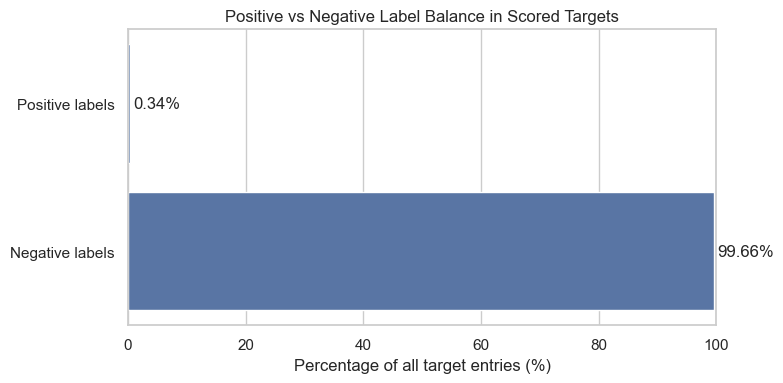

In [14]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=target_balance_table,
    x="percentage",
    y="label_type"
)

plt.title("Positive vs Negative Label Balance in Scored Targets")
plt.xlabel("Percentage of all target entries (%)")
plt.ylabel("")
plt.xlim(0, 100)

for index, row in target_balance_table.iterrows():
    plt.text(
        row["percentage"] + 0.5,
        index,
        f'{row["percentage"]:.2f}%',
        va="center"
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_1_target_label_balance.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.1.3 Initial Modeling Implications

The scored target matrix is extremely sparse.

Only **0.3434%** of all target entries are positive, while **99.6566%** are negative. This means most MoA targets are inactive for most samples.

This has important modeling implications:

- simple accuracy is not useful because a model could predict mostly zeros and still look good,
- the model must predict probabilities for each target, not only hard class labels,
- rare positive labels will be difficult to learn,
- validation must preserve multi-label structure as much as possible,
- probability calibration and prediction clipping may be important during final modeling,
- neural networks should use sigmoid outputs, not softmax, because multiple targets can be active at the same time.

This confirms that the project should be treated as a sparse multi-label classification problem.

In [15]:
target_matrix_implication_table = pd.DataFrame({
    "finding": [
        "The scored target matrix contains 206 target labels",
        "Only 0.3434% of all target entries are positive",
        "99.6566% of all target entries are negative",
        "The target matrix is extremely sparse",
        "This is a multi-label classification problem"
    ],
    "evidence_from_output": [
        "There are 206 scored target columns",
        "Total positive labels = 16,844 out of 4,905,684 entries",
        "Total negative labels = 4,888,840 out of 4,905,684 entries",
        "Most target values are zero",
        "Each sample can have zero, one, or multiple active MoA labels"
    ],
    "modeling_decision": [
        "Use multi-output / multi-label modeling",
        "Do not use accuracy as the main metric",
        "Use probability-based metrics such as log loss",
        "Use careful validation and monitor rare targets later",
        "Use sigmoid outputs for neural networks, not softmax"
    ]
})

target_matrix_implication_table

,finding,evidence_from_output,modeling_decision
0,The scored target matrix contains 206 target l...,There are 206 scored target columns,Use multi-output / multi-label modeling
1,Only 0.3434% of all target entries are positive,"Total positive labels = 16,844 out of 4,905,68...",Do not use accuracy as the main metric
2,99.6566% of all target entries are negative,"Total negative labels = 4,888,840 out of 4,905...",Use probability-based metrics such as log loss
3,The target matrix is extremely sparse,Most target values are zero,Use careful validation and monitor rare target...
4,This is a multi-label classification problem,"Each sample can have zero, one, or multiple ac...","Use sigmoid outputs for neural networks, not s..."


### 3.2 Target Frequency and Imbalance Analysis

After understanding the overall sparsity of the scored target matrix, we now analyze target-level imbalance.

Each scored target column represents one MoA label. Some targets may appear frequently, while others may appear only a few times.

This section helps us identify:

- frequent targets,
- rare targets,
- target frequency distribution,
- and target groups based on positive sample count.

This is important because rare targets are harder to learn and may require careful validation and target-wise error analysis later.

#### 3.2.1 Positive Count per Target

First, we calculate how many positive samples exist for each of the 206 scored targets.

This gives us a target-level frequency table, which will be used for imbalance analysis.

In [16]:
target_frequency_table = pd.DataFrame({
    "target": scored_target_features,
    "positive_count": y_scored_matrix.sum(axis=0).values
})

target_frequency_table["negative_count"] = n_samples - target_frequency_table["positive_count"]
target_frequency_table["positive_percentage"] = (
    target_frequency_table["positive_count"] / n_samples * 100
)

target_frequency_table = target_frequency_table.sort_values(
    by="positive_count",
    ascending=False
).reset_index(drop=True)

target_frequency_table

,target,positive_count,negative_count,positive_percentage
0,nfkb_inhibitor,832,22982,3.493743
1,proteasome_inhibitor,726,23088,3.048627
2,cyclooxygenase_inhibitor,435,23379,1.826657
3,dopamine_receptor_antagonist,424,23390,1.780465
4,serotonin_receptor_antagonist,404,23410,1.696481
...,...,...,...,...
201,protein_phosphatase_inhibitor,6,23808,0.025195
202,ubiquitin_specific_protease_inhibitor,6,23808,0.025195
203,steroid,6,23808,0.025195
204,atp-sensitive_potassium_channel_antagonist,1,23813,0.004199


#### 3.2.2 Target Frequency Summary

Now we summarize the distribution of positive counts across all scored targets.

This tells us whether most targets are rare or whether positive samples are evenly distributed across targets.

In [17]:
target_frequency_summary = target_frequency_table["positive_count"].describe().to_frame(
    name="positive_count_summary"
)

target_frequency_summary

,positive_count_summary
count,206.000000
mean,81.766990
std,115.160351
min,1.000000
25%,19.000000
50%,38.500000
75%,83.000000
max,832.000000


#### 3.2.3 Distribution of Target Positive Counts

This plot shows how positive samples are distributed across the 206 scored targets.

A right-skewed distribution means that only a few targets are frequent, while many targets are rare.

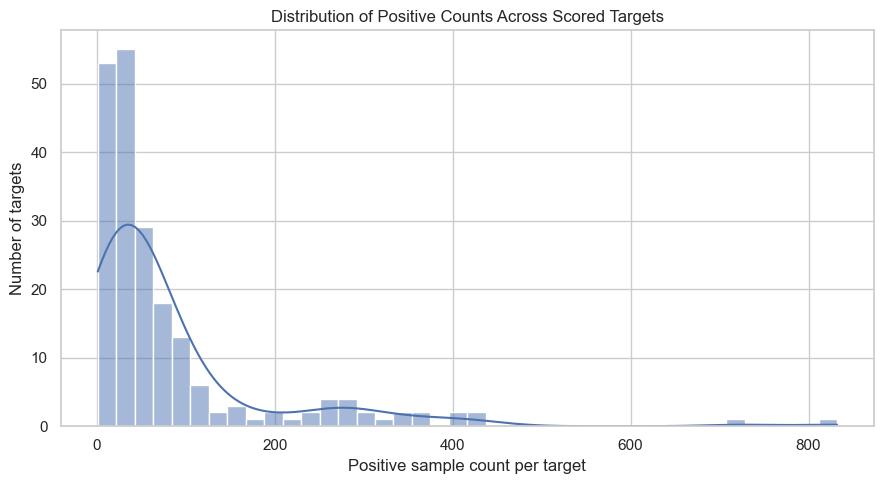

In [18]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=target_frequency_table,
    x="positive_count",
    bins=40,
    kde=True
)

plt.title("Distribution of Positive Counts Across Scored Targets")
plt.xlabel("Positive sample count per target")
plt.ylabel("Number of targets")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_2_target_positive_count_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.2.4 Top 30 Most Frequent Targets

Now we visualize the most frequent scored targets.

Frequent targets usually have more training examples and may be easier for models to learn compared with rare targets.

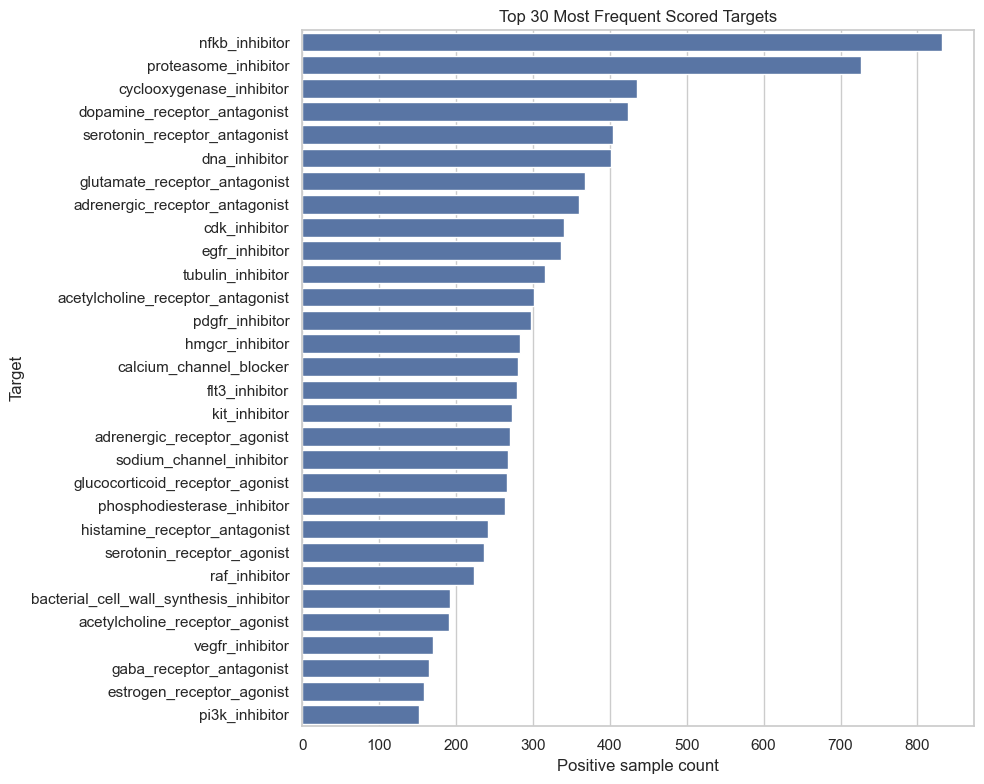

In [19]:
top_30_targets = target_frequency_table.head(30).copy()

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_30_targets,
    x="positive_count",
    y="target"
)

plt.title("Top 30 Most Frequent Scored Targets")
plt.xlabel("Positive sample count")
plt.ylabel("Target")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_2_top_30_frequent_targets.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.2.5 Rarest Targets

Now we inspect the rarest scored targets.

Rare targets have very few positive examples, which can make them difficult for the model to learn reliably.

In [20]:
rarest_20_targets = target_frequency_table.tail(20).sort_values(
    by="positive_count",
    ascending=True
).reset_index(drop=True)

rarest_20_targets

,target,positive_count,negative_count,positive_percentage
0,atp-sensitive_potassium_channel_antagonist,1,23813,0.004199
1,erbb2_inhibitor,1,23813,0.004199
2,atm_kinase_inhibitor,6,23808,0.025195
3,autotaxin_inhibitor,6,23808,0.025195
4,calcineurin_inhibitor,6,23808,0.025195
5,coagulation_factor_inhibitor,6,23808,0.025195
6,diuretic,6,23808,0.025195
7,retinoid_receptor_antagonist,6,23808,0.025195
8,tropomyosin_receptor_kinase_inhibitor,6,23808,0.025195
9,nicotinic_receptor_agonist,6,23808,0.025195


#### 3.2.6 Target Frequency Groups

To make target imbalance easier to understand, we group targets by positive sample count.

This helps us estimate how many targets are very rare, rare, medium-frequency, or frequent.

In [21]:
def assign_target_frequency_group(positive_count):
    if positive_count < 10:
        return "Very rare (<10)"
    elif positive_count < 50:
        return "Rare (10-49)"
    elif positive_count < 200:
        return "Medium (50-199)"
    else:
        return "Frequent (>=200)"


target_frequency_table["frequency_group"] = target_frequency_table["positive_count"].apply(
    assign_target_frequency_group
)

target_frequency_group_summary = (
    target_frequency_table
    .groupby("frequency_group")
    .agg(
        number_of_targets=("target", "count"),
        min_positive_count=("positive_count", "min"),
        median_positive_count=("positive_count", "median"),
        max_positive_count=("positive_count", "max")
    )
    .reset_index()
)

frequency_group_order = [
    "Very rare (<10)",
    "Rare (10-49)",
    "Medium (50-199)",
    "Frequent (>=200)"
]

target_frequency_group_summary["frequency_group"] = pd.Categorical(
    target_frequency_group_summary["frequency_group"],
    categories=frequency_group_order,
    ordered=True
)

target_frequency_group_summary = target_frequency_group_summary.sort_values(
    "frequency_group"
).reset_index(drop=True)

target_frequency_group_summary

,frequency_group,number_of_targets,min_positive_count,median_positive_count,max_positive_count
0,Very rare (<10),22,1,6.0,7
1,Rare (10-49),97,12,26.0,49
2,Medium (50-199),63,50,74.0,192
3,Frequent (>=200),24,223,299.0,832


#### 3.2.7 Visualize Target Frequency Groups

This plot summarizes target imbalance at a higher level.

Instead of looking at 206 targets one by one, we can see how many targets belong to each frequency group.

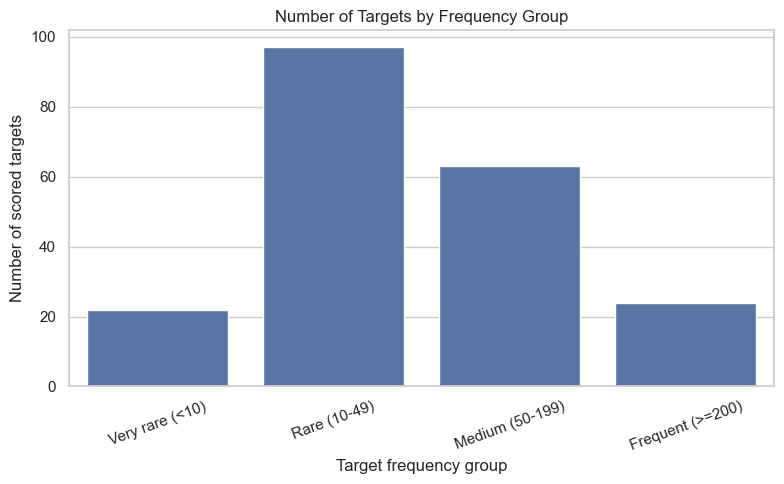

In [22]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=target_frequency_group_summary,
    x="frequency_group",
    y="number_of_targets"
)

plt.title("Number of Targets by Frequency Group")
plt.xlabel("Target frequency group")
plt.ylabel("Number of scored targets")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_2_target_frequency_groups.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.2.8 Target Frequency Insights

The target frequency analysis shows strong imbalance across the 206 scored MoA labels.

Most targets have relatively low positive sample counts, while only a small number of targets have many positive examples. The distribution is clearly right-skewed: many targets are concentrated in the low-frequency range, and only a few targets appear very frequently.

The top frequent targets, such as `nfkb_inhibitor` and `proteasome_inhibitor`, have substantially more positive samples than most other targets. This means these labels may be easier for models to learn compared with rare labels.

The frequency group plot also shows that many targets belong to rare or medium-frequency groups, while only a smaller portion of targets are highly frequent. This confirms that target imbalance is not only a global sparsity issue, but also a target-level imbalance issue.

Key implications:

- rare targets may be difficult to learn because they have limited positive examples,
- frequent targets may dominate the model's learning signal,
- model evaluation should include target-wise error analysis later,
- validation should preserve multi-label structure as much as possible,
- rare targets should not be removed because they are part of the official scored prediction task.

### 3.3 Sample-Level Multi-Label Behavior

After analyzing target-level frequency, we now analyze the labels from a sample-level perspective.

For each sample, we count how many scored MoA targets are active.

This helps us understand:

- how many samples have no active scored target,
- how many samples have exactly one active target,
- how many samples have multiple active targets,
- and the maximum number of active targets in one sample.

This section is important because it confirms that the problem is multi-label, not multiclass.

#### 3.3.1 Active Target Count per Sample

For each sample, we calculate the number of active scored targets.

This new temporary column is called `active_target_count`.

It is used only for EDA and will not be used directly as a model feature.

In [23]:
sample_target_activity = pd.DataFrame({
    ID_COL: y_scored[ID_COL],
    "active_target_count": y_scored_matrix.sum(axis=1)
})

sample_target_activity

,sig_id,active_target_count
0,id_000644bb2,1
1,id_000779bfc,0
2,id_000a6266a,3
3,id_0015fd391,0
4,id_001626bd3,1
...,...,...
23809,id_fffb1ceed,1
23810,id_fffb70c0c,1
23811,id_fffc1c3f4,0
23812,id_fffcb9e7c,1


#### 3.3.2 Active Target Count Distribution

Now we summarize how many samples have 0, 1, 2, or more active scored targets.

This helps us understand the sample-level multi-label structure of the dataset.

In [24]:
active_target_count_distribution = (
    sample_target_activity["active_target_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

active_target_count_distribution.columns = [
    "active_target_count",
    "sample_count"
]

active_target_count_distribution["sample_percentage"] = (
    active_target_count_distribution["sample_count"] / n_samples * 100
)

active_target_count_distribution

,active_target_count,sample_count,sample_percentage
0,0,9367,39.334005
1,1,12532,52.624507
2,2,1538,6.458386
3,3,303,1.272361
4,4,55,0.230957
5,5,13,0.054590
6,7,6,0.025195


#### 3.3.3 Visualize Active Target Count per Sample

This plot shows the distribution of active scored targets per sample.

It helps us visually confirm whether most samples have zero labels, one label, or multiple labels.

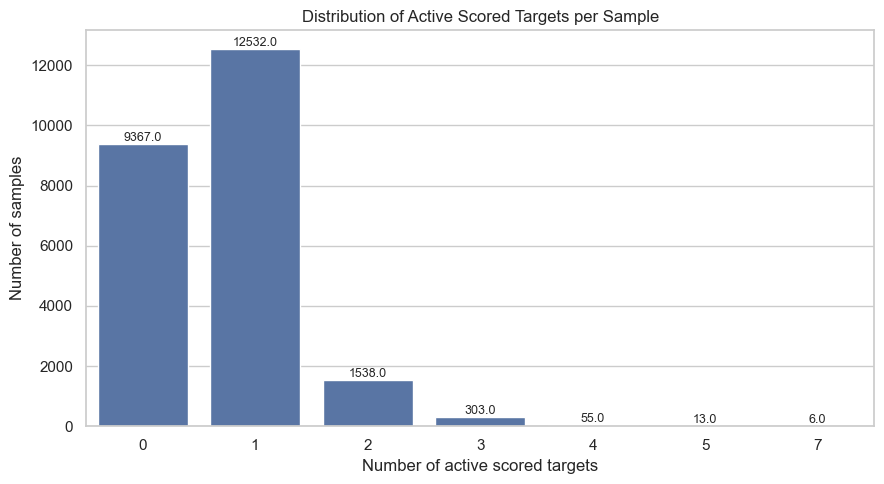

In [25]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=active_target_count_distribution,
    x="active_target_count",
    y="sample_count"
)

plt.title("Distribution of Active Scored Targets per Sample")
plt.xlabel("Number of active scored targets")
plt.ylabel("Number of samples")

for index, row in active_target_count_distribution.iterrows():
    plt.text(
        index,
        row["sample_count"],
        f'{row["sample_count"]}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_3_active_targets_per_sample.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.3.4 Zero-Label, Single-Label, and Multi-Label Summary

To make the sample-level label structure easier to interpret, we group samples into three categories:

- zero-label samples: no active scored target,
- single-label samples: exactly one active scored target,
- multi-label samples: more than one active scored target.

This summary clearly shows why the task requires multi-label modeling.

In [26]:
zero_label_count = int((sample_target_activity["active_target_count"] == 0).sum())
single_label_count = int((sample_target_activity["active_target_count"] == 1).sum())
multi_label_count = int((sample_target_activity["active_target_count"] > 1).sum())

sample_label_type_summary = pd.DataFrame({
    "sample_label_type": [
        "Zero-label samples",
        "Single-label samples",
        "Multi-label samples"
    ],
    "sample_count": [
        zero_label_count,
        single_label_count,
        multi_label_count
    ]
})

sample_label_type_summary["sample_percentage"] = (
    sample_label_type_summary["sample_count"] / n_samples * 100
)

sample_label_type_summary

,sample_label_type,sample_count,sample_percentage
0,Zero-label samples,9367,39.334005
1,Single-label samples,12532,52.624507
2,Multi-label samples,1915,8.041488


#### 3.3.5 Sample-Level Label Cardinality Summary

Now we calculate several compact statistics for sample-level label cardinality.

This helps summarize the multi-label structure in one place.

In [27]:
sample_label_cardinality_summary = {
    "total_samples": int(n_samples),
    "zero_label_samples": zero_label_count,
    "single_label_samples": single_label_count,
    "multi_label_samples": multi_label_count,
    "zero_label_percentage": round(zero_label_count / n_samples * 100, 4),
    "single_label_percentage": round(single_label_count / n_samples * 100, 4),
    "multi_label_percentage": round(multi_label_count / n_samples * 100, 4),
    "mean_active_targets_per_sample": round(sample_target_activity["active_target_count"].mean(), 4),
    "median_active_targets_per_sample": round(sample_target_activity["active_target_count"].median(), 4),
    "max_active_targets_in_one_sample": int(sample_target_activity["active_target_count"].max()),
}

sample_label_cardinality_summary

{'total_samples': 23814,
 'zero_label_samples': 9367,
 'single_label_samples': 12532,
 'multi_label_samples': 1915,
 'zero_label_percentage': 39.334,
 'single_label_percentage': 52.6245,
 'multi_label_percentage': 8.0415,
 'mean_active_targets_per_sample': np.float64(0.7073),
 'median_active_targets_per_sample': np.float64(1.0),
 'max_active_targets_in_one_sample': 7}

#### 3.3.6 Multi-Label Modeling Implications

The sample-level target analysis confirms that this is a multi-label classification problem.

Out of 23,814 training samples:

- 9,367 samples have no active scored target.
- 12,532 samples have exactly one active scored target.
- 1,915 samples have more than one active scored target.

This means 39.3340% of samples are zero-label samples, 52.6245% are single-label samples, and 8.0415% are true multi-label samples.

The average number of active scored targets per sample is only 0.7073, while the maximum number of active scored targets in one sample is 7. This shows that the target matrix is sparse not only at the target-entry level, but also at the sample level.

Modeling implications:

- zero-label samples are valid and should not be removed,
- the model should not be trained as a multiclass classifier,
- softmax output is not appropriate because targets are not mutually exclusive,
- neural networks should use one sigmoid output per target,
- classical models should use multi-output or one-vs-rest style training,
- validation should preserve the multi-label structure as much as possible.

In [28]:
sample_label_insight_table = pd.DataFrame({
    "finding": [
        "A large portion of samples have no active scored target",
        "Most labeled samples have exactly one active scored target",
        "A smaller but important group has multiple active targets",
        "The average active target count per sample is below 1",
        "Some samples have up to 7 active scored targets",
        "The task is multi-label, not multiclass"
    ],
    "evidence_from_eda": [
        "9,367 samples, or 39.3340%, have active_target_count = 0",
        "12,532 samples, or 52.6245%, have active_target_count = 1",
        "1,915 samples, or 8.0415%, have active_target_count > 1",
        "Mean active targets per sample = 0.7073",
        "Maximum active targets in one sample = 7",
        "Samples can have zero, one, or multiple active labels"
    ],
    "modeling_decision": [
        "Keep zero-label samples during training",
        "Use binary target columns instead of a single class label",
        "Use multi-label models that predict one probability per target",
        "Expect strong sparsity at the sample level",
        "Use sigmoid outputs instead of softmax for neural networks",
        "Use probability-based multi-label evaluation such as log loss"
    ]
})

sample_label_insight_table

,finding,evidence_from_eda,modeling_decision
0,A large portion of samples have no active scor...,"9,367 samples, or 39.3340%, have active_target...",Keep zero-label samples during training
1,Most labeled samples have exactly one active s...,"12,532 samples, or 52.6245%, have active_targe...",Use binary target columns instead of a single ...
2,A smaller but important group has multiple act...,"1,915 samples, or 8.0415%, have active_target_...",Use multi-label models that predict one probab...
3,The average active target count per sample is ...,Mean active targets per sample = 0.7073,Expect strong sparsity at the sample level
4,Some samples have up to 7 active scored targets,Maximum active targets in one sample = 7,Use sigmoid outputs instead of softmax for neu...
5,"The task is multi-label, not multiclass","Samples can have zero, one, or multiple active...",Use probability-based multi-label evaluation s...


### 3.4 Target Activity under Experimental Conditions

In the previous sections, we analyzed target sparsity, target frequency imbalance, and sample-level multi-label behavior.

Now we examine whether target activity changes under different experimental conditions.

We analyze target activity using:

- `cp_type`: treatment type,
- `cp_time`: treatment duration,
- `cp_dose`: treatment dose,
- `cp_time × cp_dose`: time-dose interaction.

For `cp_time`, `cp_dose`, and `cp_time × cp_dose`, we focus mainly on treated samples (`trt_cp`) because control samples have no active MoA targets and can dilute the treatment-specific signal.

This section helps decide whether metadata and interaction features should be used during feature engineering.

#### 3.4.1 Create Target Activity Metadata Table

First, we combine metadata columns with the sample-level active target count.

This creates a temporary EDA table that allows us to compare target activity across experimental conditions.

This table is only for analysis. The `active_target_count` column is derived from the target labels and must not be used as an input feature during model training.

In [29]:
target_activity_metadata = train_features[
    [ID_COL, "cp_type", "cp_time", "cp_dose"]
].merge(
    sample_target_activity,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)

target_activity_metadata.head()

,sig_id,cp_type,cp_time,cp_dose,active_target_count
0,id_000644bb2,trt_cp,24,D1,1
1,id_000779bfc,trt_cp,72,D1,0
2,id_000a6266a,trt_cp,48,D1,3
3,id_0015fd391,trt_cp,48,D1,0
4,id_001626bd3,trt_cp,72,D2,1


In [30]:
target_activity_metadata_check = {
    "rows": target_activity_metadata.shape[0],
    "columns": target_activity_metadata.shape[1],
    "missing_active_target_count": int(target_activity_metadata["active_target_count"].isna().sum()),
    "min_active_target_count": int(target_activity_metadata["active_target_count"].min()),
    "max_active_target_count": int(target_activity_metadata["active_target_count"].max()),
}

target_activity_metadata_check

{'rows': 23814,
 'columns': 5,
 'missing_active_target_count': 0,
 'min_active_target_count': 0,
 'max_active_target_count': 7}

#### 3.4.2 Target Activity by `cp_type`

Now we compare target activity between control samples and treated compound samples.

This is important because control samples are expected to have zero active scored targets.

If this pattern holds, it supports using control-sample post-processing later during final prediction.

In [31]:
cp_type_target_activity = (
    target_activity_metadata
    .groupby("cp_type")
    .agg(
        sample_count=(ID_COL, "count"),
        total_active_targets=("active_target_count", "sum"),
        mean_active_targets=("active_target_count", "mean"),
        median_active_targets=("active_target_count", "median"),
        max_active_targets=("active_target_count", "max")
    )
    .reset_index()
)

cp_type_target_activity

,cp_type,sample_count,total_active_targets,mean_active_targets,median_active_targets,max_active_targets
0,ctl_vehicle,1866,0,0.00000,0.0,0
1,trt_cp,21948,16844,0.76745,1.0,7


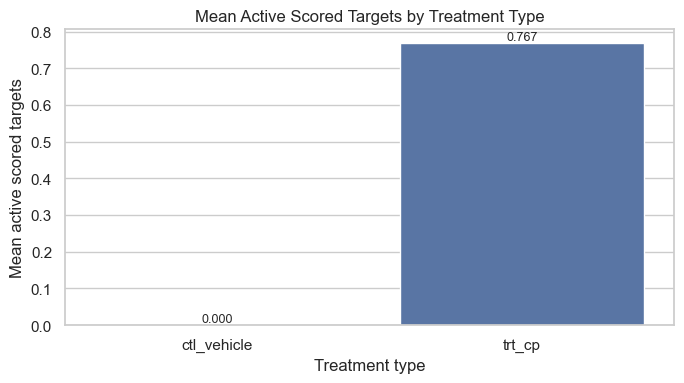

In [32]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=cp_type_target_activity,
    x="cp_type",
    y="mean_active_targets"
)

plt.title("Mean Active Scored Targets by Treatment Type")
plt.xlabel("Treatment type")
plt.ylabel("Mean active scored targets")

for index, row in cp_type_target_activity.iterrows():
    plt.text(
        index,
        row["mean_active_targets"],
        f'{row["mean_active_targets"]:.3f}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_4_target_activity_by_cp_type.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.4.3 Target Activity by `cp_time` and `cp_dose`

Next, we analyze target activity by treatment duration and treatment dose.

For this analysis, we focus on treated samples only (`cp_type == "trt_cp"`). This avoids mixing control samples, which have zero active targets by design.

This helps us check whether time and dose are related to the number of active MoA labels.

In [33]:
treated_target_activity = target_activity_metadata[
    target_activity_metadata["cp_type"] == "trt_cp"
].copy()

treated_target_activity.shape

(21948, 5)

In [34]:
def summarize_target_activity_by_group(df, group_col):
    summary = (
        df
        .groupby(group_col)
        .agg(
            sample_count=(ID_COL, "count"),
            mean_active_targets=("active_target_count", "mean"),
            median_active_targets=("active_target_count", "median"),
            max_active_targets=("active_target_count", "max")
        )
        .reset_index()
    )
    
    return summary


cp_time_target_activity = summarize_target_activity_by_group(
    treated_target_activity,
    "cp_time"
)

cp_dose_target_activity = summarize_target_activity_by_group(
    treated_target_activity,
    "cp_dose"
)

display(cp_time_target_activity)
display(cp_dose_target_activity)

,cp_time,sample_count,mean_active_targets,median_active_targets,max_active_targets
0,24,7166,0.766816,1.0,7
1,48,7602,0.766772,1.0,7
2,72,7180,0.768802,1.0,7


,cp_dose,sample_count,mean_active_targets,median_active_targets,max_active_targets
0,D1,11196,0.768221,1.0,7
1,D2,10752,0.766648,1.0,7


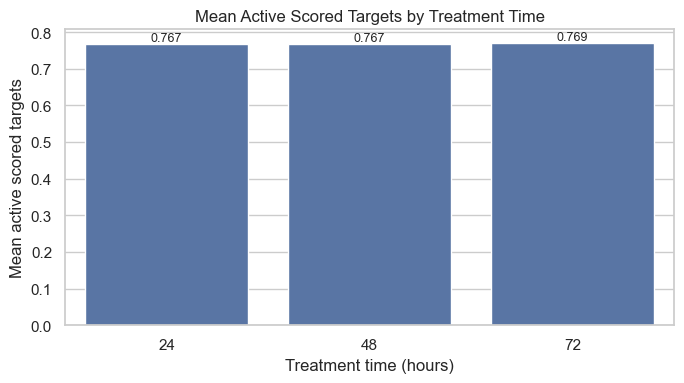

In [35]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=cp_time_target_activity,
    x="cp_time",
    y="mean_active_targets"
)

plt.title("Mean Active Scored Targets by Treatment Time")
plt.xlabel("Treatment time (hours)")
plt.ylabel("Mean active scored targets")

for index, row in cp_time_target_activity.iterrows():
    plt.text(
        index,
        row["mean_active_targets"],
        f'{row["mean_active_targets"]:.3f}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_4_target_activity_by_cp_time.png", dpi=300, bbox_inches="tight")
plt.show()

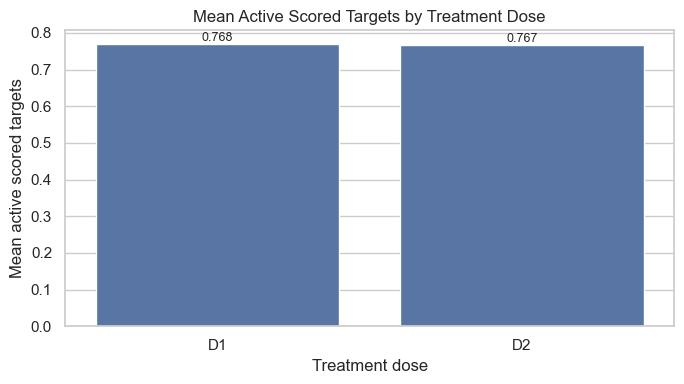

In [36]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=cp_dose_target_activity,
    x="cp_dose",
    y="mean_active_targets"
)

plt.title("Mean Active Scored Targets by Treatment Dose")
plt.xlabel("Treatment dose")
plt.ylabel("Mean active scored targets")

for index, row in cp_dose_target_activity.iterrows():
    plt.text(
        index,
        row["mean_active_targets"],
        f'{row["mean_active_targets"]:.3f}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_4_target_activity_by_cp_dose.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.4.4 Target Activity by `cp_time × cp_dose`

Now we analyze the interaction between treatment time and dose.

This is useful because dose effects may depend on treatment duration.

If target activity differs across time-dose combinations, then a `cp_time × cp_dose` interaction feature may be useful in feature engineering.

In [37]:
time_dose_target_activity = (
    treated_target_activity
    .groupby(["cp_time", "cp_dose"])
    .agg(
        sample_count=(ID_COL, "count"),
        mean_active_targets=("active_target_count", "mean"),
        median_active_targets=("active_target_count", "median"),
        max_active_targets=("active_target_count", "max")
    )
    .reset_index()
)

time_dose_target_activity

,cp_time,cp_dose,sample_count,mean_active_targets,median_active_targets,max_active_targets
0,24,D1,3585,0.768201,1.0,7
1,24,D2,3581,0.765429,1.0,7
2,48,D1,4011,0.765894,1.0,7
3,48,D2,3591,0.767753,1.0,7
4,72,D1,3600,0.770833,1.0,7
5,72,D2,3580,0.766760,1.0,7


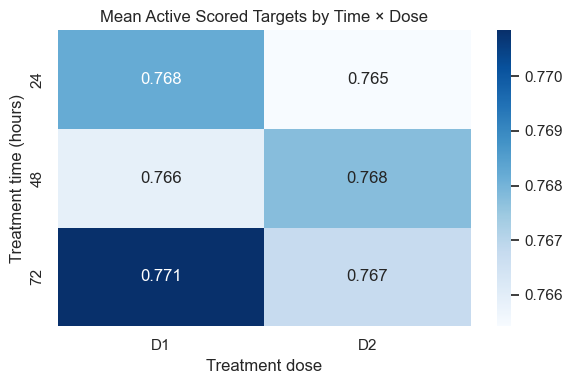

In [38]:
time_dose_activity_pivot = time_dose_target_activity.pivot(
    index="cp_time",
    columns="cp_dose",
    values="mean_active_targets"
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    time_dose_activity_pivot,
    annot=True,
    fmt=".3f",
    cmap="Blues"
)

plt.title("Mean Active Scored Targets by Time × Dose")
plt.xlabel("Treatment dose")
plt.ylabel("Treatment time (hours)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_4_target_activity_time_dose_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.4.5 Target Activity under Experimental Conditions: Insights

The target activity analysis shows that `cp_type` is the strongest metadata signal for scored target activity.

Control samples (`ctl_vehicle`) have a mean active target count of **0.000**, while treated compound samples (`trt_cp`) have a mean active target count of about **0.767**. This confirms the expected structural behavior of the dataset: control samples do not have active scored MoA targets.

For treated samples, target activity is very stable across treatment time and dose. The mean active target count is almost identical across `cp_time` values:

- 24 hours: about **0.767**
- 48 hours: about **0.767**
- 72 hours: about **0.769**

Similarly, target activity is nearly identical between dose groups:

- D1: about **0.768**
- D2: about **0.767**

The `cp_time × cp_dose` heatmap also shows only very small differences, with all groups staying close to **0.765–0.771**. This suggests that time and dose do not strongly change the average number of active scored targets.

Key conclusions:

- `cp_type` is essential because it separates control and treated samples.
- `ctl_vehicle` rows should be post-processed to zero predictions in the final submission.
- `cp_time` and `cp_dose` should still be kept as model features because they may affect the gene and cell response patterns, even if the average target count is similar.
- The `cp_time × cp_dose` interaction can be tested during feature engineering, but current target-count evidence suggests it may provide only limited direct signal.
- We should not over-interpret the small differences between time and dose groups.

In [39]:
metadata_target_activity_insight_table = pd.DataFrame({
    "finding": [
        "cp_type is strongly related to target activity",
        "Control samples have no active scored targets",
        "Treated samples show nonzero target activity",
        "Target activity is very stable across cp_time",
        "Target activity is very stable across cp_dose",
        "cp_time × cp_dose shows only tiny differences"
    ],
    "evidence_from_eda": [
        "ctl_vehicle mean active targets = 0.000, trt_cp mean active targets ≈ 0.767",
        "The cp_type plot shows zero mean target activity for ctl_vehicle",
        "trt_cp samples have mean active target count around 0.767",
        "24h, 48h, and 72h all have mean active target counts around 0.767–0.769",
        "D1 and D2 both have mean active target counts around 0.767–0.768",
        "All time-dose combinations are close to 0.765–0.771"
    ],
    "feature_engineering_or_modeling_decision": [
        "Keep cp_type as an important metadata feature",
        "Apply control-sample post-processing during final prediction",
        "Use treated samples for treatment-specific biological analysis",
        "Keep cp_time, but do not expect it alone to strongly explain label count",
        "Keep cp_dose, but do not expect it alone to strongly explain label count",
        "Test cp_time × cp_dose interaction later, but treat it as optional"
    ]
})

metadata_target_activity_insight_table

,finding,evidence_from_eda,feature_engineering_or_modeling_decision
0,cp_type is strongly related to target activity,"ctl_vehicle mean active targets = 0.000, trt_c...",Keep cp_type as an important metadata feature
1,Control samples have no active scored targets,The cp_type plot shows zero mean target activi...,Apply control-sample post-processing during fi...
2,Treated samples show nonzero target activity,trt_cp samples have mean active target count a...,Use treated samples for treatment-specific bio...
3,Target activity is very stable across cp_time,"24h, 48h, and 72h all have mean active target ...","Keep cp_time, but do not expect it alone to st..."
4,Target activity is very stable across cp_dose,D1 and D2 both have mean active target counts ...,"Keep cp_dose, but do not expect it alone to st..."
5,cp_time × cp_dose shows only tiny differences,All time-dose combinations are close to 0.765–...,"Test cp_time × cp_dose interaction later, but ..."


### 3.5 Target-Driven Modeling Decisions

In this section, we summarize the main findings from scored target analysis and convert them into practical modeling and feature engineering decisions.

This section connects the EDA results to the next stages of the project:

- feature engineering,
- validation strategy,
- model design,
- error analysis,
- and final prediction post-processing.

No new heavy analysis is performed here.  
The goal is to make the decisions from Section 3 clear and reusable.

#### 3.5.1 Key Target EDA Findings

The table below summarizes the most important findings from the scored target analysis.

These findings come from target sparsity analysis, target frequency analysis, sample-level multi-label behavior, and target activity under experimental conditions.

In [40]:
target_eda_key_findings = pd.DataFrame({
    "analysis_area": [
        "Target matrix sparsity",
        "Target-level imbalance",
        "Target frequency distribution",
        "Sample-level label behavior",
        "Zero-label samples",
        "Multi-label samples",
        "Control sample behavior",
        "Treatment time and dose behavior"
    ],
    "main_finding": [
        "The scored target matrix is extremely sparse",
        "Scored targets have unequal positive sample counts",
        "Most targets have low-to-medium positive counts, while a few are much more frequent",
        "Most samples have either zero or one active scored target",
        "A large portion of samples have no active scored target",
        "A smaller but important portion of samples have multiple active targets",
        "Control samples have no active scored targets",
        "Average target activity is almost stable across cp_time and cp_dose"
    ],
    "evidence_from_eda": [
        "Only 0.3434% of all target entries are positive",
        "Target positive counts vary strongly across the 206 scored targets",
        "The positive-count histogram is right-skewed",
        "Median active target count per sample is 1",
        "9,367 samples, or 39.3340%, have zero active scored targets",
        "1,915 samples, or 8.0415%, have more than one active scored target",
        "ctl_vehicle mean active target count = 0.000",
        "cp_time and cp_dose groups have mean active target counts around 0.767–0.769"
    ]
})

target_eda_key_findings

,analysis_area,main_finding,evidence_from_eda
0,Target matrix sparsity,The scored target matrix is extremely sparse,Only 0.3434% of all target entries are positive
1,Target-level imbalance,Scored targets have unequal positive sample co...,Target positive counts vary strongly across th...
2,Target frequency distribution,Most targets have low-to-medium positive count...,The positive-count histogram is right-skewed
3,Sample-level label behavior,Most samples have either zero or one active sc...,Median active target count per sample is 1
4,Zero-label samples,A large portion of samples have no active scor...,"9,367 samples, or 39.3340%, have zero active s..."
5,Multi-label samples,A smaller but important portion of samples hav...,"1,915 samples, or 8.0415%, have more than one ..."
6,Control sample behavior,Control samples have no active scored targets,ctl_vehicle mean active target count = 0.000
7,Treatment time and dose behavior,Average target activity is almost stable acros...,cp_time and cp_dose groups have mean active ta...


#### 3.5.2 Modeling Decisions from Target EDA

The scored target analysis gives several important modeling decisions.

These decisions will guide the model training notebook and help avoid incorrect modeling choices such as treating this as a multiclass problem.

In [41]:
target_modeling_decision_table = pd.DataFrame({
    "eda_finding": [
        "The target matrix is extremely sparse",
        "Positive labels are rare compared with negative labels",
        "The task is multi-label, not multiclass",
        "Some samples have zero active scored targets",
        "Some samples have multiple active scored targets",
        "Target labels are highly imbalanced",
        "Control samples have zero active targets",
        "cp_time and cp_dose do not strongly change average target count"
    ],
    "modeling_decision": [
        "Use probability-based models and metrics",
        "Avoid accuracy as the main evaluation metric",
        "Use sigmoid outputs for neural networks, not softmax",
        "Keep zero-label samples during training",
        "Use multi-output or one-vs-rest style modeling",
        "Use multilabel-aware validation if possible",
        "Set predictions to zero for ctl_vehicle rows during final post-processing",
        "Keep metadata features, but do not expect metadata alone to solve prediction"
    ],
    "why_this_decision_matters": [
        "The model must estimate one probability per target",
        "Accuracy would be misleading because most labels are zero",
        "Targets are not mutually exclusive",
        "Zero-label rows are valid biological samples, not missing labels",
        "The model must be able to predict more than one active target",
        "Rare labels can become unstable under random validation splits",
        "This prevents false positive MoA predictions for control samples",
        "Biological signal is likely more dependent on gene and cell features"
    ]
})

target_modeling_decision_table

,eda_finding,modeling_decision,why_this_decision_matters
0,The target matrix is extremely sparse,Use probability-based models and metrics,The model must estimate one probability per ta...
1,Positive labels are rare compared with negativ...,Avoid accuracy as the main evaluation metric,Accuracy would be misleading because most labe...
2,"The task is multi-label, not multiclass","Use sigmoid outputs for neural networks, not s...",Targets are not mutually exclusive
3,Some samples have zero active scored targets,Keep zero-label samples during training,"Zero-label rows are valid biological samples, ..."
4,Some samples have multiple active scored targets,Use multi-output or one-vs-rest style modeling,The model must be able to predict more than on...
5,Target labels are highly imbalanced,Use multilabel-aware validation if possible,Rare labels can become unstable under random v...
6,Control samples have zero active targets,Set predictions to zero for ctl_vehicle rows d...,This prevents false positive MoA predictions f...
7,cp_time and cp_dose do not strongly change ave...,"Keep metadata features, but do not expect meta...",Biological signal is likely more dependent on ...


#### 3.5.3 Feature Engineering Decisions from Target EDA

The target analysis also gives guidance for the feature engineering notebook.

Target-derived values such as `active_target_count` must not be used as model input features, but they help us decide what kinds of features may be useful.

In [42]:
target_feature_engineering_decision_table = pd.DataFrame({
    "feature_engineering_decision": [
        "Keep and encode cp_type",
        "Keep and encode cp_time",
        "Keep and encode cp_dose",
        "Test cp_time × cp_dose interaction",
        "Do not use active_target_count as a feature",
        "Save target frequency information for later error analysis",
        "Keep all 206 scored target labels",
        "Use nonscored targets only in advanced experiments"
    ],
    "reason_from_target_eda": [
        "cp_type separates control and treated samples",
        "Treatment time is part of the experimental condition",
        "Treatment dose is part of the experimental condition",
        "Time-dose combinations may still influence biological response patterns",
        "active_target_count is derived from target labels and would cause leakage",
        "Rare and frequent target groups should be compared during model evaluation",
        "All scored labels are part of the official prediction task",
        "Baseline should remain clean with only scored targets"
    ],
    "priority": [
        "High",
        "Medium",
        "Medium",
        "Optional",
        "Required leakage prevention",
        "High",
        "Required",
        "Advanced stage only"
    ]
})

target_feature_engineering_decision_table

,feature_engineering_decision,reason_from_target_eda,priority
0,Keep and encode cp_type,cp_type separates control and treated samples,High
1,Keep and encode cp_time,Treatment time is part of the experimental con...,Medium
2,Keep and encode cp_dose,Treatment dose is part of the experimental con...,Medium
3,Test cp_time × cp_dose interaction,Time-dose combinations may still influence bio...,Optional
4,Do not use active_target_count as a feature,active_target_count is derived from target lab...,Required leakage prevention
5,Save target frequency information for later er...,Rare and frequent target groups should be comp...,High
6,Keep all 206 scored target labels,All scored labels are part of the official pre...,Required
7,Use nonscored targets only in advanced experim...,Baseline should remain clean with only scored ...,Advanced stage only


#### 3.5.4 Save Target EDA Helper Tables

We save selected target EDA helper tables so they can be reused later during modeling and error analysis.

For example, after model training, we can compare target-wise model error with target frequency groups.

In [43]:
target_eda_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
target_eda_output_dir.mkdir(parents=True, exist_ok=True)

target_frequency_table.to_csv(
    target_eda_output_dir / "target_frequency_table.csv",
    index=False
)

target_frequency_group_summary.to_csv(
    target_eda_output_dir / "target_frequency_group_summary.csv",
    index=False
)

target_eda_key_findings.to_csv(
    target_eda_output_dir / "section_3_target_eda_key_findings.csv",
    index=False
)

target_modeling_decision_table.to_csv(
    target_eda_output_dir / "section_3_target_modeling_decisions.csv",
    index=False
)

target_feature_engineering_decision_table.to_csv(
    target_eda_output_dir / "section_3_target_feature_engineering_decisions.csv",
    index=False
)

print("Section 3 target EDA helper tables saved successfully.")

Section 3 target EDA helper tables saved successfully.


#### 3.5.5 Section 3 Completion Status

Section 3 is now complete.

We have analyzed the scored target matrix from multiple angles:

- global sparsity,
- target-level imbalance,
- sample-level multi-label behavior,
- and target activity under experimental conditions.

The next section will briefly analyze nonscored targets and decide how they may be used later for auxiliary learning.

In [44]:
section_3_status = {
    "section": "3. Scored Target Behavior and Multi-Label Structure",
    "status": "completed",
    "critical_issue_found": False,
    "main_problem_type_confirmed": "Sparse multi-label classification",
    "ready_for_next_section": True,
    "next_section": "4. Nonscored Target Analysis"
}

section_3_status

{'section': '3. Scored Target Behavior and Multi-Label Structure',
 'status': 'completed',
 'critical_issue_found': False,
 'main_problem_type_confirmed': 'Sparse multi-label classification',
 'ready_for_next_section': True,
 'next_section': '4. Nonscored Target Analysis'}

## 4. Nonscored Target Analysis and Auxiliary-Learning Readiness

In Section 3, we analyzed the 206 scored targets because those are the official prediction targets.

Now we briefly analyze the nonscored targets.

The purpose of this section is not to repeat the full scored target analysis.  
Instead, the goal is to decide whether nonscored targets may be useful later for auxiliary learning.

The main question is:

Can nonscored targets provide extra biological supervision for advanced modeling?

Important boundary:

- nonscored targets will not be used in the baseline model,
- nonscored targets will not be used as input features,
- nonscored targets will not be included in the final submission,
- nonscored targets may be used later as auxiliary output targets in advanced experiments.

### 4.1 Purpose and Boundary of Nonscored Targets

The `train_targets_nonscored.csv` file contains additional MoA-related target labels.

These labels are not part of the official scored Kaggle submission.  
Therefore, they should not be used in the baseline model.

However, nonscored targets may still contain useful biological information. In an advanced model, they can be used as auxiliary output labels so that the model learns a richer biological representation.

The most important rule is:

Nonscored targets are labels, not input features.

Using nonscored targets as input features would cause data leakage because these labels are not available for the test set.

In [45]:
nonscored_boundary_table = pd.DataFrame({
    "question": [
        "Should nonscored targets be used in the baseline model?",
        "Should nonscored targets be used as input features?",
        "Should nonscored targets be included in final submission?",
        "Can nonscored targets be used in advanced modeling?",
        "How can nonscored targets help?",
        "What is the main leakage risk?"
    ],
    "decision": [
        "No",
        "No",
        "No",
        "Yes, but only as auxiliary output labels",
        "They may provide extra biological supervision",
        "Using nonscored labels as input features"
    ],
    "reason": [
        "The official evaluation uses only the 206 scored targets",
        "They are target labels, not feature measurements",
        "The submission format contains only scored target columns",
        "Advanced multi-task learning can train on scored + nonscored outputs",
        "Extra labels may help the model learn better biological representations",
        "Target labels are not available for test samples as input features"
    ]
})

nonscored_boundary_table

,question,decision,reason
0,Should nonscored targets be used in the baseli...,No,The official evaluation uses only the 206 scor...
1,Should nonscored targets be used as input feat...,No,"They are target labels, not feature measurements"
2,Should nonscored targets be included in final ...,No,The submission format contains only scored tar...
3,Can nonscored targets be used in advanced mode...,"Yes, but only as auxiliary output labels",Advanced multi-task learning can train on scor...
4,How can nonscored targets help?,They may provide extra biological supervision,Extra labels may help the model learn better b...
5,What is the main leakage risk?,Using nonscored labels as input features,Target labels are not available for test sampl...


### 4.1.2 Baseline vs Advanced Strategy

For this project, nonscored targets will be handled in two different stages.

Baseline stage:

- input: train features only,
- output: 206 scored targets only,
- nonscored targets: ignored.

Advanced stage:

- input: train features only,
- output: scored targets + nonscored targets,
- validation: scored targets only,
- final submission: scored targets only.

This keeps the baseline clean and allows nonscored targets to be tested later as an advanced auxiliary-learning experiment.

In [46]:
nonscored_strategy_table = pd.DataFrame({
    "stage": [
        "Baseline model",
        "Advanced auxiliary model",
        "Validation",
        "Final submission"
    ],
    "input_features": [
        "train_features only",
        "train_features only",
        "model predictions on validation data",
        "test_features only"
    ],
    "target_outputs": [
        "206 scored targets",
        "206 scored + 402 nonscored targets",
        "evaluate only 206 scored targets",
        "submit only 206 scored targets"
    ],
    "nonscored_usage": [
        "Not used",
        "Used as auxiliary output labels",
        "Not evaluated as main score",
        "Not included"
    ]
})

nonscored_strategy_table

,stage,input_features,target_outputs,nonscored_usage
0,Baseline model,train_features only,206 scored targets,Not used
1,Advanced auxiliary model,train_features only,206 scored + 402 nonscored targets,Used as auxiliary output labels
2,Validation,model predictions on validation data,evaluate only 206 scored targets,Not evaluated as main score
3,Final submission,test_features only,submit only 206 scored targets,Not included


### 4.1.3 Thinking Summary

The purpose of nonscored targets is not to change the baseline task.

The baseline task remains:

Input: `train_features`  
Target: `train_targets_scored`

Nonscored targets may become useful later if we build an advanced model that learns scored and nonscored labels together.

For now, we only define the rule:

Nonscored targets are optional auxiliary labels, not baseline targets and not input features.

### 4.2 Nonscored Target Matrix Overview

Now we inspect the nonscored target matrix.

This is a compact overview only.  
We already performed detailed target analysis for the scored targets in Section 3, so we will not repeat the same full analysis here.

The goal is to understand:

- how many nonscored targets exist,
- how many positive nonscored labels exist,
- how sparse the nonscored target matrix is,
- and whether control samples also have zero nonscored target activity.

This helps us decide whether nonscored labels may be useful later as auxiliary output labels.

#### 4.2.1 Create Nonscored Target Matrix

First, we remove `sig_id` and keep only the 402 nonscored target columns.

This matrix will be used only for EDA and possible advanced auxiliary-learning analysis later.

In [47]:
y_nonscored_matrix = y_nonscored[nonscored_target_features].copy()

nonscored_matrix_shape = {
    "nonscored_samples": y_nonscored_matrix.shape[0],
    "nonscored_target_count": y_nonscored_matrix.shape[1],
    "sig_id_removed": ID_COL not in y_nonscored_matrix.columns,
}

nonscored_matrix_shape

{'nonscored_samples': 23814,
 'nonscored_target_count': 402,
 'sig_id_removed': True}

#### 4.2.2 Nonscored Label Density and Sparsity

Now we calculate how many nonscored target entries are positive and how many are negative.

This tells us whether the auxiliary target matrix contains useful positive signal or whether it is also extremely sparse.

In [48]:
nonscored_n_samples = y_nonscored_matrix.shape[0]
nonscored_n_targets = y_nonscored_matrix.shape[1]

nonscored_total_entries = nonscored_n_samples * nonscored_n_targets
nonscored_positive_labels = int(y_nonscored_matrix.values.sum())
nonscored_negative_labels = int(nonscored_total_entries - nonscored_positive_labels)

nonscored_positive_percentage = nonscored_positive_labels / nonscored_total_entries * 100
nonscored_negative_percentage = nonscored_negative_labels / nonscored_total_entries * 100

nonscored_matrix_summary = pd.DataFrame({
    "metric": [
        "Number of samples",
        "Number of nonscored targets",
        "Total nonscored label entries",
        "Total positive nonscored labels",
        "Total negative nonscored labels",
        "Positive label percentage",
        "Sparsity percentage"
    ],
    "value": [
        nonscored_n_samples,
        nonscored_n_targets,
        nonscored_total_entries,
        nonscored_positive_labels,
        nonscored_negative_labels,
        round(nonscored_positive_percentage, 4),
        round(nonscored_negative_percentage, 4)
    ]
})

nonscored_matrix_summary

,metric,value
0,Number of samples,2.381400e+04
1,Number of nonscored targets,4.020000e+02
2,Total nonscored label entries,9.573228e+06
3,Total positive nonscored labels,5.008000e+03
4,Total negative nonscored labels,9.568220e+06
5,Positive label percentage,5.230000e-02
6,Sparsity percentage,9.994770e+01


#### 4.2.3 Control Sample Sanity Check for Nonscored Targets

In Section 3, we confirmed that control samples have zero active scored targets.

Now we check whether the same behavior holds for nonscored targets.

This is important because if control samples also have zero nonscored targets, then the control rule is consistent across both target matrices.

In [49]:
control_ids = train_features.loc[
    train_features["cp_type"] == "ctl_vehicle",
    ID_COL
]

control_nonscored_targets = y_nonscored.loc[
    y_nonscored[ID_COL].isin(control_ids),
    nonscored_target_features
]

nonscored_control_report = {
    "control_sample_count": int(len(control_ids)),
    "control_nonscored_rows": int(control_nonscored_targets.shape[0]),
    "control_positive_nonscored_label_count": int(control_nonscored_targets.values.sum()),
    "all_control_nonscored_targets_zero": int(control_nonscored_targets.values.sum()) == 0,
}

nonscored_control_report

{'control_sample_count': 1866,
 'control_nonscored_rows': 1866,
 'control_positive_nonscored_label_count': 0,
 'all_control_nonscored_targets_zero': True}

#### 4.2.4 Nonscored Matrix Initial Insight

The nonscored target matrix contains **402 auxiliary target labels**, which is almost twice the number of scored targets.

However, the nonscored target matrix is extremely sparse. Out of **9,573,228** total nonscored label entries, only **5,008** entries are positive. This gives a positive label percentage of only **0.0523%** and a sparsity percentage of **99.9477%**.

This means nonscored targets may provide additional biological supervision, but they also introduce a very sparse auxiliary learning problem.

The control-sample sanity check is consistent: all `ctl_vehicle` samples have zero positive nonscored labels. This supports the same control-sample rule observed in the scored target matrix.

Important decisions:

- keep nonscored labels separate from the baseline model,
- never use nonscored labels as input features,
- consider nonscored labels only as auxiliary output targets in advanced modeling,
- handle nonscored labels carefully because they are extremely sparse,
- compare scored and nonscored target density next before deciding how useful they may be.

In [50]:
nonscored_matrix_initial_decision_table = pd.DataFrame({
    "finding": [
        "Nonscored targets form a larger auxiliary target matrix",
        "Nonscored targets are extremely sparse",
        "Nonscored positive labels are much rarer than negative labels",
        "Control samples have zero nonscored target activity",
        "Nonscored targets may still provide auxiliary supervision"
    ],
    "evidence_from_eda": [
        "There are 402 nonscored target labels",
        "Only 0.0523% of nonscored target entries are positive",
        "5,008 positive labels vs 9,568,220 negative labels",
        "control_positive_nonscored_label_count = 0",
        "They provide additional target columns beyond the 206 scored labels"
    ],
    "decision": [
        "Keep y_nonscored separate from baseline y_scored",
        "Use nonscored targets carefully because auxiliary labels are highly imbalanced",
        "Do not expect nonscored labels to be easy auxiliary targets",
        "Control-sample zero-target rule is consistent across scored and nonscored labels",
        "Evaluate usefulness later through advanced multi-task experiments"
    ]
})

nonscored_matrix_initial_decision_table

,finding,evidence_from_eda,decision
0,Nonscored targets form a larger auxiliary targ...,There are 402 nonscored target labels,Keep y_nonscored separate from baseline y_scored
1,Nonscored targets are extremely sparse,Only 0.0523% of nonscored target entries are p...,Use nonscored targets carefully because auxili...
2,Nonscored positive labels are much rarer than ...,"5,008 positive labels vs 9,568,220 negative la...",Do not expect nonscored labels to be easy auxi...
3,Control samples have zero nonscored target act...,control_positive_nonscored_label_count = 0,Control-sample zero-target rule is consistent ...
4,Nonscored targets may still provide auxiliary ...,They provide additional target columns beyond ...,Evaluate usefulness later through advanced mul...


### 4.3 Scored vs Nonscored Target Comparison

Now we compare the official scored target matrix with the nonscored auxiliary target matrix.

The goal is not to repeat the full scored target analysis.  
Instead, we compare both target matrices at a high level to understand whether nonscored targets may provide useful auxiliary supervision.

We compare:

- number of target labels,
- total label entries,
- total positive labels,
- positive label percentage,
- sparsity percentage,
- and target-level positive-count distribution.

This comparison helps us decide whether nonscored targets are suitable for advanced auxiliary-learning experiments.

#### 4.3.1 Scored vs Nonscored Matrix Summary

First, we create a compact comparison table between the scored and nonscored target matrices.

This table shows whether nonscored targets contain additional positive supervision or whether they are too sparse to be useful.

In [51]:
scored_nonscored_comparison = pd.DataFrame({
    "target_matrix": [
        "Scored targets",
        "Nonscored targets"
    ],
    "number_of_targets": [
        n_targets,
        nonscored_n_targets
    ],
    "total_label_entries": [
        total_label_entries,
        nonscored_total_entries
    ],
    "total_positive_labels": [
        total_positive_labels,
        nonscored_positive_labels
    ],
    "total_negative_labels": [
        total_negative_labels,
        nonscored_negative_labels
    ],
    "positive_label_percentage": [
        round(positive_label_percentage, 4),
        round(nonscored_positive_percentage, 4)
    ],
    "sparsity_percentage": [
        round(sparsity_percentage, 4),
        round(nonscored_negative_percentage, 4)
    ]
})

scored_nonscored_comparison

,target_matrix,number_of_targets,total_label_entries,total_positive_labels,total_negative_labels,positive_label_percentage,sparsity_percentage
0,Scored targets,206,4905684,16844,4888840,0.3434,99.6566
1,Nonscored targets,402,9573228,5008,9568220,0.0523,99.9477


#### 4.3.2 Positive Density Comparison

Now we visualize the positive label percentage of scored and nonscored targets.

This plot directly shows whether nonscored targets contain more or less positive supervision compared with scored targets.

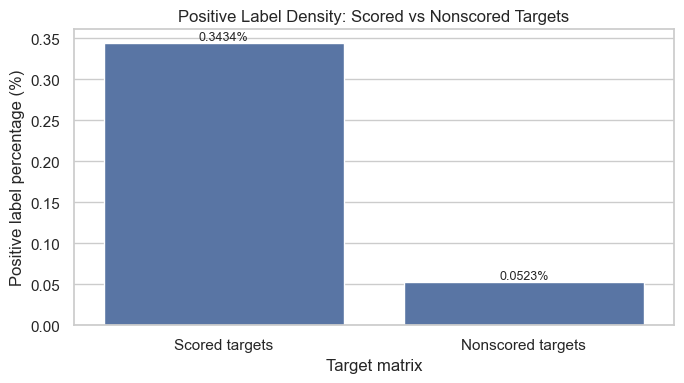

In [52]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=scored_nonscored_comparison,
    x="target_matrix",
    y="positive_label_percentage"
)

plt.title("Positive Label Density: Scored vs Nonscored Targets")
plt.xlabel("Target matrix")
plt.ylabel("Positive label percentage (%)")

for index, row in scored_nonscored_comparison.iterrows():
    plt.text(
        index,
        row["positive_label_percentage"],
        f'{row["positive_label_percentage"]:.4f}%',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "section_4_3_scored_vs_nonscored_positive_density.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### 4.3.3 Target-Level Positive Count Comparison

Next, we compare positive counts at the target-column level.

This helps us see whether nonscored targets are generally rarer than scored targets across individual labels.

In [53]:
scored_target_positive_counts = pd.DataFrame({
    "target_matrix": "Scored targets",
    "target": scored_target_features,
    "positive_count": y_scored_matrix.sum(axis=0).values
})

nonscored_target_positive_counts = pd.DataFrame({
    "target_matrix": "Nonscored targets",
    "target": nonscored_target_features,
    "positive_count": y_nonscored_matrix.sum(axis=0).values
})

combined_target_positive_counts = pd.concat(
    [
        scored_target_positive_counts,
        nonscored_target_positive_counts
    ],
    axis=0,
    ignore_index=True
)

target_positive_count_comparison_summary = (
    combined_target_positive_counts
    .groupby("target_matrix")["positive_count"]
    .describe()
    .reset_index()
)

target_positive_count_comparison_summary

,target_matrix,count,mean,std,min,25%,50%,75%,max
0,Nonscored targets,402.0,12.457711,13.359389,0.0,6.0,7.0,18.0,91.0
1,Scored targets,206.0,81.766990,115.160351,1.0,19.0,38.5,83.0,832.0


#### 4.3.4 Positive Count Distribution Comparison

This plot compares the distribution of positive counts across scored and nonscored target labels.

Because target counts are highly skewed, we use a boxplot with a log-scaled y-axis. This makes rare and frequent labels easier to compare in one plot.

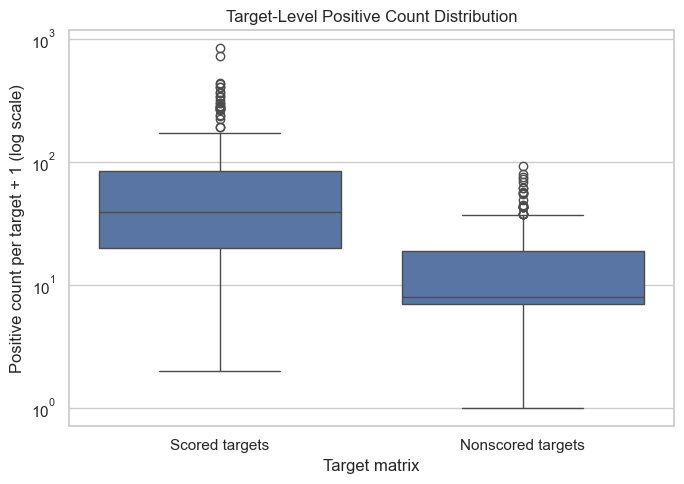

In [54]:
plot_df = combined_target_positive_counts.copy()

# Add 1 to avoid issues with log scale if any target has zero positives
plot_df["positive_count_plus_one"] = plot_df["positive_count"] + 1

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_df,
    x="target_matrix",
    y="positive_count_plus_one"
)

plt.yscale("log")
plt.title("Target-Level Positive Count Distribution")
plt.xlabel("Target matrix")
plt.ylabel("Positive count per target + 1 (log scale)")

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "section_4_3_target_positive_count_distribution_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### 4.3.5 Scored vs Nonscored Comparison Insight

The scored and nonscored target matrices are both sparse, but the nonscored matrix is much more sparse.

The scored target matrix has a positive label density of **0.3434%**, while the nonscored target matrix has a positive label density of only **0.0523%**. This means nonscored targets contain positive labels at only about **15% of the scored target density**.

The target-level positive count distribution also shows that nonscored targets generally have lower positive counts than scored targets. In the log-scale boxplot, the nonscored target distribution is shifted downward, meaning many nonscored labels have very few positive examples.

This gives an important modeling insight:

Nonscored targets may provide additional biological supervision, but they are not easy auxiliary labels. Their extreme sparsity means auxiliary learning may help only if the model can handle strong imbalance properly.

Key decisions:

- nonscored labels should not be used in the baseline model,
- nonscored labels should never be used as input features,
- nonscored labels may be tested later as auxiliary output targets,
- auxiliary learning should be evaluated carefully because nonscored labels are much sparser than scored labels,
- the next step should check sample-level coverage to see whether nonscored labels add extra supervision for samples.

In [55]:
scored_nonscored_density_ratio = {
    "scored_positive_percentage": round(positive_label_percentage, 4),
    "nonscored_positive_percentage": round(nonscored_positive_percentage, 4),
    "nonscored_density_as_fraction_of_scored_density": round(
        nonscored_positive_percentage / positive_label_percentage,
        4
    ),
    "scored_density_is_how_many_times_higher": round(
        positive_label_percentage / nonscored_positive_percentage,
        2
    ),
    "scored_positive_labels": total_positive_labels,
    "nonscored_positive_labels": nonscored_positive_labels,
}

scored_nonscored_density_ratio

{'scored_positive_percentage': 0.3434,
 'nonscored_positive_percentage': 0.0523,
 'nonscored_density_as_fraction_of_scored_density': 0.1524,
 'scored_density_is_how_many_times_higher': 6.56,
 'scored_positive_labels': 16844,
 'nonscored_positive_labels': 5008}

### 4.4 Sample-Level Auxiliary Label Coverage

In Section 4.3, we compared scored and nonscored targets at the matrix level.

Now we analyze them at the sample level.

The main question is:

Do nonscored labels provide extra supervision for samples beyond the scored targets?

To answer this, we compare:

- `scored_active_count`: number of active scored targets per sample,
- `nonscored_active_count`: number of active nonscored targets per sample.

Then we group samples into four categories:

- scored only,
- nonscored only,
- both scored and nonscored,
- neither scored nor nonscored.

This helps us decide whether nonscored targets may be useful for advanced auxiliary learning.

#### 4.4.1 Create Scored and Nonscored Active Count Table

First, we calculate how many scored and nonscored labels are active for each sample.

These counts are target-derived EDA variables.  
They must not be used as input features during model training.

In [56]:
auxiliary_label_activity = pd.DataFrame({
    ID_COL: y_scored[ID_COL],
    "scored_active_count": y_scored_matrix.sum(axis=1).values,
    "nonscored_active_count": y_nonscored_matrix.sum(axis=1).values
})

auxiliary_label_activity["has_scored_positive"] = (
    auxiliary_label_activity["scored_active_count"] > 0
)

auxiliary_label_activity["has_nonscored_positive"] = (
    auxiliary_label_activity["nonscored_active_count"] > 0
)

auxiliary_label_activity.head()

,sig_id,scored_active_count,nonscored_active_count,has_scored_positive,has_nonscored_positive
0,id_000644bb2,1,0,True,False
1,id_000779bfc,0,0,False,False
2,id_000a6266a,3,0,True,False
3,id_0015fd391,0,0,False,False
4,id_001626bd3,1,0,True,False


#### 4.4.2 Sample-Level Label Coverage Groups

Now we divide samples into four coverage groups.

This tells us whether nonscored labels add extra information beyond scored labels.

The most important group is `nonscored only`:  
these samples have no scored positive label, but they do have nonscored positive labels.

In [57]:
def assign_auxiliary_coverage_group(row):
    has_scored = row["has_scored_positive"]
    has_nonscored = row["has_nonscored_positive"]
    
    if has_scored and has_nonscored:
        return "Both scored and nonscored"
    elif has_scored and not has_nonscored:
        return "Scored only"
    elif not has_scored and has_nonscored:
        return "Nonscored only"
    else:
        return "Neither scored nor nonscored"


auxiliary_label_activity["coverage_group"] = auxiliary_label_activity.apply(
    assign_auxiliary_coverage_group,
    axis=1
)

coverage_group_order = [
    "Both scored and nonscored",
    "Scored only",
    "Nonscored only",
    "Neither scored nor nonscored"
]

auxiliary_coverage_summary = (
    auxiliary_label_activity["coverage_group"]
    .value_counts()
    .reindex(coverage_group_order)
    .fillna(0)
    .astype(int)
    .reset_index()
)

auxiliary_coverage_summary.columns = [
    "coverage_group",
    "sample_count"
]

auxiliary_coverage_summary["sample_percentage"] = (
    auxiliary_coverage_summary["sample_count"] / n_samples * 100
)

auxiliary_coverage_summary

,coverage_group,sample_count,sample_percentage
0,Both scored and nonscored,753,3.162006
1,Scored only,13694,57.503989
2,Nonscored only,3837,16.112371
3,Neither scored nor nonscored,5530,23.221634


#### 4.4.3 Visualize Auxiliary Label Coverage

This plot shows how samples are distributed across scored and nonscored label coverage groups.

It helps us quickly understand whether nonscored labels provide extra sample-level supervision.

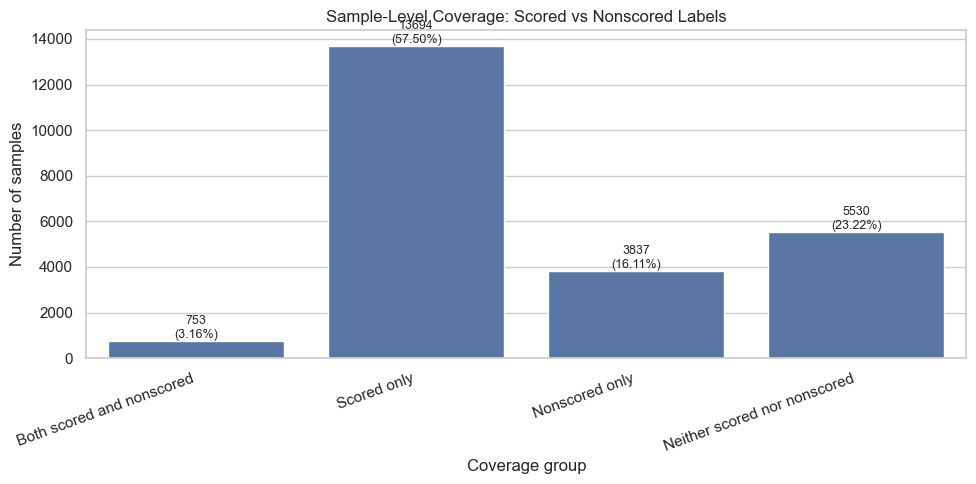

In [58]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=auxiliary_coverage_summary,
    x="coverage_group",
    y="sample_count"
)

plt.title("Sample-Level Coverage: Scored vs Nonscored Labels")
plt.xlabel("Coverage group")
plt.ylabel("Number of samples")
plt.xticks(rotation=20, ha="right")

for index, row in auxiliary_coverage_summary.iterrows():
    plt.text(
        index,
        row["sample_count"],
        f'{int(row["sample_count"])}\n({row["sample_percentage"]:.2f}%)',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "section_4_4_auxiliary_label_coverage_groups.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### 4.4.4 Compact Auxiliary Coverage Statistics

Now we summarize the sample-level scored and nonscored activity in one compact dictionary.

This helps us decide whether nonscored targets may be useful for advanced auxiliary learning.

In [59]:
auxiliary_coverage_statistics = {
    "total_samples": int(n_samples),
    "samples_with_scored_positive": int(auxiliary_label_activity["has_scored_positive"].sum()),
    "samples_with_nonscored_positive": int(auxiliary_label_activity["has_nonscored_positive"].sum()),
    "samples_with_both_scored_and_nonscored": int(
        (
            auxiliary_label_activity["has_scored_positive"] &
            auxiliary_label_activity["has_nonscored_positive"]
        ).sum()
    ),
    "samples_with_nonscored_only": int(
        (
            ~auxiliary_label_activity["has_scored_positive"] &
            auxiliary_label_activity["has_nonscored_positive"]
        ).sum()
    ),
    "samples_with_neither": int(
        (
            ~auxiliary_label_activity["has_scored_positive"] &
            ~auxiliary_label_activity["has_nonscored_positive"]
        ).sum()
    ),
    "mean_scored_active_count": round(auxiliary_label_activity["scored_active_count"].mean(), 4),
    "mean_nonscored_active_count": round(auxiliary_label_activity["nonscored_active_count"].mean(), 4),
    "max_scored_active_count": int(auxiliary_label_activity["scored_active_count"].max()),
    "max_nonscored_active_count": int(auxiliary_label_activity["nonscored_active_count"].max()),
}

auxiliary_coverage_statistics

{'total_samples': 23814,
 'samples_with_scored_positive': 14447,
 'samples_with_nonscored_positive': 4590,
 'samples_with_both_scored_and_nonscored': 753,
 'samples_with_nonscored_only': 3837,
 'samples_with_neither': 5530,
 'mean_scored_active_count': np.float64(0.7073),
 'mean_nonscored_active_count': np.float64(0.2103),
 'max_scored_active_count': 7,
 'max_nonscored_active_count': 7}

#### 4.4.5 Auxiliary Coverage Thinking Note

The sample-level coverage analysis shows that nonscored targets can provide additional supervision beyond the scored targets.

The largest group is `Scored only`, with **13,694 samples** or **57.50%** of the dataset. These samples have official scored target labels but no nonscored positive labels.

The most important auxiliary-learning group is `Nonscored only`, with **3,837 samples** or **16.11%** of the dataset. These samples have no active scored target but do have active nonscored targets. This means nonscored labels may provide extra biological supervision for samples that would otherwise look like zero-label samples from the scored-target perspective.

Only **753 samples** or **3.16%** have both scored and nonscored positive labels. This suggests that direct overlap between scored and nonscored activity is limited, but still present.

There are also **5,530 samples** or **23.22%** with neither scored nor nonscored positive labels, confirming that label sparsity remains strong even after adding nonscored targets.

Key decisions:

- nonscored targets should still not be used in the baseline model,
- nonscored targets should never be used as input features,
- nonscored targets may be useful in advanced multi-task learning because they add supervision for 16.11% nonscored-only samples,
- auxiliary learning should be tested carefully because nonscored labels are very sparse and overlap with scored labels is limited,
- the next step should check whether scored and nonscored active counts are related.

In [60]:
auxiliary_coverage_insight_table = pd.DataFrame({
    "finding": [
        "Most samples are scored-only",
        "A meaningful group is nonscored-only",
        "Only a small group has both scored and nonscored positives",
        "Many samples still have no positive labels in either matrix",
        "Nonscored labels may provide extra supervision"
    ],
    "evidence_from_eda": [
        "13,694 samples, or 57.50%, are scored-only",
        "3,837 samples, or 16.11%, are nonscored-only",
        "753 samples, or 3.16%, have both scored and nonscored positives",
        "5,530 samples, or 23.22%, have neither scored nor nonscored positives",
        "Nonscored-only samples would have no positive scored labels but still contain auxiliary labels"
    ],
    "decision": [
        "Baseline should continue using scored targets only",
        "Nonscored targets may be useful for advanced auxiliary learning",
        "Do not expect strong scored-nonscored overlap for every sample",
        "Sparse-label handling remains important",
        "Test nonscored targets later as auxiliary outputs, not input features"
    ]
})

auxiliary_coverage_insight_table

,finding,evidence_from_eda,decision
0,Most samples are scored-only,"13,694 samples, or 57.50%, are scored-only",Baseline should continue using scored targets ...
1,A meaningful group is nonscored-only,"3,837 samples, or 16.11%, are nonscored-only",Nonscored targets may be useful for advanced a...
2,Only a small group has both scored and nonscor...,"753 samples, or 3.16%, have both scored and no...",Do not expect strong scored-nonscored overlap ...
3,Many samples still have no positive labels in ...,"5,530 samples, or 23.22%, have neither scored ...",Sparse-label handling remains important
4,Nonscored labels may provide extra supervision,Nonscored-only samples would have no positive ...,Test nonscored targets later as auxiliary outp...


### 4.5 Scored vs Nonscored Active Count Relationship

In Section 4.4, we checked whether samples have scored labels, nonscored labels, both, or neither.

Now we check whether the number of active scored labels and active nonscored labels are related at the sample level.

This helps us understand whether nonscored targets may support shared representation learning in an advanced auxiliary model.

Important note:

`scored_active_count` and `nonscored_active_count` are target-derived EDA variables.  
They must not be used as input features.

#### 4.5.1 Active Count Relationship Summary

First, we calculate simple summary statistics for scored and nonscored active label counts.

We also calculate the correlation between scored and nonscored active counts.

In [61]:
scored_nonscored_active_count_summary = pd.DataFrame({
    "label_matrix": [
        "Scored targets",
        "Nonscored targets"
    ],
    "mean_active_count": [
        auxiliary_label_activity["scored_active_count"].mean(),
        auxiliary_label_activity["nonscored_active_count"].mean()
    ],
    "median_active_count": [
        auxiliary_label_activity["scored_active_count"].median(),
        auxiliary_label_activity["nonscored_active_count"].median()
    ],
    "max_active_count": [
        auxiliary_label_activity["scored_active_count"].max(),
        auxiliary_label_activity["nonscored_active_count"].max()
    ],
    "samples_with_positive_labels": [
        auxiliary_label_activity["has_scored_positive"].sum(),
        auxiliary_label_activity["has_nonscored_positive"].sum()
    ]
})

scored_nonscored_active_count_summary

,label_matrix,mean_active_count,median_active_count,max_active_count,samples_with_positive_labels
0,Scored targets,0.707315,1.0,7,14447
1,Nonscored targets,0.210296,0.0,7,4590


In [62]:
active_count_correlation = {
    "pearson_correlation": round(
        auxiliary_label_activity["scored_active_count"].corr(
            auxiliary_label_activity["nonscored_active_count"],
            method="pearson"
        ),
        4
    ),
    "spearman_correlation": round(
        auxiliary_label_activity["scored_active_count"].corr(
            auxiliary_label_activity["nonscored_active_count"],
            method="spearman"
        ),
        4
    )
}

active_count_correlation

{'pearson_correlation': np.float64(-0.2515),
 'spearman_correlation': np.float64(-0.4048)}

#### 4.5.2 Mean Nonscored Activity by Scored Active Count

Now we group samples by the number of active scored targets and calculate the average number of active nonscored targets.

This helps us see whether samples with more scored labels also tend to have more nonscored labels.

In [63]:
nonscored_by_scored_count = (
    auxiliary_label_activity
    .groupby("scored_active_count")
    .agg(
        sample_count=(ID_COL, "count"),
        mean_nonscored_active_count=("nonscored_active_count", "mean"),
        median_nonscored_active_count=("nonscored_active_count", "median"),
        max_nonscored_active_count=("nonscored_active_count", "max")
    )
    .reset_index()
)

nonscored_by_scored_count

,scored_active_count,sample_count,mean_nonscored_active_count,median_nonscored_active_count,max_nonscored_active_count
0,0,9367,0.427245,0.0,4
1,1,12532,0.055618,0.0,4
2,2,1538,0.106632,0.0,5
3,3,303,0.099010,0.0,2
4,4,55,1.527273,0.0,7
5,5,13,1.000000,1.0,1
6,7,6,3.000000,3.0,3


#### 4.5.3 Visualize Active Count Relationship

This plot shows the relationship between scored active count and mean nonscored active count.

It is cleaner than a raw scatter plot because the counts are small integers and many samples overlap at the same points.

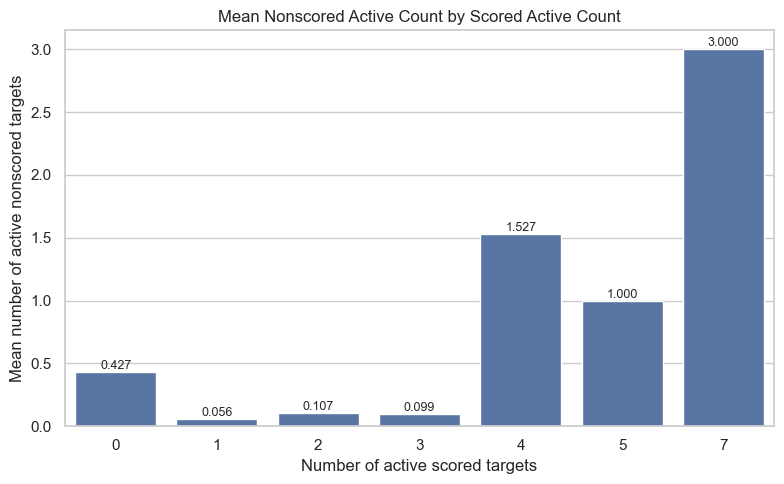

In [64]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=nonscored_by_scored_count,
    x="scored_active_count",
    y="mean_nonscored_active_count"
)

plt.title("Mean Nonscored Active Count by Scored Active Count")
plt.xlabel("Number of active scored targets")
plt.ylabel("Mean number of active nonscored targets")

for index, row in nonscored_by_scored_count.iterrows():
    plt.text(
        index,
        row["mean_nonscored_active_count"],
        f'{row["mean_nonscored_active_count"]:.3f}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "section_4_5_mean_nonscored_by_scored_count.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### 4.5.4 Scored-Nonscored Relationship Thinking Note

This analysis checks whether scored and nonscored target activity are related at the sample level.

The current plot shows the average number of active nonscored targets for each scored active target count group. Samples with zero active scored targets still have a nonzero average nonscored target count. This suggests that nonscored labels may provide additional auxiliary supervision for samples that appear as zero-label samples in the scored target matrix.

However, the relationship is not smooth. Samples with many active scored targets show higher nonscored averages, but those groups are likely very small, so we should not over-interpret them.

A useful next idea for advanced modeling is to also check the reverse direction: whether samples with more nonscored active targets tend to have more scored active targets. If such a relationship exists, nonscored targets may help a multi-task model learn shared biological response patterns.

For baseline modeling, nonscored labels should still not be used. For advanced modeling, nonscored labels can be tested as auxiliary output targets, not as input features.

### 4.6 Auxiliary-Learning Readiness Decision

In this final subsection, we summarize what we learned from nonscored target analysis and decide how nonscored targets should be used in later modeling.

This section does not add new analysis.  
It converts Section 4 findings into clear modeling rules.

The main decision is:

- baseline model should use only scored targets,
- nonscored targets should never be used as input features,
- nonscored targets may be tested later as auxiliary output targets in an advanced multi-task model,
- final validation and submission should remain focused on the 206 scored targets.

In [65]:
section_4_key_findings = pd.DataFrame({
    "analysis_area": [
        "Nonscored target role",
        "Nonscored matrix size",
        "Nonscored sparsity",
        "Control-sample behavior",
        "Scored vs nonscored density",
        "Sample-level coverage",
        "Auxiliary-learning potential"
    ],
    "main_finding": [
        "Nonscored targets are auxiliary labels, not official scoring labels",
        "There are 402 nonscored target labels",
        "The nonscored target matrix is extremely sparse",
        "Control samples have zero nonscored target activity",
        "Nonscored targets are much sparser than scored targets",
        "A meaningful nonscored-only sample group exists",
        "Nonscored targets may provide extra supervision in advanced modeling"
    ],
    "evidence_from_eda": [
        "Final Kaggle submission uses only scored target columns",
        "402 nonscored targets vs 206 scored targets",
        "Positive nonscored density = 0.0523%",
        "control_positive_nonscored_label_count = 0",
        "Scored density = 0.3434%, nonscored density = 0.0523%",
        "3,837 samples, or 16.11%, are nonscored-only",
        "Nonscored-only samples have auxiliary labels even when scored labels are absent"
    ],
    "decision": [
        "Do not use nonscored targets in baseline",
        "Keep nonscored labels separate",
        "Use carefully if tested later",
        "Control-zero rule is consistent",
        "Do not expect auxiliary learning to be automatically easy",
        "Advanced auxiliary learning is worth testing",
        "Use nonscored labels only as auxiliary outputs"
    ]
})

section_4_key_findings

,analysis_area,main_finding,evidence_from_eda,decision
0,Nonscored target role,"Nonscored targets are auxiliary labels, not of...",Final Kaggle submission uses only scored targe...,Do not use nonscored targets in baseline
1,Nonscored matrix size,There are 402 nonscored target labels,402 nonscored targets vs 206 scored targets,Keep nonscored labels separate
2,Nonscored sparsity,The nonscored target matrix is extremely sparse,Positive nonscored density = 0.0523%,Use carefully if tested later
3,Control-sample behavior,Control samples have zero nonscored target act...,control_positive_nonscored_label_count = 0,Control-zero rule is consistent
4,Scored vs nonscored density,Nonscored targets are much sparser than scored...,"Scored density = 0.3434%, nonscored density = ...",Do not expect auxiliary learning to be automat...
5,Sample-level coverage,A meaningful nonscored-only sample group exists,"3,837 samples, or 16.11%, are nonscored-only",Advanced auxiliary learning is worth testing
6,Auxiliary-learning potential,Nonscored targets may provide extra supervisio...,Nonscored-only samples have auxiliary labels e...,Use nonscored labels only as auxiliary outputs


#### 4.6.2 Final Auxiliary-Learning Decision Table

This table defines exactly how nonscored targets should and should not be used in the project.

In [66]:
auxiliary_learning_decision_table = pd.DataFrame({
    "question": [
        "Use nonscored targets in baseline model?",
        "Use nonscored targets as input features?",
        "Use nonscored targets in final submission?",
        "Use nonscored targets during validation scoring?",
        "Use nonscored targets in advanced model training?",
        "How should advanced model use nonscored targets?",
        "What is the main risk?",
        "What should be checked later?"
    ],
    "decision": [
        "No",
        "Never",
        "No",
        "No",
        "Yes, as an experiment",
        "As auxiliary output labels",
        "Data leakage and auxiliary-label imbalance",
        "Whether auxiliary learning improves scored-target validation loss"
    ],
    "reason": [
        "Baseline should stay clean and match the official scored task",
        "Nonscored targets are labels, not measured input features",
        "Submission file contains only 206 scored target columns",
        "Main validation metric should evaluate scored targets only",
        "Nonscored labels may provide extra biological supervision",
        "The model can learn scored and nonscored outputs jointly during training",
        "Using labels as features leaks target information; nonscored labels are also very sparse",
        "Auxiliary labels are useful only if scored-target performance improves"
    ]
})

auxiliary_learning_decision_table

,question,decision,reason
0,Use nonscored targets in baseline model?,No,Baseline should stay clean and match the offic...
1,Use nonscored targets as input features?,Never,"Nonscored targets are labels, not measured inp..."
2,Use nonscored targets in final submission?,No,Submission file contains only 206 scored targe...
3,Use nonscored targets during validation scoring?,No,Main validation metric should evaluate scored ...
4,Use nonscored targets in advanced model training?,"Yes, as an experiment",Nonscored labels may provide extra biological ...
5,How should advanced model use nonscored targets?,As auxiliary output labels,The model can learn scored and nonscored outpu...
6,What is the main risk?,Data leakage and auxiliary-label imbalance,Using labels as features leaks target informat...
7,What should be checked later?,Whether auxiliary learning improves scored-tar...,Auxiliary labels are useful only if scored-tar...


#### 4.6.3 Baseline vs Advanced Modeling Protocol

The nonscored target analysis leads to two separate modeling protocols.

The baseline model should stay simple and official-task focused.

The advanced model can later test whether nonscored labels improve representation learning.

In [67]:
baseline_vs_advanced_protocol = pd.DataFrame({
    "stage": [
        "Baseline model",
        "Advanced auxiliary model",
        "Validation metric",
        "Final submission"
    ],
    "input": [
        "train_features",
        "train_features",
        "validation predictions",
        "test_features"
    ],
    "training_output": [
        "206 scored targets only",
        "206 scored targets + 402 nonscored targets",
        "evaluate scored target predictions only",
        "predict scored targets only"
    ],
    "nonscored_role": [
        "Ignored",
        "Auxiliary output supervision",
        "Not part of official evaluation",
        "Not submitted"
    ],
    "main_goal": [
        "Create a clean baseline",
        "Test whether auxiliary labels improve scored-target learning",
        "Compare models fairly",
        "Match official submission format"
    ]
})

baseline_vs_advanced_protocol

,stage,input,training_output,nonscored_role,main_goal
0,Baseline model,train_features,206 scored targets only,Ignored,Create a clean baseline
1,Advanced auxiliary model,train_features,206 scored targets + 402 nonscored targets,Auxiliary output supervision,Test whether auxiliary labels improve scored-t...
2,Validation metric,validation predictions,evaluate scored target predictions only,Not part of official evaluation,Compare models fairly
3,Final submission,test_features,predict scored targets only,Not submitted,Match official submission format


#### 4.6.4 Leakage Prevention Rules

Nonscored targets are target labels.

They must never be merged into the input feature matrix.

Using nonscored labels as input features would leak information that is not available at prediction time.

In [68]:
nonscored_leakage_guardrails = pd.DataFrame({
    "rule": [
        "Do not add nonscored labels to X_train",
        "Do not create features from nonscored labels",
        "Do not use nonscored labels for baseline training",
        "Do not evaluate final model using nonscored targets",
        "Use nonscored labels only as auxiliary outputs in advanced experiments"
    ],
    "reason": [
        "They are labels, not input measurements",
        "Target-derived features would cause leakage",
        "Baseline should reflect the official scored task",
        "Kaggle scoring uses scored targets only",
        "This is the safe way to test auxiliary learning"
    ]
})

nonscored_leakage_guardrails

,rule,reason
0,Do not add nonscored labels to X_train,"They are labels, not input measurements"
1,Do not create features from nonscored labels,Target-derived features would cause leakage
2,Do not use nonscored labels for baseline training,Baseline should reflect the official scored task
3,Do not evaluate final model using nonscored ta...,Kaggle scoring uses scored targets only
4,Use nonscored labels only as auxiliary outputs...,This is the safe way to test auxiliary learning


#### 4.6.5 Save Section 4 Helper Tables

We save the key Section 4 tables so they can be reused later in advanced modeling and final project reporting.

In [69]:
section_4_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
section_4_output_dir.mkdir(parents=True, exist_ok=True)

section_4_key_findings.to_csv(
    section_4_output_dir / "section_4_key_findings.csv",
    index=False
)

auxiliary_learning_decision_table.to_csv(
    section_4_output_dir / "section_4_auxiliary_learning_decisions.csv",
    index=False
)

baseline_vs_advanced_protocol.to_csv(
    section_4_output_dir / "section_4_baseline_vs_advanced_protocol.csv",
    index=False
)

nonscored_leakage_guardrails.to_csv(
    section_4_output_dir / "section_4_nonscored_leakage_guardrails.csv",
    index=False
)

auxiliary_coverage_summary.to_csv(
    section_4_output_dir / "section_4_auxiliary_coverage_summary.csv",
    index=False
)

print("Section 4 helper tables saved successfully.")

Section 4 helper tables saved successfully.


#### 4.6.6 Section 4 Completion Status

Section 4 is complete.

We analyzed nonscored targets only to decide whether they may be useful for advanced auxiliary learning.

The final decision is:

- ignore nonscored targets in the baseline model,
- never use nonscored targets as input features,
- optionally test nonscored targets later as auxiliary output labels,
- always evaluate and submit only scored targets.

In [70]:
section_4_status = {
    "section": "4. Nonscored Target Analysis and Auxiliary-Learning Readiness",
    "status": "completed",
    "critical_issue_found": False,
    "baseline_uses_nonscored_targets": False,
    "nonscored_used_as_input_features": False,
    "advanced_auxiliary_learning_candidate": True,
    "final_evaluation_targets": "206 scored targets only",
    "ready_for_next_section": True,
    "next_section": "5. Biological Feature Block Analysis"
}

section_4_status

{'section': '4. Nonscored Target Analysis and Auxiliary-Learning Readiness',
 'status': 'completed',
 'critical_issue_found': False,
 'baseline_uses_nonscored_targets': False,
 'nonscored_used_as_input_features': False,
 'advanced_auxiliary_learning_candidate': True,
 'final_evaluation_targets': '206 scored targets only',
 'ready_for_next_section': True,
 'next_section': '5. Biological Feature Block Analysis'}

## 5. Biological Feature Block Analysis

Until now, the EDA focused on experimental metadata and target-label structure.

Now we analyze the input biological feature blocks:

- gene-expression features: `g-*`
- cell-viability features: `c-*`

The goal is not to inspect every feature one by one.  
Instead, we analyze each biological block using summary statistics, sample-level response measures, metadata-conditioned behavior, and high-variance feature ranking.

This section will help decide which feature-engineering ideas should be tested later.

### 5.1 Gene Expression Feature Analysis

The gene-expression block contains hundreds of `g-*` features.

Because this block is high-dimensional, plotting every gene feature separately would create a noisy and repetitive notebook.

Instead, we analyze the gene block at three levels:

1. feature level: how individual gene features vary,
2. sample level: how strong the gene response is for each sample,
3. metadata level: whether gene response changes by treatment type, time, or dose.

This will help us decide whether to create gene summary features and whether block-wise transformations such as scaling or PCA may be useful later.


#### 5.1.1 Gene Feature Block Overview

First, we confirm the size of the gene feature block and check that all expected gene columns are available in train and test data.

In [71]:
gene_block_overview = {
    "number_of_gene_features": len(gene_features),
    "train_gene_shape": train_features[gene_features].shape,
    "test_gene_shape": test_features[gene_features].shape,
    "first_5_gene_features": gene_features[:5],
    "last_5_gene_features": gene_features[-5:],
    "all_gene_features_in_train": all(col in train_features.columns for col in gene_features),
    "all_gene_features_in_test": all(col in test_features.columns for col in gene_features)
}

gene_block_overview

{'number_of_gene_features': 772,
 'train_gene_shape': (23814, 772),
 'test_gene_shape': (3982, 772),
 'first_5_gene_features': ['g-0', 'g-1', 'g-2', 'g-3', 'g-4'],
 'last_5_gene_features': ['g-767', 'g-768', 'g-769', 'g-770', 'g-771'],
 'all_gene_features_in_train': True,
 'all_gene_features_in_test': True}

#### 5.1.2 Gene Per-Feature Statistical Summary

Now we calculate feature-level statistics for all gene features.

This tells us whether gene features have different levels of variation, skewness, and extreme values.

These statistics are useful for later decisions about scaling, clipping, and PCA.

In [72]:
gene_train_matrix = train_features[gene_features].copy()
gene_test_matrix = test_features[gene_features].copy()

gene_feature_summary = pd.DataFrame({
    "feature": gene_features,
    "mean": gene_train_matrix.mean(axis=0).values,
    "std": gene_train_matrix.std(axis=0).values,
    "min": gene_train_matrix.min(axis=0).values,
    "max": gene_train_matrix.max(axis=0).values,
    "skew": gene_train_matrix.skew(axis=0).values,
    "abs_mean": gene_train_matrix.abs().mean(axis=0).values
})

gene_feature_summary = gene_feature_summary.sort_values(
    "std",
    ascending=False
).reset_index(drop=True)

gene_feature_summary.head(10)

,feature,mean,std,min,max,skew,abs_mean
0,g-50,-0.588018,2.256983,-10.000,4.889,-2.758812,1.166368
1,g-75,-0.445392,2.254701,-10.000,8.835,-2.561960,1.177063
2,g-37,-0.606710,2.200277,-10.000,5.602,-2.774559,1.146069
3,g-228,-0.475231,2.163439,-10.000,10.000,-3.119697,1.069719
4,g-100,0.553186,2.152067,-5.915,10.000,2.503223,1.174478
5,g-131,0.369558,2.084729,-9.931,10.000,2.694549,1.129372
6,g-744,0.548903,2.023791,-2.912,10.000,2.933391,1.077323
7,g-67,-0.494869,2.020121,-10.000,4.695,-3.110427,1.057799
8,g-38,0.534425,2.003317,-10.000,10.000,2.824274,1.088413
9,g-392,0.537320,1.989753,-4.156,10.000,2.792067,1.075537


#### 5.1.3 Gene Feature Distribution Overview

Instead of plotting 772 gene histograms, we summarize the distribution of gene-feature statistics.

This keeps the notebook readable while still showing whether the gene block contains high-variance or skewed features.

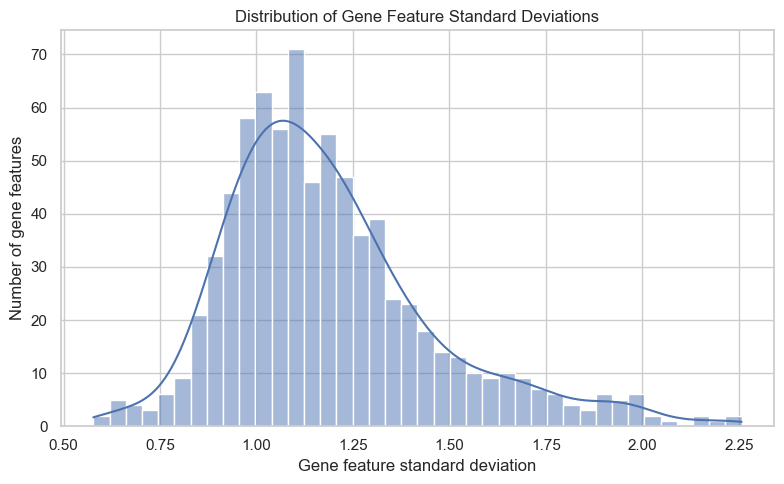

In [73]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=gene_feature_summary,
    x="std",
    bins=40,
    kde=True
)

plt.title("Distribution of Gene Feature Standard Deviations")
plt.xlabel("Gene feature standard deviation")
plt.ylabel("Number of gene features")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_1_gene_feature_std_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

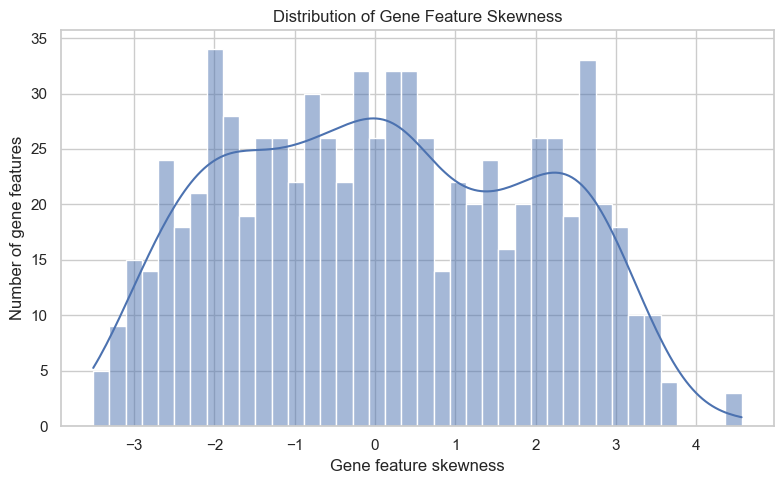

In [74]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=gene_feature_summary,
    x="skew",
    bins=40,
    kde=True
)

plt.title("Distribution of Gene Feature Skewness")
plt.xlabel("Gene feature skewness")
plt.ylabel("Number of gene features")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_1_gene_feature_skew_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5.1.4 Sample-Level Gene Response Summary

Feature-level statistics describe columns.

Now we summarize gene response at the sample level.

For each sample, we calculate:

- average gene value,
- gene standard deviation,
- average absolute gene response,
- minimum gene value,
- maximum gene value.

These sample-level summaries may become useful engineered features later.

In [75]:
gene_sample_summary = pd.DataFrame({
    ID_COL: train_features[ID_COL],
    "gene_mean": gene_train_matrix.mean(axis=1).values,
    "gene_std": gene_train_matrix.std(axis=1).values,
    "gene_abs_mean": gene_train_matrix.abs().mean(axis=1).values,
    "gene_min": gene_train_matrix.min(axis=1).values,
    "gene_max": gene_train_matrix.max(axis=1).values
})

gene_sample_summary.head()

,sig_id,gene_mean,gene_std,gene_abs_mean,gene_min,gene_max
0,id_000644bb2,-0.008019,0.774246,0.560740,-5.691,3.394
1,id_000779bfc,0.005305,0.770147,0.543174,-5.237,5.566
2,id_000a6266a,-0.015395,1.000255,0.685493,-5.164,5.447
3,id_0015fd391,-0.000230,1.190755,0.890835,-4.247,5.391
4,id_001626bd3,-0.024673,1.000048,0.745974,-10.000,4.155


In [76]:
gene_sample_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
gene_mean,23814.0,0.009010,0.048666,-0.382465,-0.015314,0.007847,0.031221,0.902045
gene_std,23814.0,1.032783,0.678895,0.455580,0.721666,0.810838,0.973562,7.988689
gene_abs_mean,23814.0,0.760691,0.532184,0.350365,0.519339,0.586098,0.717260,7.260411
gene_min,23814.0,-5.211566,1.836456,-10.000000,-5.593000,-5.004000,-4.168000,-1.550000
gene_max,23814.0,5.144620,1.855277,1.617000,3.937000,4.946000,5.579000,10.000000


#### 5.1.5 Gene Response by Metadata

Now we check whether sample-level gene response changes under different experimental metadata groups.

The most important comparison is `cp_type`, because control samples and treated samples may show different biological response patterns.

In [77]:
gene_sample_with_metadata = (
    train_features[[ID_COL, "cp_type", "cp_time", "cp_dose"]]
    .merge(gene_sample_summary, on=ID_COL, how="left")
)

gene_response_by_metadata = (
    gene_sample_with_metadata
    .groupby(["cp_type", "cp_time", "cp_dose"])
    .agg(
        sample_count=(ID_COL, "count"),
        mean_gene_abs_mean=("gene_abs_mean", "mean"),
        median_gene_abs_mean=("gene_abs_mean", "median"),
        mean_gene_std=("gene_std", "mean"),
        median_gene_std=("gene_std", "median")
    )
    .reset_index()
)

gene_response_by_metadata


,cp_type,cp_time,cp_dose,sample_count,mean_gene_abs_mean,median_gene_abs_mean,mean_gene_std,median_gene_std
0,ctl_vehicle,24,D1,301,0.680535,0.655565,0.907846,0.876819
1,ctl_vehicle,24,D2,305,0.726416,0.698246,0.970944,0.941620
2,ctl_vehicle,48,D1,343,0.689518,0.653544,0.918042,0.866338
3,ctl_vehicle,48,D2,305,0.715837,0.677609,0.967514,0.901501
4,ctl_vehicle,72,D1,307,0.706446,0.667657,0.928078,0.884369
5,ctl_vehicle,72,D2,305,0.692192,0.667259,0.926640,0.892871
6,trt_cp,24,D1,3585,0.749421,0.582303,1.021067,0.803260
7,trt_cp,24,D2,3581,0.737514,0.584598,1.008841,0.814789
8,trt_cp,48,D1,4011,0.790400,0.585884,1.069675,0.809049
9,trt_cp,48,D2,3591,0.746212,0.573519,1.026904,0.806076


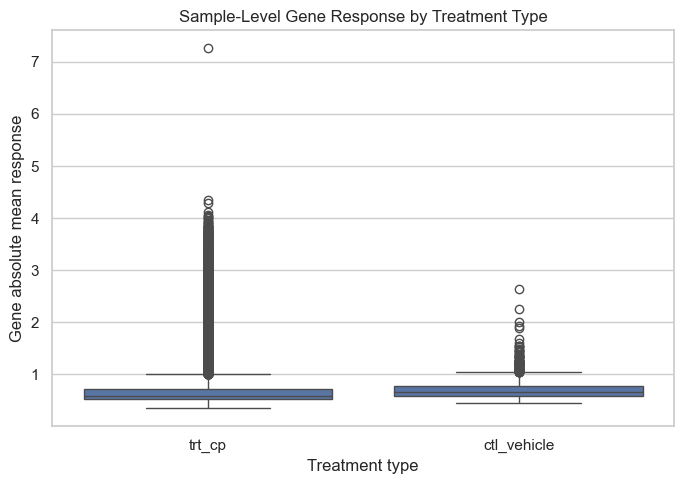

In [78]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=gene_sample_with_metadata,
    x="cp_type",
    y="gene_abs_mean"
)

plt.title("Sample-Level Gene Response by Treatment Type")
plt.xlabel("Treatment type")
plt.ylabel("Gene absolute mean response")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_1_gene_abs_mean_by_cp_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

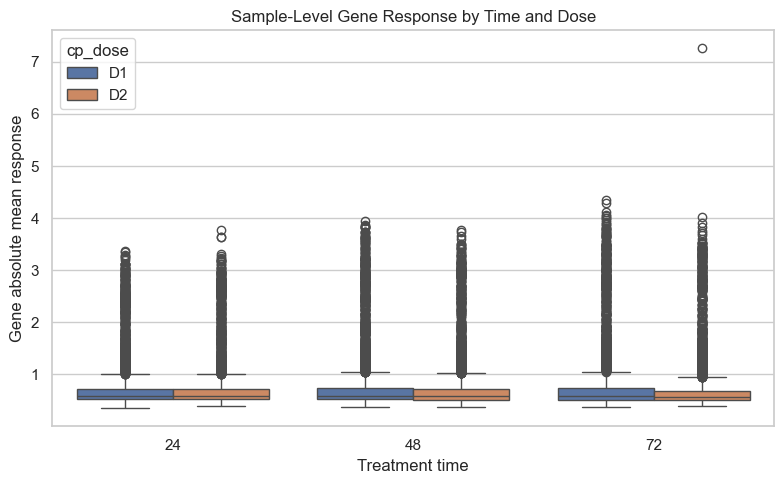

In [79]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=gene_sample_with_metadata,
    x="cp_time",
    y="gene_abs_mean",
    hue="cp_dose"
)

plt.title("Sample-Level Gene Response by Time and Dose")
plt.xlabel("Treatment time")
plt.ylabel("Gene absolute mean response")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_1_gene_abs_mean_by_time_dose.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5.1.6 High-Variance Gene Features

High-variance gene features may carry strong biological response signal.

We do not automatically select or drop features here.  
We only rank them for interpretation and future feature-engineering decisions.

In [80]:
top_high_variance_genes = gene_feature_summary.head(30).copy()

top_high_variance_genes

,feature,mean,std,min,max,skew,abs_mean
0,g-50,-0.588018,2.256983,-10.000,4.889,-2.758812,1.166368
1,g-75,-0.445392,2.254701,-10.000,8.835,-2.561960,1.177063
2,g-37,-0.606710,2.200277,-10.000,5.602,-2.774559,1.146069
3,g-228,-0.475231,2.163439,-10.000,10.000,-3.119697,1.069719
4,g-100,0.553186,2.152067,-5.915,10.000,2.503223,1.174478
5,g-131,0.369558,2.084729,-9.931,10.000,2.694549,1.129372
6,g-744,0.548903,2.023791,-2.912,10.000,2.933391,1.077323
7,g-67,-0.494869,2.020121,-10.000,4.695,-3.110427,1.057799
8,g-38,0.534425,2.003317,-10.000,10.000,2.824274,1.088413
9,g-392,0.537320,1.989753,-4.156,10.000,2.792067,1.075537


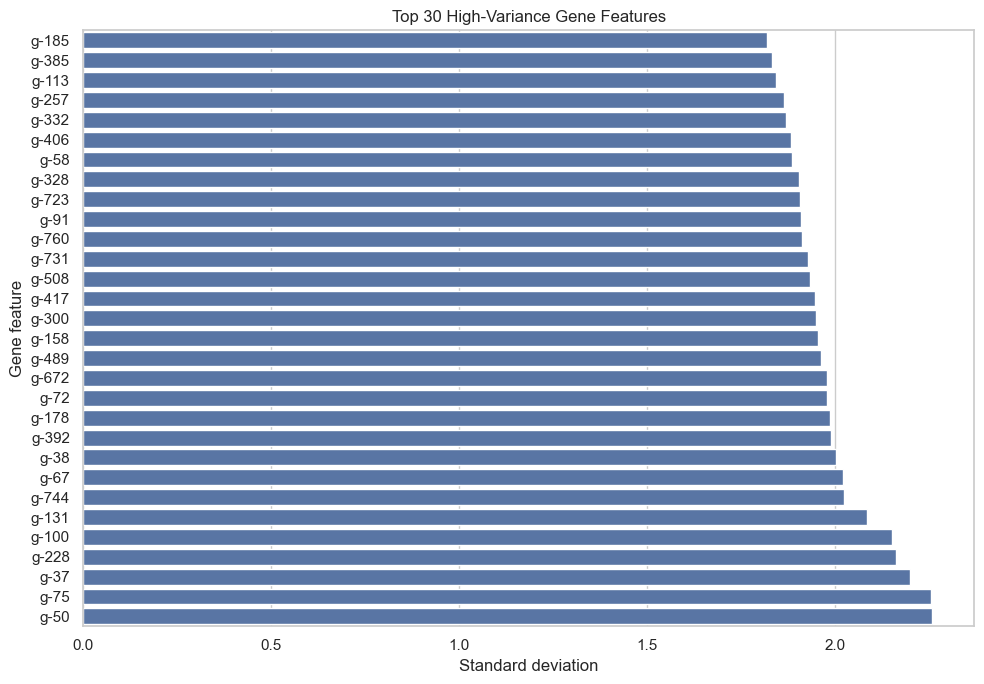

In [81]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_high_variance_genes.sort_values("std", ascending=True),
    x="std",
    y="feature"
)

plt.title("Top 30 High-Variance Gene Features")
plt.xlabel("Standard deviation")
plt.ylabel("Gene feature")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_1_top_high_variance_gene_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5.1.7 Gene Block Thinking Note

The gene-expression block shows meaningful variation across features and samples.

Most gene features have standard deviations concentrated around approximately 1.0 to 1.25, with the highest density near 1.07 to 1.10. This suggests that many gene features have broadly comparable variability. However, the standard deviation distribution is slightly right-skewed, meaning a smaller group of gene features has much higher variation. These high-variance genes may contain stronger biological response signal, but they should not be selected blindly without validation.

The skewness distribution ranges widely, roughly from strongly negative to strongly positive values. Many features are close to the central region, but some features show clear skewness. This indicates that not all gene features are normally distributed. Later preprocessing may need scaling or robust transformation, but these transformations must be fitted only inside the training pipeline to avoid leakage.

At the sample level, the gene absolute mean response is fairly stable for most samples, but there are clear outliers. Treated samples show more extreme gene-response outliers than control samples, suggesting that some compounds may produce stronger transcriptomic responses. However, outlier response does not automatically mean the sample has positive scored targets; this is a hypothesis that should be checked later against target activity.

The time-dose plot shows that the central gene-response pattern is broadly similar across `cp_time` and `cp_dose` groups, while outliers appear across multiple groups. This suggests that time and dose may not strongly shift the overall median gene response, but they may still influence specific gene features or extreme-response samples.

Feature-engineering decisions:

* sample-level gene summary features such as `gene_abs_mean`, `gene_std`, `gene_min`, and `gene_max` are worth testing later;
* high-variance gene features should be monitored, not manually selected without validation;
* scaling or robust preprocessing should be done inside the modeling pipeline;
* block-wise PCA may be useful later because the gene block is high-dimensional;
* a later check should compare gene-response summaries with target activity to see whether stronger gene responses are associated with positive scored labels.


#### 5.1.8 Gene Block Feature Engineering Decision

This subsection converts the gene-block EDA findings into feature-engineering decisions.

The purpose is not to create features in this notebook.  
The purpose is to decide which gene-based features should be tested later in the feature-engineering notebook.

In [82]:
gene_block_fe_decision_table = pd.DataFrame({
    "eda_finding": [
        "Gene features are high-dimensional",
        "Most gene features have comparable standard deviation",
        "Some gene features have much higher variance",
        "Gene feature skewness varies widely",
        "Sample-level gene response has clear outliers",
        "Treated samples show stronger extreme gene-response outliers",
        "Time-dose groups have broadly similar central gene response",
        "Gene response may be related to target activity, but not proven yet"
    ],
    "evidence": [
        f"{len(gene_features)} gene-expression features are available",
        "Most feature standard deviations are concentrated around roughly 1.0 to 1.25",
        "The standard deviation distribution is right-skewed",
        "Skewness ranges from strongly negative to strongly positive values",
        "gene_abs_mean contains a stable central pattern plus extreme-response samples",
        "trt_cp samples show more extreme gene_abs_mean outliers than ctl_vehicle samples",
        "Median gene_abs_mean looks broadly similar across cp_time and cp_dose groups",
        "Outlier gene response is only a hypothesis for biological signal at this stage"
    ],
    "feature_engineering_decision": [
        "Keep gene block as a separate biological feature group",
        "Test sample-level gene summary features",
        "Monitor high-variance genes, but do not manually select them yet",
        "Use leakage-safe scaling or robust preprocessing inside the model pipeline",
        "Create candidate features such as gene_abs_mean, gene_std, gene_min, and gene_max",
        "Keep cp_type and consider control-aware inference rule later",
        "Keep cp_time and cp_dose; interaction effects can be tested later",
        "Later compare gene summaries with target activity before making strong claims"
    ]
})

gene_block_fe_decision_table

,eda_finding,evidence,feature_engineering_decision
0,Gene features are high-dimensional,772 gene-expression features are available,Keep gene block as a separate biological featu...
1,Most gene features have comparable standard de...,Most feature standard deviations are concentra...,Test sample-level gene summary features
2,Some gene features have much higher variance,The standard deviation distribution is right-s...,"Monitor high-variance genes, but do not manual..."
3,Gene feature skewness varies widely,Skewness ranges from strongly negative to stro...,Use leakage-safe scaling or robust preprocessi...
4,Sample-level gene response has clear outliers,gene_abs_mean contains a stable central patter...,Create candidate features such as gene_abs_mea...
5,Treated samples show stronger extreme gene-res...,trt_cp samples show more extreme gene_abs_mean...,Keep cp_type and consider control-aware infere...
6,Time-dose groups have broadly similar central ...,Median gene_abs_mean looks broadly similar acr...,Keep cp_time and cp_dose; interaction effects ...
7,Gene response may be related to target activit...,Outlier gene response is only a hypothesis for...,Later compare gene summaries with target activ...


In [83]:
gene_block_candidate_features = pd.DataFrame({
    "candidate_feature": [
        "gene_mean",
        "gene_std",
        "gene_abs_mean",
        "gene_min",
        "gene_max",
        "gene_range",
        "gene_high_response_flag",
        "gene_pca_components"
    ],
    "feature_type": [
        "sample-level summary",
        "sample-level summary",
        "sample-level summary",
        "sample-level summary",
        "sample-level summary",
        "sample-level summary",
        "binary/threshold candidate",
        "dimensionality reduction candidate"
    ],
    "why_it_may_help": [
        "captures overall direction of gene response",
        "captures spread of gene response within a sample",
        "captures overall response strength regardless of sign",
        "captures strongest negative gene response",
        "captures strongest positive gene response",
        "captures distance between strongest positive and negative response",
        "marks samples with unusually strong transcriptomic response",
        "compresses high-dimensional gene block into lower-dimensional structure"
    ],
    "use_now_or_later": [
        "later in feature engineering",
        "later in feature engineering",
        "later in feature engineering",
        "later in feature engineering",
        "later in feature engineering",
        "later in feature engineering",
        "later, only after validation",
        "advanced experiment only"
    ],
    "leakage_note": [
        "safe if computed from input gene features only",
        "safe if computed from input gene features only",
        "safe if computed from input gene features only",
        "safe if computed from input gene features only",
        "safe if computed from input gene features only",
        "safe if computed from input gene features only",
        "threshold should be decided carefully inside validation",
        "PCA must be fitted inside cross-validation pipeline"
    ]
})

gene_block_candidate_features

,candidate_feature,feature_type,why_it_may_help,use_now_or_later,leakage_note
0,gene_mean,sample-level summary,captures overall direction of gene response,later in feature engineering,safe if computed from input gene features only
1,gene_std,sample-level summary,captures spread of gene response within a sample,later in feature engineering,safe if computed from input gene features only
2,gene_abs_mean,sample-level summary,captures overall response strength regardless ...,later in feature engineering,safe if computed from input gene features only
3,gene_min,sample-level summary,captures strongest negative gene response,later in feature engineering,safe if computed from input gene features only
4,gene_max,sample-level summary,captures strongest positive gene response,later in feature engineering,safe if computed from input gene features only
5,gene_range,sample-level summary,captures distance between strongest positive a...,later in feature engineering,safe if computed from input gene features only
6,gene_high_response_flag,binary/threshold candidate,marks samples with unusually strong transcript...,"later, only after validation",threshold should be decided carefully inside v...
7,gene_pca_components,dimensionality reduction candidate,compresses high-dimensional gene block into lo...,advanced experiment only,PCA must be fitted inside cross-validation pip...


#### 5.1.9 Gene Block Closing Note

The gene-expression block appears useful for downstream feature engineering.

The EDA suggests that the gene block should not be treated as 772 unrelated columns only.  
It can also be summarized at the sample level using response-strength features such as `gene_abs_mean`, `gene_std`, `gene_min`, and `gene_max`.

High-variance and highly skewed gene features may contain useful signal, but they should not be manually selected from EDA alone. Any selection, scaling, PCA, or thresholding must be tested inside the validation pipeline.

The next step is to analyze the cell-viability block using a similar but shorter diagnostic structure.

In [84]:
section_5_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
section_5_output_dir.mkdir(parents=True, exist_ok=True)

gene_block_fe_decision_table.to_csv(
    section_5_output_dir / "section_5_1_gene_block_fe_decisions.csv",
    index=False
)

gene_block_candidate_features.to_csv(
    section_5_output_dir / "section_5_1_gene_candidate_features.csv",
    index=False
)

print("Gene block Section 5.1 decision tables saved successfully.")

Gene block Section 5.1 decision tables saved successfully.


### 5.2 Cell Viability Feature Analysis

The cell-viability block contains `c-*` features.

We use the same diagnostic idea as the gene block, but keep this section shorter.  
The purpose is to understand whether the cell block carries a distinct biological response signal and whether cell-based summary features should be tested later.

We analyze the cell block at three levels:

1. feature level: variation and skewness of cell features,
2. sample level: overall cell-response strength per sample,
3. metadata level: whether cell response changes by treatment type, time, or dose.

#### 5.2.1 Cell Feature Block Overview

First, we confirm the size of the cell feature block and check that all cell features are available in both train and test data.

In [85]:
cell_block_overview = {
    "number_of_cell_features": len(cell_features),
    "train_cell_shape": train_features[cell_features].shape,
    "test_cell_shape": test_features[cell_features].shape,
    "first_5_cell_features": cell_features[:5],
    "last_5_cell_features": cell_features[-5:],
    "all_cell_features_in_train": all(col in train_features.columns for col in cell_features),
    "all_cell_features_in_test": all(col in test_features.columns for col in cell_features)
}

cell_block_overview

{'number_of_cell_features': 100,
 'train_cell_shape': (23814, 100),
 'test_cell_shape': (3982, 100),
 'first_5_cell_features': ['c-0', 'c-1', 'c-2', 'c-3', 'c-4'],
 'last_5_cell_features': ['c-95', 'c-96', 'c-97', 'c-98', 'c-99'],
 'all_cell_features_in_train': True,
 'all_cell_features_in_test': True}

#### 5.2.2 Cell Per-Feature Statistical Summary

Now we calculate feature-level statistics for the cell block.

This tells us whether some cell-viability features vary much more than others and whether the cell block has skewed or extreme features.

In [86]:
cell_train_matrix = train_features[cell_features].copy()
cell_test_matrix = test_features[cell_features].copy()

cell_feature_summary = pd.DataFrame({
    "feature": cell_features,
    "mean": cell_train_matrix.mean(axis=0).values,
    "std": cell_train_matrix.std(axis=0).values,
    "min": cell_train_matrix.min(axis=0).values,
    "max": cell_train_matrix.max(axis=0).values,
    "skew": cell_train_matrix.skew(axis=0).values,
    "abs_mean": cell_train_matrix.abs().mean(axis=0).values
})

cell_feature_summary = cell_feature_summary.sort_values(
    "std",
    ascending=False
).reset_index(drop=True)

cell_feature_summary.head(10)

,feature,mean,std,min,max,skew,abs_mean
0,c-63,-0.613591,2.307820,-10.0,3.549,-3.013355,1.130631
1,c-38,-0.598003,2.297375,-10.0,3.734,-3.035001,1.122843
2,c-18,-0.619461,2.294899,-10.0,3.811,-2.855102,1.156780
3,c-26,-0.597730,2.268931,-10.0,4.144,-2.923114,1.137985
4,c-6,-0.574855,2.234152,-10.0,3.904,-3.107104,1.101471
5,c-65,-0.619682,2.225596,-10.0,3.328,-2.933457,1.126268
6,c-33,-0.545691,2.201552,-10.0,4.258,-3.166203,1.079780
7,c-70,-0.547845,2.187835,-10.0,3.323,-3.201095,1.073375
8,c-13,-0.510905,2.170919,-10.0,4.434,-3.148166,1.075268
9,c-94,-0.507093,2.159589,-10.0,3.747,-3.230885,1.059708


#### 5.2.3 Cell Feature Distribution Overview

Instead of plotting all 100 cell features separately, we summarize the distribution of cell-feature standard deviations and skewness.

This keeps the notebook readable and helps compare the cell block with the gene block later.

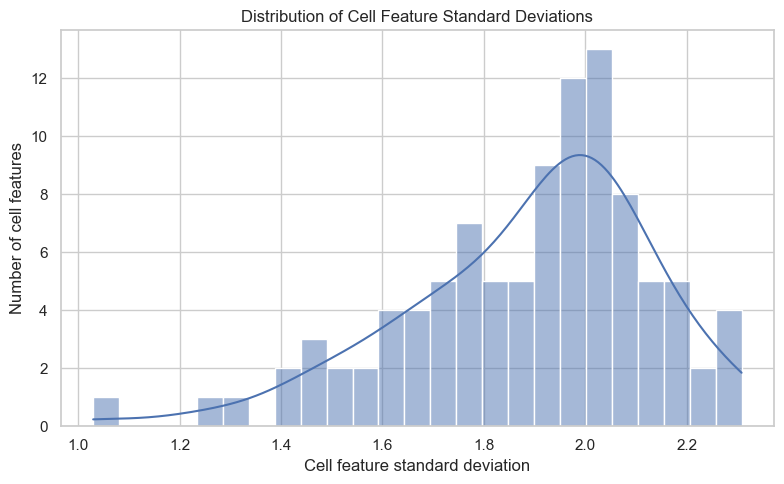

In [87]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=cell_feature_summary,
    x="std",
    bins=25,
    kde=True
)

plt.title("Distribution of Cell Feature Standard Deviations")
plt.xlabel("Cell feature standard deviation")
plt.ylabel("Number of cell features")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_2_cell_feature_std_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

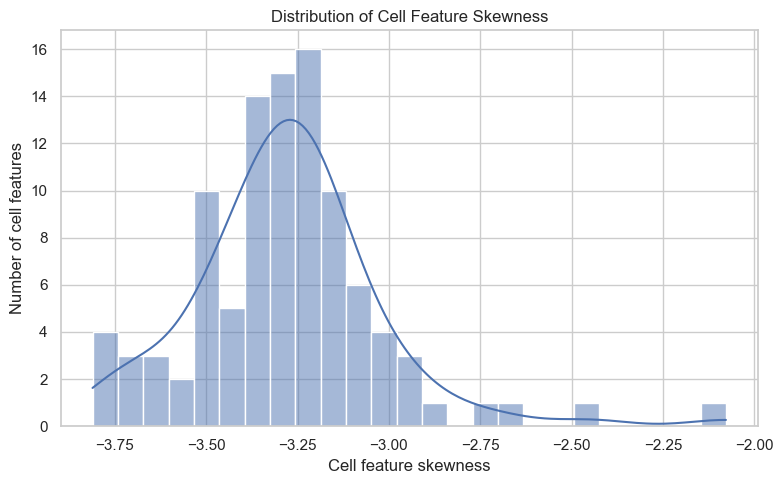

In [88]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=cell_feature_summary,
    x="skew",
    bins=25,
    kde=True
)

plt.title("Distribution of Cell Feature Skewness")
plt.xlabel("Cell feature skewness")
plt.ylabel("Number of cell features")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_2_cell_feature_skew_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5.2.4 Sample-Level Cell Response Summary

Now we summarize cell response at the sample level.

For each sample, we calculate:

- average cell value,
- cell standard deviation,
- average absolute cell response,
- minimum cell value,
- maximum cell value,
- cell response range.

These features may become useful engineered features later.

In [89]:
cell_sample_summary = pd.DataFrame({
    ID_COL: train_features[ID_COL],
    "cell_mean": cell_train_matrix.mean(axis=1).values,
    "cell_std": cell_train_matrix.std(axis=1).values,
    "cell_abs_mean": cell_train_matrix.abs().mean(axis=1).values,
    "cell_min": cell_train_matrix.min(axis=1).values,
    "cell_max": cell_train_matrix.max(axis=1).values
})

cell_sample_summary["cell_range"] = (
    cell_sample_summary["cell_max"] - cell_sample_summary["cell_min"]
)

cell_sample_summary.head()

,sig_id,cell_mean,cell_std,cell_abs_mean,cell_min,cell_max,cell_range
0,id_000644bb2,0.299695,0.515973,0.493259,-1.023,1.4840,2.5070
1,id_000779bfc,0.315757,0.429407,0.444583,-1.278,1.4080,2.6860
2,id_000a6266a,-0.201593,0.596862,0.465793,-2.364,1.1740,3.5380
3,id_0015fd391,-1.765227,1.242490,1.808881,-5.630,0.9197,6.5497
4,id_001626bd3,0.206894,0.491673,0.433450,-1.495,1.1080,2.6030


In [90]:
cell_sample_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
cell_mean,23814.0,-0.432231,1.732086,-9.825370,-0.279837,0.014845,0.244106,2.851115
cell_std,23814.0,0.697236,0.384265,0.327300,0.523868,0.576982,0.653509,3.282324
cell_abs_mean,23814.0,0.961613,1.563950,0.274619,0.456491,0.518177,0.639820,9.825370
cell_min,23814.0,-2.321465,2.257912,-10.000000,-2.114750,-1.580000,-1.222000,0.471500
cell_max,23814.0,1.186492,1.001164,-6.377000,1.048000,1.326000,1.602000,6.412000
cell_range,23814.0,3.507956,1.741174,1.493000,2.600000,2.946700,3.496000,13.599000


#### 5.2.5 Cell Response by Metadata

Now we check whether sample-level cell response changes across treatment type, time, and dose.

The most important comparison is `cp_type`, because control and treated samples may have different cell-response patterns.

In [91]:
cell_sample_with_metadata = (
    train_features[[ID_COL, "cp_type", "cp_time", "cp_dose"]]
    .merge(cell_sample_summary, on=ID_COL, how="left")
)

cell_response_by_metadata = (
    cell_sample_with_metadata
    .groupby(["cp_type", "cp_time", "cp_dose"])
    .agg(
        sample_count=(ID_COL, "count"),
        mean_cell_abs_mean=("cell_abs_mean", "mean"),
        median_cell_abs_mean=("cell_abs_mean", "median"),
        mean_cell_std=("cell_std", "mean"),
        median_cell_std=("cell_std", "median")
    )
    .reset_index()
)

cell_response_by_metadata

,cp_type,cp_time,cp_dose,sample_count,mean_cell_abs_mean,median_cell_abs_mean,mean_cell_std,median_cell_std
0,ctl_vehicle,24,D1,301,0.592723,0.557582,0.581491,0.574717
1,ctl_vehicle,24,D2,305,0.550179,0.524490,0.616533,0.603451
2,ctl_vehicle,48,D1,343,0.617768,0.563395,0.579552,0.556653
3,ctl_vehicle,48,D2,305,0.580328,0.529230,0.579820,0.559680
4,ctl_vehicle,72,D1,307,0.566930,0.491746,0.535113,0.512648
5,ctl_vehicle,72,D2,305,0.555346,0.496540,0.585237,0.559311
6,trt_cp,24,D1,3585,0.857822,0.521204,0.702583,0.587375
7,trt_cp,24,D2,3581,0.786526,0.529702,0.695759,0.611541
8,trt_cp,48,D1,4011,1.057210,0.511552,0.716430,0.567491
9,trt_cp,48,D2,3591,0.943354,0.513404,0.677571,0.566742


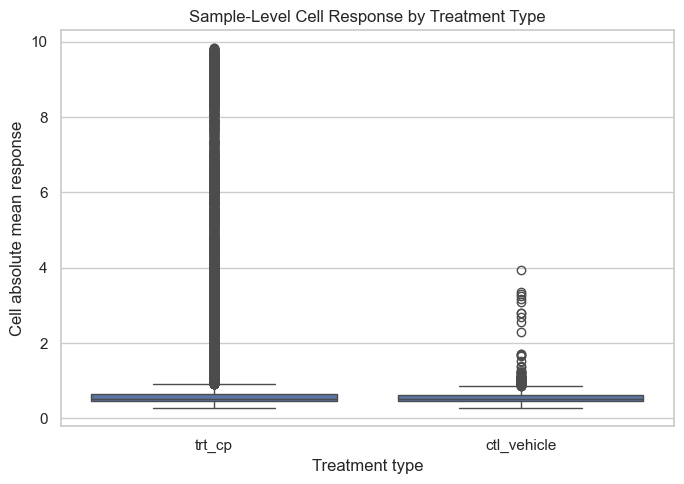

In [92]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=cell_sample_with_metadata,
    x="cp_type",
    y="cell_abs_mean"
)

plt.title("Sample-Level Cell Response by Treatment Type")
plt.xlabel("Treatment type")
plt.ylabel("Cell absolute mean response")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_2_cell_abs_mean_by_cp_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

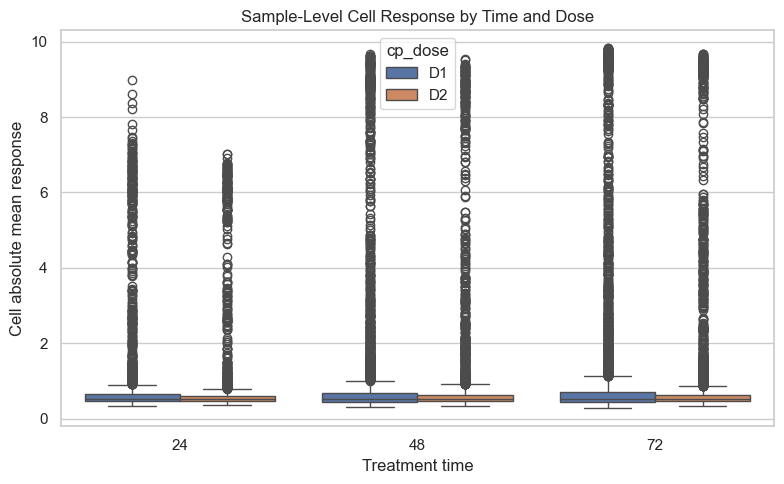

In [93]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=cell_sample_with_metadata,
    x="cp_time",
    y="cell_abs_mean",
    hue="cp_dose"
)

plt.title("Sample-Level Cell Response by Time and Dose")
plt.xlabel("Treatment time")
plt.ylabel("Cell absolute mean response")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_2_cell_abs_mean_by_time_dose.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5.2.6 High-Variance Cell Features

High-variance cell features may contain strong cell-response information.

We rank them for interpretation only.  
We do not manually select or drop them at this EDA stage.

In [94]:
top_high_variance_cells = cell_feature_summary.head(20).copy()

top_high_variance_cells

,feature,mean,std,min,max,skew,abs_mean
0,c-63,-0.613591,2.307820,-10.0,3.549,-3.013355,1.130631
1,c-38,-0.598003,2.297375,-10.0,3.734,-3.035001,1.122843
2,c-18,-0.619461,2.294899,-10.0,3.811,-2.855102,1.156780
3,c-26,-0.597730,2.268931,-10.0,4.144,-2.923114,1.137985
4,c-6,-0.574855,2.234152,-10.0,3.904,-3.107104,1.101471
5,c-65,-0.619682,2.225596,-10.0,3.328,-2.933457,1.126268
6,c-33,-0.545691,2.201552,-10.0,4.258,-3.166203,1.079780
7,c-70,-0.547845,2.187835,-10.0,3.323,-3.201095,1.073375
8,c-13,-0.510905,2.170919,-10.0,4.434,-3.148166,1.075268
9,c-94,-0.507093,2.159589,-10.0,3.747,-3.230885,1.059708


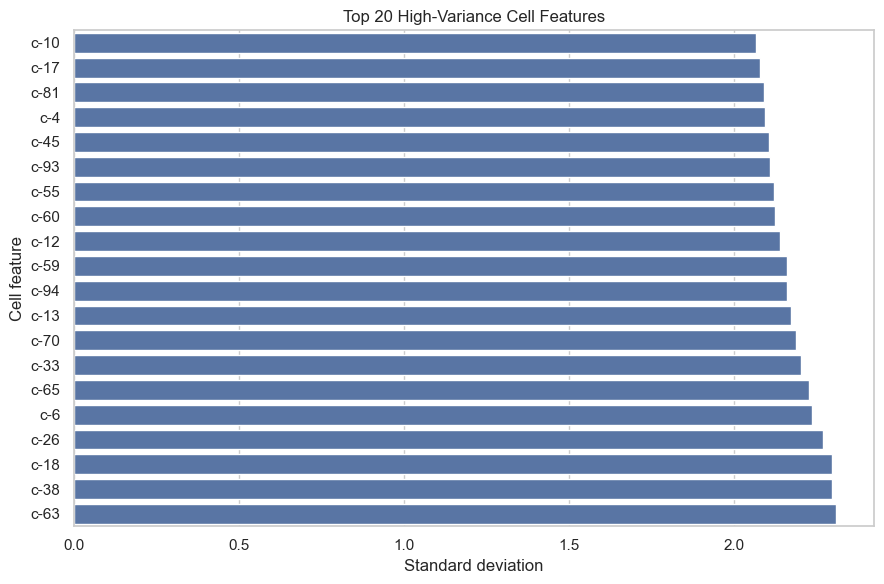

In [95]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_high_variance_cells.sort_values("std", ascending=True),
    x="std",
    y="feature"
)

plt.title("Top 20 High-Variance Cell Features")
plt.xlabel("Standard deviation")
plt.ylabel("Cell feature")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_2_top_high_variance_cell_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5.2.7 Cell Block Thinking Note

The cell-viability block shows a different statistical pattern from the gene-expression block.

Most cell features have relatively high standard deviations, with many features concentrated around approximately 1.7 to 2.1 and a peak close to 2.0. This suggests that the cell block contains strong variation across samples. Compared with the gene block, the cell features appear more tightly concentrated at a higher variance level.

The skewness distribution is strongly negative for almost all cell features. This is an important difference from the gene block, where skewness was spread across both negative and positive values. The negative skewness suggests that cell features have asymmetric distributions, so later preprocessing should be handled carefully. Scaling or robust transformation may be useful, but it must be fitted inside the training pipeline to avoid leakage.

At the sample level, most cell absolute mean responses are concentrated in a stable central range, but there are many strong outliers. Treated samples show much more extreme cell-response outliers than control samples. This suggests that some compounds may cause strong cell-level response or viability-related effects. However, these outliers should not be automatically treated as target-positive samples. They should be considered as potential biological signal and checked later against target activity and validation performance.

The time-dose plot shows that the central cell-response pattern is broadly similar across time and dose groups, but extreme responses appear across multiple groups. This means time and dose may not strongly shift the median cell response, but they may still affect extreme-response samples or specific cell features.

Feature-engineering decisions:

* sample-level cell summary features such as `cell_abs_mean`, `cell_std`, `cell_min`, `cell_max`, and `cell_range` are worth testing later;
* high-variance cell features should be monitored, but not manually selected from EDA alone;
* cell features may require careful scaling because their variance level is relatively high;
* strong cell-response outliers may contain useful biological information, but this must be validated later;
* the next important step is to compare gene and cell summaries to see whether they provide complementary signals.


#### 5.2.8 Cell Block Feature Engineering Decision

This subsection converts the cell-block EDA into a compact feature-engineering decision.

The cell block appears to carry a separate biological response signal from the gene block, especially because cell features show higher variance, strong negative skewness, and clear treatment-related outliers.

In [96]:
cell_block_fe_decision_table = pd.DataFrame({
    "finding": [
        "Cell block has 100 features",
        "Cell features have relatively high variance",
        "Cell features are strongly negatively skewed",
        "Treated samples show stronger cell-response outliers",
        "Time-dose groups have similar central response",
        "Cell outliers may contain biological signal"
    ],
    "evidence": [
        f"{len(cell_features)} c-* features are available",
        "Most cell feature std values are concentrated around roughly 1.7 to 2.1",
        "Skewness values are mostly negative across cell features",
        "trt_cp has many stronger cell_abs_mean outliers than ctl_vehicle",
        "Median cell_abs_mean is broadly similar across cp_time and cp_dose groups",
        "Extreme cell_abs_mean values appear in treated samples"
    ],
    "feature_engineering_decision": [
        "Keep cell block as a separate feature group",
        "Test cell-level summary features later",
        "Use leakage-safe scaling or robust preprocessing inside pipeline",
        "Create candidate features such as cell_abs_mean, cell_std, cell_min, cell_max, cell_range",
        "Keep cp_time and cp_dose; do not overstate their median-level effect",
        "Validate outlier-related features using cross-validation, not EDA alone"
    ]
})

cell_block_fe_decision_table

,finding,evidence,feature_engineering_decision
0,Cell block has 100 features,100 c-* features are available,Keep cell block as a separate feature group
1,Cell features have relatively high variance,Most cell feature std values are concentrated ...,Test cell-level summary features later
2,Cell features are strongly negatively skewed,Skewness values are mostly negative across cel...,Use leakage-safe scaling or robust preprocessi...
3,Treated samples show stronger cell-response ou...,trt_cp has many stronger cell_abs_mean outlier...,Create candidate features such as cell_abs_mea...
4,Time-dose groups have similar central response,Median cell_abs_mean is broadly similar across...,Keep cp_time and cp_dose; do not overstate the...
5,Cell outliers may contain biological signal,Extreme cell_abs_mean values appear in treated...,Validate outlier-related features using cross-...


In [97]:
cell_block_candidate_features = pd.DataFrame({
    "candidate_feature": [
        "cell_mean",
        "cell_std",
        "cell_abs_mean",
        "cell_min",
        "cell_max",
        "cell_range"
    ],
    "why_it_may_help": [
        "captures average cell response direction",
        "captures variation across cell features within a sample",
        "captures overall cell-response strength regardless of sign",
        "captures strongest negative cell response",
        "captures strongest positive cell response",
        "captures spread between extreme cell responses"
    ],
    "use_in_feature_engineering": [
        "yes, test later",
        "yes, test later",
        "yes, test later",
        "yes, test later",
        "yes, test later",
        "yes, test later"
    ]
})

cell_block_candidate_features

,candidate_feature,why_it_may_help,use_in_feature_engineering
0,cell_mean,captures average cell response direction,"yes, test later"
1,cell_std,captures variation across cell features within...,"yes, test later"
2,cell_abs_mean,captures overall cell-response strength regard...,"yes, test later"
3,cell_min,captures strongest negative cell response,"yes, test later"
4,cell_max,captures strongest positive cell response,"yes, test later"
5,cell_range,captures spread between extreme cell responses,"yes, test later"


#### 5.2.10 Cell Block Closing Note

The cell-viability block shows a clear statistical pattern: relatively high variance, strong negative skewness, and many treatment-related outliers.

This suggests that cell features may provide useful information beyond the gene-expression block. However, outliers should not be treated as automatically useful or target-positive. They should be tested later through validation.

For feature engineering, the main candidates are `cell_abs_mean`, `cell_std`, `cell_min`, `cell_max`, and `cell_range`.

The next step is to compare gene and cell summaries directly to check whether they provide complementary signals.

In [98]:
section_5_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
section_5_output_dir.mkdir(parents=True, exist_ok=True)

cell_block_fe_decision_table.to_csv(
    section_5_output_dir / "section_5_2_cell_block_fe_decisions.csv",
    index=False
)

cell_block_candidate_features.to_csv(
    section_5_output_dir / "section_5_2_cell_candidate_features.csv",
    index=False
)

print("Cell block Section 5.2 decision tables saved successfully.")

Cell block Section 5.2 decision tables saved successfully.


### 5.3 Gene vs Cell Block Comparison

Sections 5.1 and 5.2 analyzed the gene and cell blocks separately.

Now we compare them directly.

The goal is to understand whether gene-expression summaries and cell-viability summaries provide similar or complementary information.

This section uses compact block-level summaries, correlation analysis, response relationship plots, and response-group analysis.

#### 5.3.1 Build Combined Gene-Cell Summary Table

First, we combine gene-level and cell-level sample summaries into one table.

This table is used only for EDA and feature-engineering planning.

In [99]:
gene_cell_summary = (
    train_features[[ID_COL, "cp_type", "cp_time", "cp_dose"]]
    .merge(gene_sample_summary, on=ID_COL, how="left")
    .merge(cell_sample_summary, on=ID_COL, how="left")
)

gene_cell_summary.head()

,sig_id,cp_type,cp_time,cp_dose,gene_mean,gene_std,gene_abs_mean,gene_min,gene_max,cell_mean,cell_std,cell_abs_mean,cell_min,cell_max,cell_range
0,id_000644bb2,trt_cp,24,D1,-0.008019,0.774246,0.560740,-5.691,3.394,0.299695,0.515973,0.493259,-1.023,1.4840,2.5070
1,id_000779bfc,trt_cp,72,D1,0.005305,0.770147,0.543174,-5.237,5.566,0.315757,0.429407,0.444583,-1.278,1.4080,2.6860
2,id_000a6266a,trt_cp,48,D1,-0.015395,1.000255,0.685493,-5.164,5.447,-0.201593,0.596862,0.465793,-2.364,1.1740,3.5380
3,id_0015fd391,trt_cp,48,D1,-0.000230,1.190755,0.890835,-4.247,5.391,-1.765227,1.242490,1.808881,-5.630,0.9197,6.5497
4,id_001626bd3,trt_cp,72,D2,-0.024673,1.000048,0.745974,-10.000,4.155,0.206894,0.491673,0.433450,-1.495,1.1080,2.6030


In [100]:
gene_cell_summary_check = {
    "rows": gene_cell_summary.shape[0],
    "columns": gene_cell_summary.shape[1],
    "missing_values": int(gene_cell_summary.isna().sum().sum()),
    "gene_columns_present": all(
        col in gene_cell_summary.columns
        for col in ["gene_mean", "gene_std", "gene_abs_mean", "gene_min", "gene_max"]
    ),
    "cell_columns_present": all(
        col in gene_cell_summary.columns
        for col in ["cell_mean", "cell_std", "cell_abs_mean", "cell_min", "cell_max", "cell_range"]
    )
}

gene_cell_summary_check

{'rows': 23814,
 'columns': 15,
 'missing_values': 0,
 'gene_columns_present': True,
 'cell_columns_present': True}

#### 5.3.2 Compact Gene vs Cell Summary Comparison

Now we compare the main sample-level gene and cell summaries.

This helps us see whether the cell block has stronger response magnitude or variation than the gene block.

In [101]:
gene_cell_block_comparison = pd.DataFrame({
    "summary_metric": [
        "abs_mean",
        "std",
        "min",
        "max"
    ],
    "gene_median": [
        gene_cell_summary["gene_abs_mean"].median(),
        gene_cell_summary["gene_std"].median(),
        gene_cell_summary["gene_min"].median(),
        gene_cell_summary["gene_max"].median()
    ],
    "cell_median": [
        gene_cell_summary["cell_abs_mean"].median(),
        gene_cell_summary["cell_std"].median(),
        gene_cell_summary["cell_min"].median(),
        gene_cell_summary["cell_max"].median()
    ],
    "gene_max": [
        gene_cell_summary["gene_abs_mean"].max(),
        gene_cell_summary["gene_std"].max(),
        gene_cell_summary["gene_min"].max(),
        gene_cell_summary["gene_max"].max()
    ],
    "cell_max": [
        gene_cell_summary["cell_abs_mean"].max(),
        gene_cell_summary["cell_std"].max(),
        gene_cell_summary["cell_min"].max(),
        gene_cell_summary["cell_max"].max()
    ]
})

gene_cell_block_comparison

,summary_metric,gene_median,cell_median,gene_max,cell_max
0,abs_mean,0.586098,0.518177,7.260411,9.825370
1,std,0.810838,0.576982,7.988689,3.282324
2,min,-5.004000,-1.580000,-1.550000,0.471500
3,max,4.946000,1.326000,10.000000,6.412000


#### 5.3.3 Gene-Cell Summary Correlation

Now we check whether sample-level gene summaries and cell summaries move together.

We only compare summary features, not all 772 × 100 feature pairs.

In [102]:
gene_cell_corr_features = [
    "gene_mean", "gene_std", "gene_abs_mean", "gene_min", "gene_max",
    "cell_mean", "cell_std", "cell_abs_mean", "cell_min", "cell_max", "cell_range"
]

gene_cell_summary_correlation = (
    gene_cell_summary[gene_cell_corr_features]
    .corr(method="spearman")
)

gene_cell_summary_correlation.loc[
    ["gene_mean", "gene_std", "gene_abs_mean", "gene_min", "gene_max"],
    ["cell_mean", "cell_std", "cell_abs_mean", "cell_min", "cell_max", "cell_range"]
]

,cell_mean,cell_std,cell_abs_mean,cell_min,cell_max,cell_range
gene_mean,0.112557,-0.084765,-0.029836,0.091650,0.080870,-0.065369
gene_std,-0.328145,0.523180,0.500512,-0.427453,-0.113210,0.477758
gene_abs_mean,-0.320973,0.523682,0.510736,-0.424820,-0.110536,0.477291
gene_min,0.264850,-0.351921,-0.336463,0.308988,0.126777,-0.333801
gene_max,-0.277974,0.389487,0.354433,-0.337493,-0.118797,0.366844


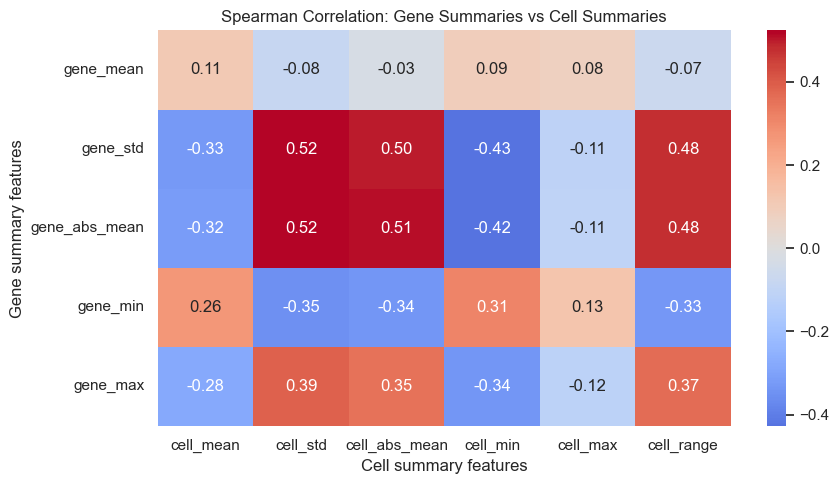

In [103]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    gene_cell_summary_correlation.loc[
        ["gene_mean", "gene_std", "gene_abs_mean", "gene_min", "gene_max"],
        ["cell_mean", "cell_std", "cell_abs_mean", "cell_min", "cell_max", "cell_range"]
    ],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation: Gene Summaries vs Cell Summaries")
plt.xlabel("Cell summary features")
plt.ylabel("Gene summary features")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_3_gene_cell_summary_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5.3.4 Gene vs Cell Response Relationship Plot

This plot compares sample-level gene-response strength and cell-response strength.

A hexbin plot is used instead of a normal scatter plot because many samples overlap.

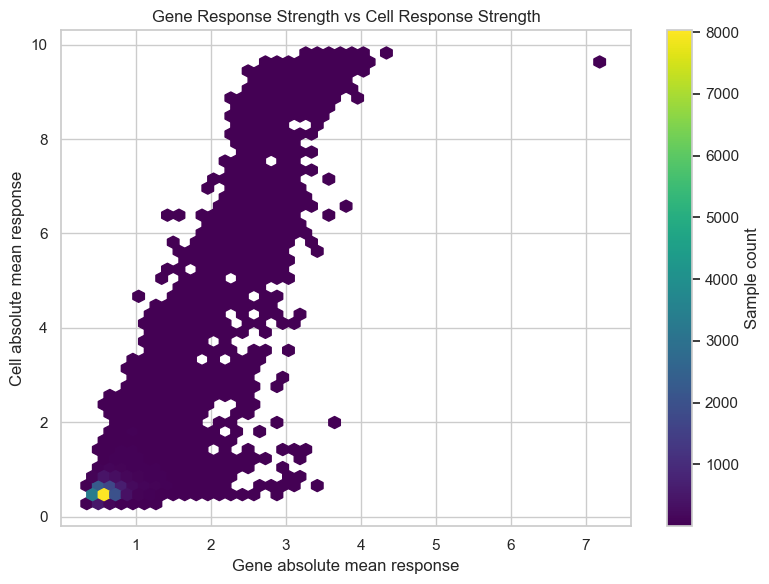

In [104]:
plt.figure(figsize=(8, 6))

plt.hexbin(
    gene_cell_summary["gene_abs_mean"],
    gene_cell_summary["cell_abs_mean"],
    gridsize=45,
    mincnt=1,
    cmap="viridis"
)

plt.colorbar(label="Sample count")
plt.title("Gene Response Strength vs Cell Response Strength")
plt.xlabel("Gene absolute mean response")
plt.ylabel("Cell absolute mean response")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_3_gene_abs_mean_vs_cell_abs_mean_hexbin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5.3.5 Gene-Cell Response Level Grid

Instead of using only a top-10% high-response threshold, we divide the full dataset into three response levels:

- Low response
- Middle response
- High response

This gives a fuller view of how gene-response strength and cell-response strength interact across all samples.

In [105]:
response_level_order = ["Low", "Middle", "High"]

gene_cell_summary["gene_response_level"] = pd.qcut(
    gene_cell_summary["gene_abs_mean"].rank(method="first"),
    q=3,
    labels=response_level_order
)

gene_cell_summary["cell_response_level"] = pd.qcut(
    gene_cell_summary["cell_abs_mean"].rank(method="first"),
    q=3,
    labels=response_level_order
)

gene_cell_response_grid_summary = (
    gene_cell_summary
    .groupby(["gene_response_level", "cell_response_level"], observed=False)
    .agg(sample_count=(ID_COL, "count"))
    .reset_index()
)

gene_cell_response_grid_summary["sample_percentage"] = (
    gene_cell_response_grid_summary["sample_count"] / len(gene_cell_summary) * 100
)

gene_cell_response_grid_summary

,gene_response_level,cell_response_level,sample_count,sample_percentage
0,Low,Low,3848,16.158562
1,Low,Middle,2952,12.396070
2,Low,High,1138,4.778702
3,Middle,Low,2959,12.425464
4,Middle,Middle,3142,13.193920
5,Middle,High,1837,7.713950
6,High,Low,1131,4.749307
7,High,Middle,1844,7.743344
8,High,High,4963,20.840682


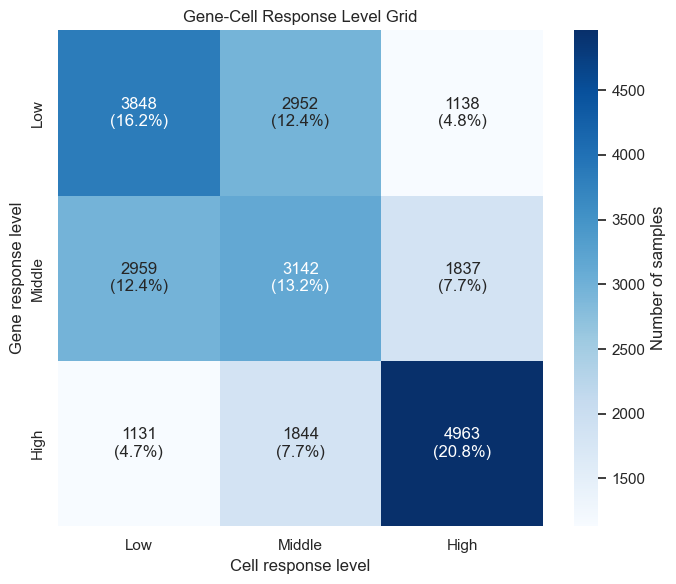

In [106]:
response_grid_count = gene_cell_response_grid_summary.pivot(
    index="gene_response_level",
    columns="cell_response_level",
    values="sample_count"
).reindex(index=response_level_order, columns=response_level_order)

response_grid_percentage = gene_cell_response_grid_summary.pivot(
    index="gene_response_level",
    columns="cell_response_level",
    values="sample_percentage"
).reindex(index=response_level_order, columns=response_level_order)

response_grid_annotation = response_grid_count.astype(int).astype(str) + "\n(" + response_grid_percentage.round(1).astype(str) + "%)"

plt.figure(figsize=(7, 6))

sns.heatmap(
    response_grid_count,
    annot=response_grid_annotation,
    fmt="",
    cmap="Blues",
    cbar_kws={"label": "Number of samples"}
)

plt.title("Gene-Cell Response Level Grid")
plt.xlabel("Cell response level")
plt.ylabel("Gene response level")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_3_gene_cell_response_level_grid.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5.3.6 Gene-Cell Response Grid and Target Activity

Now we check whether target activity changes across the gene-cell response grid.

This is still an EDA-only sanity check.  
`active_target_count` is target-derived and must not be used as an input feature.

In [107]:
target_activity_for_response_check = pd.DataFrame({
    ID_COL: y_scored[ID_COL],
    "active_target_count": y_scored_matrix.sum(axis=1).values
})

gene_cell_response_target_check = (
    gene_cell_summary[[ID_COL, "gene_response_level", "cell_response_level"]]
    .merge(target_activity_for_response_check, on=ID_COL, how="left")
)

gene_cell_response_target_summary = (
    gene_cell_response_target_check
    .groupby(["gene_response_level", "cell_response_level"], observed=False)
    .agg(
        sample_count=(ID_COL, "count"),
        mean_active_target_count=("active_target_count", "mean"),
        median_active_target_count=("active_target_count", "median"),
        max_active_target_count=("active_target_count", "max")
    )
    .reset_index()
)

gene_cell_response_target_summary

,gene_response_level,cell_response_level,sample_count,mean_active_target_count,median_active_target_count,max_active_target_count
0,Low,Low,3848,0.645010,1.0,5
1,Low,Middle,2952,0.644648,1.0,4
2,Low,High,1138,0.659051,1.0,4
3,Middle,Low,2959,0.625549,1.0,4
4,Middle,Middle,3142,0.673775,1.0,5
5,Middle,High,1837,0.649428,1.0,4
6,High,Low,1131,0.575597,1.0,4
7,High,Middle,1844,0.661605,1.0,5
8,High,High,4963,0.942374,1.0,7


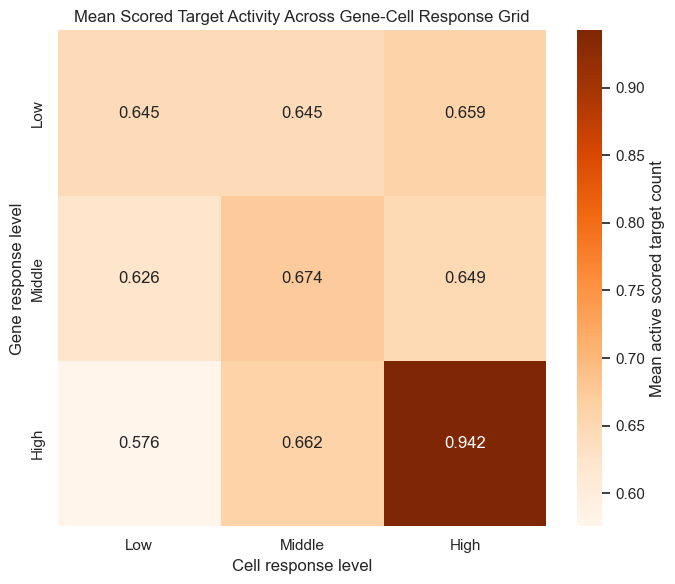

In [108]:
target_activity_grid = gene_cell_response_target_summary.pivot(
    index="gene_response_level",
    columns="cell_response_level",
    values="mean_active_target_count"
).reindex(index=response_level_order, columns=response_level_order)

plt.figure(figsize=(7, 6))

sns.heatmap(
    target_activity_grid,
    annot=True,
    fmt=".3f",
    cmap="Oranges",
    cbar_kws={"label": "Mean active scored target count"}
)

plt.title("Mean Scored Target Activity Across Gene-Cell Response Grid")
plt.xlabel("Cell response level")
plt.ylabel("Gene response level")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_3_gene_cell_response_grid_target_activity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

| Gene level | Cell level | Mean active target count | Meaning                   |
| ---------- | ---------- | -----------------------: | ------------------------- |
| High       | High       |                **0.942** | strongest target activity |
| Middle     | Middle     |                    0.674 | moderate                  |
| Low        | High       |                    0.659 | mild                      |
| High       | Middle     |                    0.662 | mild/moderate             |
| High       | Low        |                **0.576** | lowest                    |


#### 5.3.7 Gene-Cell Response Grid Thinking Note

The full gene-cell response grid provides stronger evidence than the earlier top-10% grouping.

The highest mean scored-target activity appears in the `High gene / High cell` group, with a mean active target count of **0.942**. This is clearly higher than the other response combinations, which mostly stay around **0.62 to 0.67**.

An important observation is that high gene response alone is not enough. The `High gene / Low cell` group has the lowest mean active target count. This suggests that strong gene response becomes more informative when it appears together with strong cell response.

Similarly, high cell response alone does not create the strongest signal. The `Low gene / High cell` group has only moderate target activity. Therefore, the strongest evidence is not from either block alone, but from the joint high-response region.

This supports the idea that gene and cell blocks are related but complementary. The model may benefit from both separate summary features and cross-block interaction features.

Feature-engineering decisions:

* keep gene-level summary features and cell-level summary features separately;
* test continuous cross-block features such as `gene_abs_mean * cell_abs_mean`, `gene_minus_cell_abs_mean`, and `gene_to_cell_abs_mean_ratio`;
* test response-level interaction features carefully, such as `gene_response_level × cell_response_level`;
* treat the `High gene / High cell` pattern as a strong candidate signal, not as final proof;
* all threshold-based features must be validated properly and should not be fitted using the full dataset inside the modeling pipeline.


In [109]:
gene_cell_cross_block_decision_table = pd.DataFrame({
    "finding": [
        "Gene and cell summaries are moderately related",
        "High gene / high cell group has strongest target activity",
        "High gene alone is not enough",
        "High cell alone is not enough",
        "Cross-block interaction may be useful",
        "Response-level thresholds are EDA-only"
    ],
    "evidence": [
        "gene_abs_mean and gene_std show moderate correlation with cell_abs_mean, cell_std, and cell_range",
        "High gene / High cell group has the highest mean active scored-target count",
        "High gene / Low cell group does not show the strongest target activity",
        "Low gene / High cell group also does not show the strongest target activity",
        "Joint gene-cell response separates target activity better than single-block response alone",
        "Low/Middle/High groups were created from full-data quantiles for EDA interpretation"
    ],
    "feature_engineering_decision": [
        "Keep gene and cell summary features separately",
        "Test joint high-response or interaction features later",
        "Do not rely only on gene response summaries",
        "Do not rely only on cell response summaries",
        "Test product, ratio, difference, and interaction-style features",
        "Fit any thresholds only inside cross-validation to avoid leakage"
    ]
})

gene_cell_cross_block_decision_table

,finding,evidence,feature_engineering_decision
0,Gene and cell summaries are moderately related,gene_abs_mean and gene_std show moderate corre...,Keep gene and cell summary features separately
1,High gene / high cell group has strongest targ...,High gene / High cell group has the highest me...,Test joint high-response or interaction featur...
2,High gene alone is not enough,High gene / Low cell group does not show the s...,Do not rely only on gene response summaries
3,High cell alone is not enough,Low gene / High cell group also does not show ...,Do not rely only on cell response summaries
4,Cross-block interaction may be useful,Joint gene-cell response separates target acti...,"Test product, ratio, difference, and interacti..."
5,Response-level thresholds are EDA-only,Low/Middle/High groups were created from full-...,Fit any thresholds only inside cross-validatio...


In [110]:
section_5_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
section_5_output_dir.mkdir(parents=True, exist_ok=True)

gene_cell_cross_block_decision_table.to_csv(
    section_5_output_dir / "section_5_3_gene_cell_cross_block_decisions.csv",
    index=False
)

print("Section 5.3 gene-cell cross-block decision table saved successfully.")

Section 5.3 gene-cell cross-block decision table saved successfully.


### 5.4 Train-Test Feature Block Shift Check

This subsection checks whether biological input features behave similarly in train and test data.

The goal is not to remove shifted features immediately.  
The goal is to identify whether some gene or cell features show noticeable distribution shift and should be monitored during modeling.

We compare train and test using feature-level mean and standard deviation differences.

#### 5.4.1 Define Train-Test Shift Metrics

For each feature, we calculate:

- train mean,
- test mean,
- absolute mean difference,
- train standard deviation,
- test standard deviation,
- absolute standard deviation difference,
- standardized mean shift.

The standardized mean shift is useful because it compares the train-test mean difference against the normal variation of that feature.

In [111]:
def compute_feature_shift_summary(train_df, test_df, feature_list, block_name):
    train_block = train_df[feature_list]
    test_block = test_df[feature_list]
    
    train_mean = train_block.mean(axis=0)
    test_mean = test_block.mean(axis=0)
    
    train_std = train_block.std(axis=0)
    test_std = test_block.std(axis=0)
    
    mean_abs_difference = (train_mean - test_mean).abs()
    std_abs_difference = (train_std - test_std).abs()
    
    standardized_mean_shift = mean_abs_difference / train_std.replace(0, np.nan)
    
    shift_summary = pd.DataFrame({
        "feature": feature_list,
        "feature_block": block_name,
        "train_mean": train_mean.values,
        "test_mean": test_mean.values,
        "mean_abs_difference": mean_abs_difference.values,
        "train_std": train_std.values,
        "test_std": test_std.values,
        "std_abs_difference": std_abs_difference.values,
        "standardized_mean_shift": standardized_mean_shift.values
    })
    
    shift_summary = shift_summary.sort_values(
        "standardized_mean_shift",
        ascending=False
    ).reset_index(drop=True)
    
    return shift_summary

#### 5.4.2 Gene Feature Shift Ranking

Now we rank gene features by standardized train-test mean shift.

This helps us identify which gene features behave most differently between train and test data.

In [112]:
gene_shift_summary = compute_feature_shift_summary(
    train_df=train_features,
    test_df=test_features,
    feature_list=gene_features,
    block_name="Gene"
)

top_shifted_genes = gene_shift_summary.head(20).copy()

gene_shift_summary

,feature,feature_block,train_mean,test_mean,mean_abs_difference,train_std,test_std,std_abs_difference,standardized_mean_shift
0,g-101,Gene,0.149191,0.076896,0.072295,1.030329,1.006658,0.023671,0.070167
1,g-135,Gene,0.181764,0.108264,0.073500,1.074660,0.980348,0.094312,0.068394
2,g-22,Gene,0.047548,-0.015484,0.063032,0.924838,0.907731,0.017107,0.068155
3,g-392,Gene,0.537320,0.409563,0.127758,1.989753,1.808295,0.181458,0.064208
4,g-656,Gene,-0.075974,-0.145340,0.069366,1.081813,1.084861,0.003048,0.064120
...,...,...,...,...,...,...,...,...,...
767,g-530,Gene,-0.152178,-0.152348,0.000170,1.178893,1.142107,0.036786,0.000144
768,g-260,Gene,0.038577,0.038656,0.000079,0.970519,0.937805,0.032714,0.000081
769,g-219,Gene,0.046375,0.046420,0.000045,0.577300,0.593122,0.015822,0.000078
770,g-711,Gene,0.049409,0.049346,0.000063,1.487562,1.492472,0.004910,0.000042


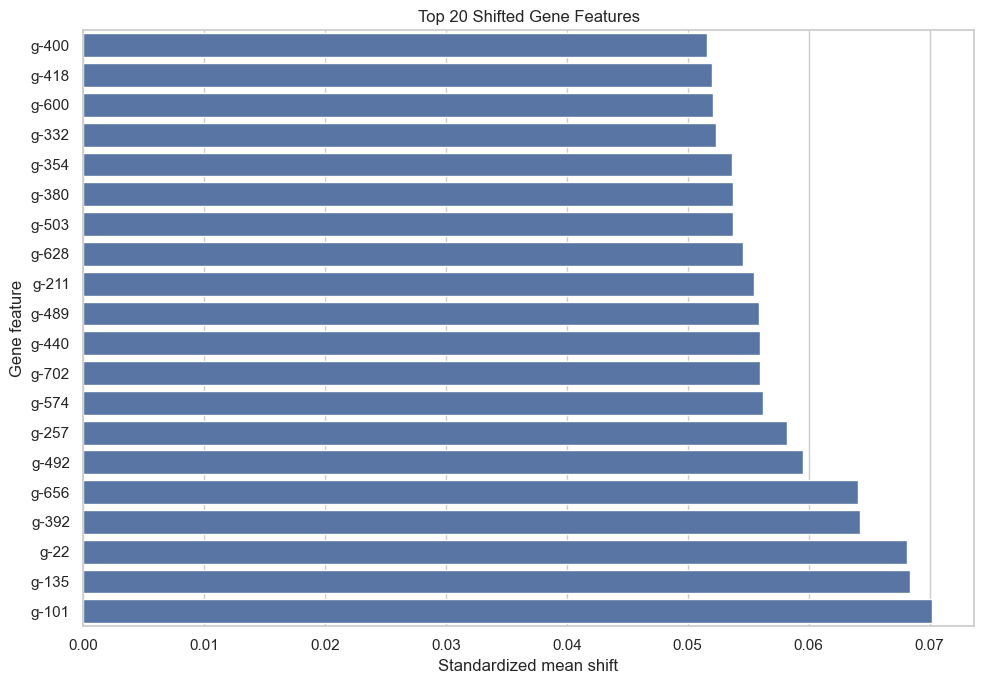

In [113]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_shifted_genes.sort_values("standardized_mean_shift", ascending=True),
    x="standardized_mean_shift",
    y="feature"
)

plt.title("Top 20 Shifted Gene Features")
plt.xlabel("Standardized mean shift")
plt.ylabel("Gene feature")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_4_top_shifted_gene_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5.4.3 Cell Feature Shift Ranking

Now we apply the same shift check to the cell-viability block.

This tells us whether cell features show stronger or weaker train-test distribution shift compared with gene features.

In [114]:
cell_shift_summary = compute_feature_shift_summary(
    train_df=train_features,
    test_df=test_features,
    feature_list=cell_features,
    block_name="Cell"
)

top_shifted_cells = cell_shift_summary.head(20).copy()

top_shifted_cells

,feature,feature_block,train_mean,test_mean,mean_abs_difference,train_std,test_std,std_abs_difference,standardized_mean_shift
0,c-9,Cell,-0.458664,-0.382526,0.076138,1.646122,1.617490,0.028633,0.046253
1,c-22,Cell,-0.383134,-0.311419,0.071716,1.690235,1.619514,0.070721,0.042429
2,c-10,Cell,-0.486027,-0.408499,0.077528,2.066695,1.973928,0.092767,0.037513
3,c-18,Cell,-0.619461,-0.533563,0.085898,2.294899,2.207290,0.087609,0.037430
4,c-97,Cell,-0.378241,-0.316387,0.061854,1.703615,1.655524,0.048091,0.036308
5,c-70,Cell,-0.547845,-0.469294,0.078552,2.187835,2.125576,0.062259,0.035904
6,c-98,Cell,-0.470252,-0.404859,0.065393,1.834828,1.790883,0.043945,0.035640
7,c-49,Cell,-0.391396,-0.333493,0.057903,1.721804,1.689380,0.032424,0.033629
8,c-47,Cell,-0.460295,-0.400548,0.059747,1.874856,1.871993,0.002863,0.031867
9,c-26,Cell,-0.597730,-0.525723,0.072007,2.268931,2.229765,0.039166,0.031736


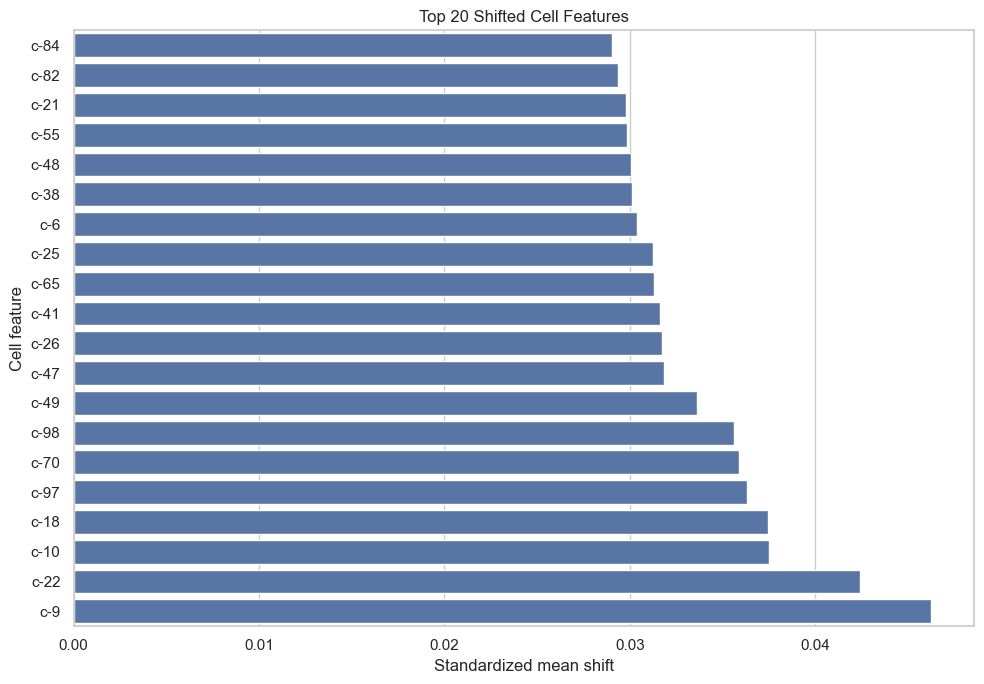

In [115]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_shifted_cells.sort_values("standardized_mean_shift", ascending=True),
    x="standardized_mean_shift",
    y="feature"
)

plt.title("Top 20 Shifted Cell Features")
plt.xlabel("Standardized mean shift")
plt.ylabel("Cell feature")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_4_top_shifted_cell_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5.4.4 Gene vs Cell Overall Shift Comparison

Now we compare overall shift behavior between the gene and cell blocks.

This helps us decide whether one biological block is more unstable between train and test.

In [116]:
combined_shift_summary = pd.concat(
    [gene_shift_summary, cell_shift_summary],
    axis=0,
    ignore_index=True
)

block_shift_comparison = (
    combined_shift_summary
    .groupby("feature_block")
    .agg(
        feature_count=("feature", "count"),
        median_standardized_shift=("standardized_mean_shift", "median"),
        mean_standardized_shift=("standardized_mean_shift", "mean"),
        max_standardized_shift=("standardized_mean_shift", "max"),
        median_mean_abs_difference=("mean_abs_difference", "median"),
        median_std_abs_difference=("std_abs_difference", "median")
    )
    .reset_index()
)

block_shift_comparison

,feature_block,feature_count,median_standardized_shift,mean_standardized_shift,max_standardized_shift,median_mean_abs_difference,median_std_abs_difference
0,Cell,100,0.019387,0.019803,0.046253,0.038191,0.020109
1,Gene,772,0.016229,0.018633,0.070167,0.018382,0.023471


In [117]:
top_shifted_features_overall = (
    combined_shift_summary
    .sort_values("standardized_mean_shift", ascending=False)
    .head(20)
    .copy()
)

top_shifted_features_overall

,feature,feature_block,train_mean,test_mean,mean_abs_difference,train_std,test_std,std_abs_difference,standardized_mean_shift
0,g-101,Gene,0.149191,0.076896,0.072295,1.030329,1.006658,0.023671,0.070167
1,g-135,Gene,0.181764,0.108264,0.073500,1.074660,0.980348,0.094312,0.068394
2,g-22,Gene,0.047548,-0.015484,0.063032,0.924838,0.907731,0.017107,0.068155
3,g-392,Gene,0.537320,0.409563,0.127758,1.989753,1.808295,0.181458,0.064208
4,g-656,Gene,-0.075974,-0.145340,0.069366,1.081813,1.084861,0.003048,0.064120
5,g-492,Gene,0.041784,-0.028023,0.069808,1.172469,1.139658,0.032811,0.059539
6,g-257,Gene,-0.472073,-0.363558,0.108515,1.864766,1.756760,0.108006,0.058192
7,g-574,Gene,-0.244458,-0.174033,0.070424,1.252934,1.230127,0.022807,0.056208
8,g-702,Gene,-0.126025,-0.069062,0.056964,1.017420,0.979738,0.037681,0.055988
9,g-440,Gene,-0.198593,-0.137399,0.061193,1.093199,1.028213,0.064986,0.055976


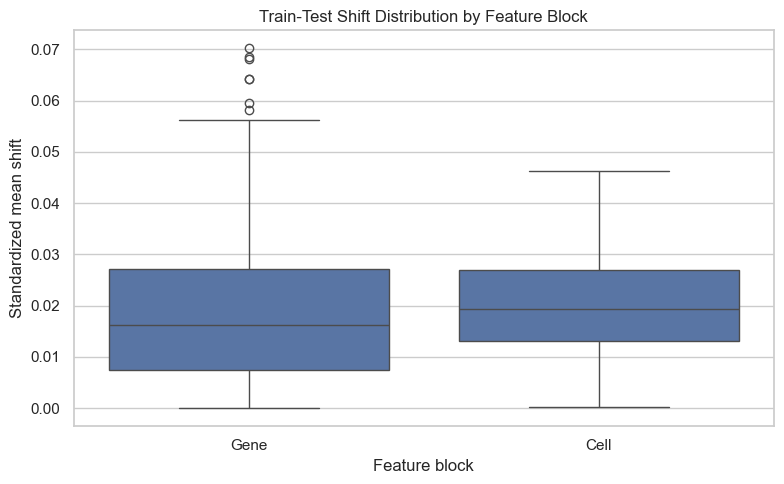

In [118]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=combined_shift_summary,
    x="feature_block",
    y="standardized_mean_shift"
)

plt.title("Train-Test Shift Distribution by Feature Block")
plt.xlabel("Feature block")
plt.ylabel("Standardized mean shift")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_5_4_gene_vs_cell_shift_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5.4.5 Train-Test Shift Thinking Note

The train-test shift check shows that the biological feature blocks are mostly stable between train and test data.

For both gene and cell features, most standardized mean shifts are small. This suggests that the overall train and test feature distributions are reasonably aligned.

The gene block shows a few noticeable shifted features, with the largest standardized mean shifts around 0.06 to 0.07. However, this is still small relative to the feature-level standard deviation. Because the gene block contains 772 features, seeing a few higher-shift outliers is expected and does not automatically indicate a serious distribution problem.

The cell block has a similar central shift range, but it shows fewer extreme shifted outliers compared with the gene block. Its maximum standardized shift appears lower than the top gene shifts.

The main decision is that no gene or cell feature should be removed based on this EDA alone. The top shifted features should be monitored during modeling, but feature dropping, scaling, PCA, or selection should depend on cross-validation performance.

Feature-engineering implications:

* keep both gene and cell blocks;
* monitor top shifted gene and cell features;
* use leakage-safe scaling or robust preprocessing inside the modeling pipeline;
* do not fit scalers, PCA, or feature selectors on combined train-test data;
* do not drop shifted features without validation evidence.


In [119]:
shift_check_decision_table = pd.DataFrame({
    "finding": [
        "Most gene and cell features have small train-test shift",
        "Gene block has a few higher-shift outliers",
        "Cell block has fewer extreme shift outliers",
        "Top shifted features are not severely shifted",
        "EDA shift does not justify feature removal"
    ],
    "interpretation": [
        "Train and test biological feature distributions are broadly aligned",
        "Some gene features should be monitored during modeling",
        "Cell block appears slightly more stable in the extreme tail",
        "Largest shifts are still small relative to feature standard deviation",
        "Shifted features may still contain useful biological signal"
    ],
    "decision": [
        "Keep gene and cell blocks",
        "Monitor top shifted gene features",
        "Monitor top shifted cell features",
        "Use leakage-safe preprocessing inside CV pipeline",
        "Do not drop features from EDA alone"
    ]
})

shift_check_decision_table

,finding,interpretation,decision
0,Most gene and cell features have small train-t...,Train and test biological feature distribution...,Keep gene and cell blocks
1,Gene block has a few higher-shift outliers,Some gene features should be monitored during ...,Monitor top shifted gene features
2,Cell block has fewer extreme shift outliers,Cell block appears slightly more stable in the...,Monitor top shifted cell features
3,Top shifted features are not severely shifted,Largest shifts are still small relative to fea...,Use leakage-safe preprocessing inside CV pipeline
4,EDA shift does not justify feature removal,Shifted features may still contain useful biol...,Do not drop features from EDA alone


In [120]:
section_5_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
section_5_output_dir.mkdir(parents=True, exist_ok=True)

gene_shift_summary.to_csv(
    section_5_output_dir / "section_5_4_gene_shift_summary.csv",
    index=False
)

cell_shift_summary.to_csv(
    section_5_output_dir / "section_5_4_cell_shift_summary.csv",
    index=False
)

block_shift_comparison.to_csv(
    section_5_output_dir / "section_5_4_block_shift_comparison.csv",
    index=False
)

top_shifted_genes.to_csv(
    section_5_output_dir / "section_5_4_top_shifted_genes.csv",
    index=False
)

top_shifted_cells.to_csv(
    section_5_output_dir / "section_5_4_top_shifted_cells.csv",
    index=False
)

shift_check_decision_table.to_csv(
    section_5_output_dir / "section_5_4_shift_check_decision_table.csv",
    index=False
)

print("Section 5.4 train-test shift outputs saved successfully.")

Section 5.4 train-test shift outputs saved successfully.


### 5.5 Section 5 Feature Engineering Handoff

Section 5 analyzed the biological input feature blocks: gene features, cell features, gene-cell interaction patterns, and train-test feature shift.

This subsection converts those EDA findings into a compact feature-engineering handoff.

No new feature is created here for final modeling.  
The goal is to define what should be tested later in `03_feature_engineering.ipynb`.

In [121]:
section_5_key_findings = pd.DataFrame({
    "area": [
        "Gene block",
        "Cell block",
        "Gene-cell relationship",
        "Gene-cell response grid",
        "Train-test shift"
    ],
    "key_finding": [
        "Gene features show meaningful variation, skewness, and response outliers",
        "Cell features show higher variance, strong negative skewness, and treatment-related outliers",
        "Gene and cell summaries are moderately related but not identical",
        "High gene / High cell response has the strongest mean scored-target activity",
        "Gene and cell blocks are broadly stable between train and test data"
    ],
    "why_it_matters": [
        "Gene summary features may capture useful transcriptomic response strength",
        "Cell summary features may capture viability-related biological response",
        "Both blocks may provide complementary predictive signal",
        "Cross-block interaction features may be useful",
        "No feature should be removed from EDA alone"
    ],
    "action_for_feature_engineering": [
        "Test gene summary features",
        "Test cell summary features",
        "Keep gene and cell summaries separately",
        "Test gene-cell interaction features",
        "Monitor shifted features and use leakage-safe preprocessing"
    ]
})

section_5_key_findings

,area,key_finding,why_it_matters,action_for_feature_engineering
0,Gene block,"Gene features show meaningful variation, skewn...",Gene summary features may capture useful trans...,Test gene summary features
1,Cell block,"Cell features show higher variance, strong neg...",Cell summary features may capture viability-re...,Test cell summary features
2,Gene-cell relationship,Gene and cell summaries are moderately related...,Both blocks may provide complementary predicti...,Keep gene and cell summaries separately
3,Gene-cell response grid,High gene / High cell response has the stronge...,Cross-block interaction features may be useful,Test gene-cell interaction features
4,Train-test shift,Gene and cell blocks are broadly stable betwee...,No feature should be removed from EDA alone,Monitor shifted features and use leakage-safe ...


#### 5.5.2 Baseline Feature Engineering Candidates

These features are safe baseline candidates because they are calculated only from input gene and cell features.

They do not use target labels.

In [122]:
section_5_baseline_feature_candidates = pd.DataFrame({
    "candidate_feature": [
        "gene_mean",
        "gene_std",
        "gene_abs_mean",
        "gene_min",
        "gene_max",
        "cell_mean",
        "cell_std",
        "cell_abs_mean",
        "cell_min",
        "cell_max",
        "cell_range",
        "gene_minus_cell_abs_mean",
        "gene_to_cell_abs_mean_ratio",
        "gene_cell_abs_mean_product"
    ],
    "feature_group": [
        "gene summary",
        "gene summary",
        "gene summary",
        "gene summary",
        "gene summary",
        "cell summary",
        "cell summary",
        "cell summary",
        "cell summary",
        "cell summary",
        "cell summary",
        "cross-block interaction",
        "cross-block interaction",
        "cross-block interaction"
    ],
    "why_test_it": [
        "captures average gene-response direction",
        "captures spread of gene response",
        "captures overall gene-response strength",
        "captures strongest negative gene response",
        "captures strongest positive gene response",
        "captures average cell-response direction",
        "captures spread of cell response",
        "captures overall cell-response strength",
        "captures strongest negative cell response",
        "captures strongest positive cell response",
        "captures cell response range",
        "captures difference between gene and cell response strength",
        "captures relative gene response compared with cell response",
        "captures joint high gene-cell response"
    ],
    "priority": [
        "baseline",
        "baseline",
        "baseline",
        "baseline",
        "baseline",
        "baseline",
        "baseline",
        "baseline",
        "baseline",
        "baseline",
        "baseline",
        "baseline",
        "baseline",
        "baseline"
    ]
})

section_5_baseline_feature_candidates

,candidate_feature,feature_group,why_test_it,priority
0,gene_mean,gene summary,captures average gene-response direction,baseline
1,gene_std,gene summary,captures spread of gene response,baseline
2,gene_abs_mean,gene summary,captures overall gene-response strength,baseline
3,gene_min,gene summary,captures strongest negative gene response,baseline
4,gene_max,gene summary,captures strongest positive gene response,baseline
5,cell_mean,cell summary,captures average cell-response direction,baseline
6,cell_std,cell summary,captures spread of cell response,baseline
7,cell_abs_mean,cell summary,captures overall cell-response strength,baseline
8,cell_min,cell summary,captures strongest negative cell response,baseline
9,cell_max,cell summary,captures strongest positive cell response,baseline


#### 5.5.3 Advanced Feature Engineering Candidates

These features are more advanced because they may require thresholds, dimensionality reduction, or careful validation.

They should be tested only after the baseline feature set is working.

In [123]:
section_5_advanced_feature_candidates = pd.DataFrame({
    "candidate_feature_or_method": [
        "gene_pca_components",
        "cell_pca_components",
        "combined_gene_cell_pca_components",
        "gene_high_response_flag",
        "cell_high_response_flag",
        "gene_response_level",
        "cell_response_level",
        "gene_cell_response_level_interaction",
        "top_shifted_feature_monitoring",
        "robust_scaling"
    ],
    "type": [
        "dimensionality reduction",
        "dimensionality reduction",
        "dimensionality reduction",
        "threshold-based feature",
        "threshold-based feature",
        "quantile-based feature",
        "quantile-based feature",
        "interaction feature",
        "monitoring",
        "preprocessing"
    ],
    "why_it_may_help": [
        "compresses high-dimensional gene block",
        "compresses cell block into compact components",
        "captures shared representation across gene and cell blocks",
        "marks strong gene-response samples",
        "marks strong cell-response samples",
        "captures low/middle/high gene response",
        "captures low/middle/high cell response",
        "captures joint gene-cell response pattern",
        "tracks features with higher train-test shift",
        "handles feature scale and skewness more safely"
    ],
    "caution": [
        "fit PCA only inside CV pipeline",
        "fit PCA only inside CV pipeline",
        "fit PCA only inside CV pipeline",
        "threshold must be learned inside validation",
        "threshold must be learned inside validation",
        "quantile bins must be learned inside validation",
        "quantile bins must be learned inside validation",
        "must avoid full-data threshold leakage",
        "do not drop features from EDA alone",
        "fit scaler only on training fold"
    ]
})

section_5_advanced_feature_candidates

,candidate_feature_or_method,type,why_it_may_help,caution
0,gene_pca_components,dimensionality reduction,compresses high-dimensional gene block,fit PCA only inside CV pipeline
1,cell_pca_components,dimensionality reduction,compresses cell block into compact components,fit PCA only inside CV pipeline
2,combined_gene_cell_pca_components,dimensionality reduction,captures shared representation across gene and...,fit PCA only inside CV pipeline
3,gene_high_response_flag,threshold-based feature,marks strong gene-response samples,threshold must be learned inside validation
4,cell_high_response_flag,threshold-based feature,marks strong cell-response samples,threshold must be learned inside validation
5,gene_response_level,quantile-based feature,captures low/middle/high gene response,quantile bins must be learned inside validation
6,cell_response_level,quantile-based feature,captures low/middle/high cell response,quantile bins must be learned inside validation
7,gene_cell_response_level_interaction,interaction feature,captures joint gene-cell response pattern,must avoid full-data threshold leakage
8,top_shifted_feature_monitoring,monitoring,tracks features with higher train-test shift,do not drop features from EDA alone
9,robust_scaling,preprocessing,handles feature scale and skewness more safely,fit scaler only on training fold


#### 5.5.4 Leakage-Safe Implementation Notes

The EDA suggests useful feature ideas, but the implementation must avoid leakage.

Any transformation that learns from data distribution must be fitted only on the training part of each validation fold.

In [124]:
section_5_leakage_safe_notes = pd.DataFrame({
    "rule": [
        "Summary features from raw gene/cell values are safe",
        "Do not use target-derived activity counts as model input",
        "Do not fit scalers on full train + test data",
        "Do not fit PCA before cross-validation",
        "Do not create response-level thresholds from full data for modeling",
        "Do not drop shifted features from EDA alone",
        "Control-row post-processing should be handled at inference stage"
    ],
    "reason": [
        "They use only input feature values",
        "Target-derived variables leak label information",
        "This leaks test/distribution information into training",
        "PCA must learn directions only from training folds",
        "Thresholds must be learned inside training folds",
        "Shifted features may still contain useful biological signal",
        "Control rows have structural zero-target behavior"
    ],
    "where_to_apply": [
        "03_feature_engineering.ipynb",
        "all modeling notebooks",
        "model pipeline",
        "model pipeline",
        "model pipeline",
        "model selection stage",
        "submission/inference pipeline"
    ]
})

section_5_leakage_safe_notes

,rule,reason,where_to_apply
0,Summary features from raw gene/cell values are...,They use only input feature values,03_feature_engineering.ipynb
1,Do not use target-derived activity counts as m...,Target-derived variables leak label information,all modeling notebooks
2,Do not fit scalers on full train + test data,This leaks test/distribution information into ...,model pipeline
3,Do not fit PCA before cross-validation,PCA must learn directions only from training f...,model pipeline
4,Do not create response-level thresholds from f...,Thresholds must be learned inside training folds,model pipeline
5,Do not drop shifted features from EDA alone,Shifted features may still contain useful biol...,model selection stage
6,Control-row post-processing should be handled ...,Control rows have structural zero-target behavior,submission/inference pipeline


In [125]:
section_5_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
section_5_output_dir.mkdir(parents=True, exist_ok=True)

section_5_key_findings.to_csv(
    section_5_output_dir / "section_5_key_findings.csv",
    index=False
)

section_5_baseline_feature_candidates.to_csv(
    section_5_output_dir / "section_5_baseline_feature_candidates.csv",
    index=False
)

section_5_advanced_feature_candidates.to_csv(
    section_5_output_dir / "section_5_advanced_feature_candidates.csv",
    index=False
)

section_5_leakage_safe_notes.to_csv(
    section_5_output_dir / "section_5_leakage_safe_notes.csv",
    index=False
)

print("Section 5 handoff tables saved successfully.")

Section 5 handoff tables saved successfully.


#### 5.5.6 Section 5 Completion Status

Section 5 is complete.

The biological feature block analysis suggests that gene features, cell features, and gene-cell cross-block features should all be tested in feature engineering.

No feature is removed from EDA alone.  
All scaling, PCA, thresholding, and feature selection must be handled inside validation-safe pipelines.

In [126]:
section_5_status = {
    "section": "5. Biological Feature Block Analysis",
    "status": "completed",
    "gene_block_analyzed": True,
    "cell_block_analyzed": True,
    "gene_cell_relationship_analyzed": True,
    "train_test_shift_checked": True,
    "features_removed_from_eda": False,
    "baseline_feature_candidates_saved": True,
    "advanced_feature_candidates_saved": True,
    "ready_for_next_section": True,
    "next_section": "6. Validation and Modeling-Risk Diagnostics"
}

section_5_status

{'section': '5. Biological Feature Block Analysis',
 'status': 'completed',
 'gene_block_analyzed': True,
 'cell_block_analyzed': True,
 'gene_cell_relationship_analyzed': True,
 'train_test_shift_checked': True,
 'features_removed_from_eda': False,
 'baseline_feature_candidates_saved': True,
 'advanced_feature_candidates_saved': True,
 'ready_for_next_section': True,
 'next_section': '6. Validation and Modeling-Risk Diagnostics'}

### 6. Validation and Modeling-Risk Diagnostics

The previous sections analyzed metadata, targets, nonscored labels, and biological feature blocks.

This section checks whether the future validation strategy may be risky. In this dataset, validation can become over-optimistic if repeated drugs, rare targets, or leakage-sensitive transformations are not handled carefully.

The goal is not to train a model here. The goal is to identify validation and modeling risks before moving to feature engineering and model training.


#### 6.1 Repeated Drug Structure

The MoA training data includes a `drug_id` table. Although `drug_id` should not be used as a baseline input feature, it is useful for validation-risk analysis.

If the same drug appears many times, random validation splits may place the same drug in both training and validation folds. This can make validation performance look better than true generalization.

In [127]:
drug_analysis_df = (
    train_features[[ID_COL, "cp_type", "cp_time", "cp_dose"]]
    .merge(train_drug, on=ID_COL, how="left")
    .merge(
        pd.DataFrame({
            ID_COL: y_scored[ID_COL],
            "active_target_count": y_scored_matrix.sum(axis=1).values
        }),
        on=ID_COL,
        how="left"
    )
)

drug_analysis_check = {
    "rows": drug_analysis_df.shape[0],
    "columns": drug_analysis_df.shape[1],
    "missing_drug_id": int(drug_analysis_df["drug_id"].isna().sum()),
    "unique_drugs": int(drug_analysis_df["drug_id"].nunique()),
    "max_samples_per_drug": int(drug_analysis_df["drug_id"].value_counts().max())
}

drug_analysis_check

{'rows': 23814,
 'columns': 6,
 'missing_drug_id': 0,
 'unique_drugs': 3289,
 'max_samples_per_drug': 1866}

In [128]:
drug_frequency_summary = (
    drug_analysis_df
    .groupby("drug_id")
    .agg(
        sample_count=(ID_COL, "count"),
        treated_count=("cp_type", lambda x: (x == "trt_cp").sum()),
        control_count=("cp_type", lambda x: (x == "ctl_vehicle").sum()),
        mean_active_target_count=("active_target_count", "mean"),
        max_active_target_count=("active_target_count", "max")
    )
    .reset_index()
    .sort_values("sample_count", ascending=False)
)

drug_frequency_summary.head(20)

,drug_id,sample_count,treated_count,control_count,mean_active_target_count,max_active_target_count
2544,cacb2b860,1866,0,1866,0.0,0
1664,87d714366,718,718,0,2.0,2
1965,9f80f3f77,246,246,0,1.0,1
1705,8b87a7a83,203,203,0,1.0,1
1051,5628cb3ee,202,202,0,1.0,1
2615,d08af5d4b,196,196,0,1.0,1
514,292ab2c28,194,194,0,0.0,0
2682,d50f18348,186,186,0,3.0,3
2626,d1b47f29d,178,178,0,1.0,1
1244,67c879e79,19,19,0,1.0,1


In [129]:
drug_repeat_overview = pd.DataFrame({
    "metric": [
        "total training samples",
        "unique drug_id count",
        "mean samples per drug",
        "median samples per drug",
        "max samples for one drug",
        "single-sample drugs",
        "drugs with at least 5 samples",
        "drugs with at least 10 samples",
        "drugs with at least 50 samples"
    ],
    "value": [
        drug_analysis_df.shape[0],
        drug_analysis_df["drug_id"].nunique(),
        drug_frequency_summary["sample_count"].mean(),
        drug_frequency_summary["sample_count"].median(),
        drug_frequency_summary["sample_count"].max(),
        (drug_frequency_summary["sample_count"] == 1).sum(),
        (drug_frequency_summary["sample_count"] >= 5).sum(),
        (drug_frequency_summary["sample_count"] >= 10).sum(),
        (drug_frequency_summary["sample_count"] >= 50).sum()
    ]
})

drug_repeat_overview

,metric,value
0,total training samples,23814.000000
1,unique drug_id count,3289.000000
2,mean samples per drug,7.240499
3,median samples per drug,6.000000
4,max samples for one drug,1866.000000
5,single-sample drugs,129.000000
6,drugs with at least 5 samples,3152.000000
7,drugs with at least 10 samples,112.000000
8,drugs with at least 50 samples,9.000000


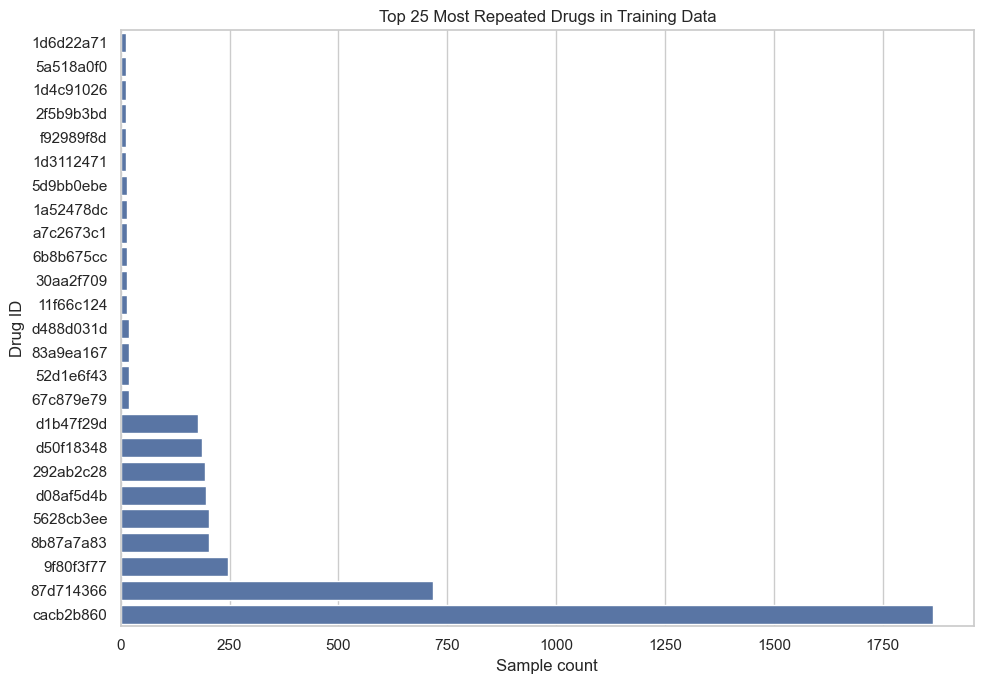

In [130]:
top_repeated_drugs = drug_frequency_summary.head(25).copy()

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_repeated_drugs.sort_values("sample_count", ascending=True),
    x="sample_count",
    y="drug_id"
)

plt.title("Top 25 Most Repeated Drugs in Training Data")
plt.xlabel("Sample count")
plt.ylabel("Drug ID")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_6_1_top_repeated_drugs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [131]:
drug_repeat_risk_table = pd.DataFrame({
    "finding": [
        "Some drugs are repeated across many samples",
        "The most repeated drug is likely linked to control structure",
        "Repeated drugs can affect validation reliability",
        "drug_id should not be used as a baseline model feature",
        "drug_id remains useful for validation-risk analysis"
    ],
    "why_it_matters": [
        "Random splits may place the same drug in both train and validation data",
        "Control rows have structural zero-target behavior",
        "Validation may become over-optimistic if drug identity is indirectly memorized",
        "drug_id is not part of the standard test feature table",
        "It helps evaluate whether drug-aware validation should be tested later"
    ],
    "decision": [
        "Check repeated-drug distribution",
        "Treat control behavior separately at inference",
        "Consider drug-aware validation as an advanced robustness check",
        "Exclude drug_id from baseline input features",
        "Use drug_id only for validation diagnostics"
    ]
})

drug_repeat_risk_table

,finding,why_it_matters,decision
0,Some drugs are repeated across many samples,Random splits may place the same drug in both ...,Check repeated-drug distribution
1,The most repeated drug is likely linked to con...,Control rows have structural zero-target behavior,Treat control behavior separately at inference
2,Repeated drugs can affect validation reliability,Validation may become over-optimistic if drug ...,Consider drug-aware validation as an advanced ...
3,drug_id should not be used as a baseline model...,drug_id is not part of the standard test featu...,Exclude drug_id from baseline input features
4,drug_id remains useful for validation-risk ana...,It helps evaluate whether drug-aware validatio...,Use drug_id only for validation diagnostics


#### 6.2 Random Split / Drug Overlap Risk

This subsection checks whether a random validation split may place the same `drug_id` in both training and validation folds.

If the same drug appears in both train and validation data, validation performance may become optimistic because the model may indirectly learn drug-specific patterns.

This does not mean random validation is unusable.  
It means drug-aware validation should be considered as an advanced robustness check.

In [132]:
from sklearn.model_selection import KFold

random_split_drug_df = drug_analysis_df[[ID_COL, "drug_id", "cp_type", "active_target_count"]].copy()

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_fold_overlap_records = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(random_split_drug_df), start=1):
    fold_train = random_split_drug_df.iloc[train_idx].copy()
    fold_valid = random_split_drug_df.iloc[valid_idx].copy()
    
    train_drugs = set(fold_train["drug_id"].dropna())
    valid_drugs = set(fold_valid["drug_id"].dropna())
    
    overlapping_drugs = train_drugs.intersection(valid_drugs)
    unseen_valid_drugs = valid_drugs.difference(train_drugs)
    
    fold_valid["drug_seen_in_train"] = fold_valid["drug_id"].isin(train_drugs)
    
    random_fold_overlap_records.append({
        "fold": fold,
        "train_samples": len(fold_train),
        "valid_samples": len(fold_valid),
        "train_unique_drugs": fold_train["drug_id"].nunique(),
        "valid_unique_drugs": fold_valid["drug_id"].nunique(),
        "overlapping_unique_drugs": len(overlapping_drugs),
        "unseen_valid_unique_drugs": len(unseen_valid_drugs),
        "valid_unique_drug_overlap_pct": len(overlapping_drugs) / max(len(valid_drugs), 1) * 100,
        "valid_samples_with_seen_drug": int(fold_valid["drug_seen_in_train"].sum()),
        "valid_samples_with_seen_drug_pct": fold_valid["drug_seen_in_train"].mean() * 100,
        "valid_samples_with_unseen_drug": int((~fold_valid["drug_seen_in_train"]).sum()),
        "valid_samples_with_unseen_drug_pct": (~fold_valid["drug_seen_in_train"]).mean() * 100,
        "valid_mean_active_target_count": fold_valid["active_target_count"].mean()
    })

random_fold_drug_overlap_summary = pd.DataFrame(random_fold_overlap_records)

random_fold_drug_overlap_summary

,fold,train_samples,valid_samples,train_unique_drugs,valid_unique_drugs,overlapping_unique_drugs,unseen_valid_unique_drugs,valid_unique_drug_overlap_pct,valid_samples_with_seen_drug,valid_samples_with_seen_drug_pct,valid_samples_with_unseen_drug,valid_samples_with_unseen_drug_pct,valid_mean_active_target_count
0,1,19051,4763,3269,2371,2351,20,99.156474,4743,99.580097,20,0.419903,0.720764
1,2,19051,4763,3263,2382,2356,26,98.908480,4737,99.454126,26,0.545874,0.702498
2,3,19051,4763,3259,2392,2362,30,98.745819,4733,99.370145,30,0.629855,0.707957
3,4,19051,4763,3262,2357,2330,27,98.854476,4736,99.433130,27,0.566870,0.708167
4,5,19052,4762,3263,2379,2353,26,98.907104,4736,99.454011,26,0.545989,0.697186


In [133]:
random_split_risk_overview = pd.DataFrame({
    "metric": [
        "mean valid unique drug overlap percentage",
        "max valid unique drug overlap percentage",
        "mean valid samples with seen drug percentage",
        "max valid samples with seen drug percentage",
        "mean valid samples with unseen drug percentage",
        "mean unseen valid unique drugs per fold"
    ],
    "value": [
        random_fold_drug_overlap_summary["valid_unique_drug_overlap_pct"].mean(),
        random_fold_drug_overlap_summary["valid_unique_drug_overlap_pct"].max(),
        random_fold_drug_overlap_summary["valid_samples_with_seen_drug_pct"].mean(),
        random_fold_drug_overlap_summary["valid_samples_with_seen_drug_pct"].max(),
        random_fold_drug_overlap_summary["valid_samples_with_unseen_drug_pct"].mean(),
        random_fold_drug_overlap_summary["unseen_valid_unique_drugs"].mean()
    ]
})

random_split_risk_overview

,metric,value
0,mean valid unique drug overlap percentage,98.914471
1,max valid unique drug overlap percentage,99.156474
2,mean valid samples with seen drug percentage,99.458302
3,max valid samples with seen drug percentage,99.580097
4,mean valid samples with unseen drug percentage,0.541698
5,mean unseen valid unique drugs per fold,25.800000


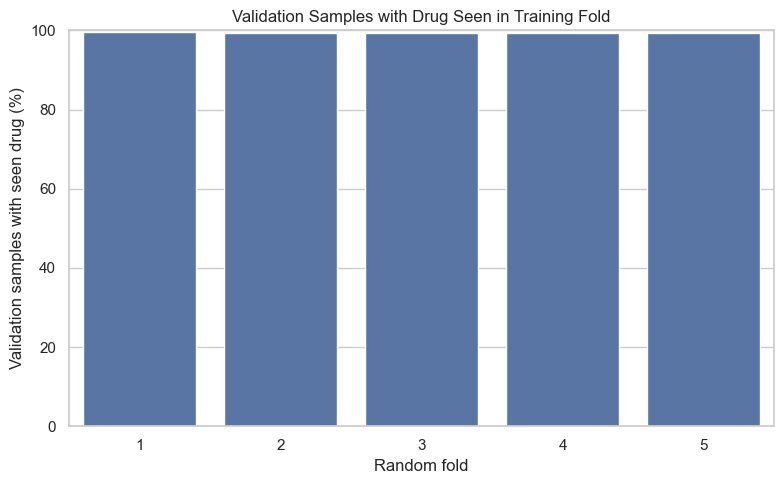

In [134]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=random_fold_drug_overlap_summary,
    x="fold",
    y="valid_samples_with_seen_drug_pct"
)

plt.title("Validation Samples with Drug Seen in Training Fold")
plt.xlabel("Random fold")
plt.ylabel("Validation samples with seen drug (%)")
plt.ylim(0, 100)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_6_2_random_fold_drug_overlap_pct.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [135]:
example_fold = 1

train_idx, valid_idx = list(kf.split(random_split_drug_df))[example_fold - 1]

example_train = random_split_drug_df.iloc[train_idx].copy()
example_valid = random_split_drug_df.iloc[valid_idx].copy()

example_train_drugs = set(example_train["drug_id"].dropna())
example_valid["drug_seen_in_train"] = example_valid["drug_id"].isin(example_train_drugs)

example_overlapping_drug_summary = (
    example_valid[example_valid["drug_seen_in_train"]]
    .groupby("drug_id")
    .agg(
        validation_sample_count=(ID_COL, "count"),
        validation_treated_count=("cp_type", lambda x: (x == "trt_cp").sum()),
        validation_control_count=("cp_type", lambda x: (x == "ctl_vehicle").sum()),
        validation_mean_active_target_count=("active_target_count", "mean")
    )
    .reset_index()
    .sort_values("validation_sample_count", ascending=False)
)

example_overlapping_drug_summary.head(20)

,drug_id,validation_sample_count,validation_treated_count,validation_control_count,validation_mean_active_target_count
1811,cacb2b860,351,0,351,0.0
1198,87d714366,132,132,0,2.0
1407,9f80f3f77,50,50,0,1.0
1229,8b87a7a83,49,49,0,1.0
1923,d50f18348,45,45,0,3.0
1871,d08af5d4b,43,43,0,1.0
758,5628cb3ee,38,38,0,1.0
371,292ab2c28,38,38,0,0.0
1880,d1b47f29d,29,29,0,1.0
852,61155e673,7,7,0,1.0


In [137]:
random_split_drug_risk_decision_table = pd.DataFrame({
    "finding": [
        "Random folds may contain the same drug in train and validation",
        "Validation samples may include drugs already seen in the training fold",
        "Repeated drugs can make validation performance optimistic",
        "drug_id should not be used as a baseline feature",
        "Drug-aware validation may be useful as an advanced check"
    ],
    "interpretation": [
        "The split is sample-random, not drug-group-aware",
        "The validation fold may not fully represent unseen-drug generalization",
        "The model may indirectly learn repeated-drug patterns through biological features",
        "drug_id is not available as a standard input feature for test prediction",
        "A group-based validation check can test robustness under harder conditions"
    ],
    "decision": [
        "Use random/multilabel-aware validation as baseline, but interpret carefully",
        "Track drug overlap risk during validation design",
        "Do not rely on random split score alone",
        "Exclude drug_id from baseline input features",
        "Consider GroupKFold or drug-aware validation as an advanced experiment"
    ]
})

random_split_drug_risk_decision_table

,finding,interpretation,decision
0,Random folds may contain the same drug in trai...,"The split is sample-random, not drug-group-aware",Use random/multilabel-aware validation as base...
1,Validation samples may include drugs already s...,The validation fold may not fully represent un...,Track drug overlap risk during validation design
2,Repeated drugs can make validation performance...,The model may indirectly learn repeated-drug p...,Do not rely on random split score alone
3,drug_id should not be used as a baseline feature,drug_id is not available as a standard input f...,Exclude drug_id from baseline input features
4,Drug-aware validation may be useful as an adva...,A group-based validation check can test robust...,Consider GroupKFold or drug-aware validation a...


In [138]:
section_6_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
section_6_output_dir.mkdir(parents=True, exist_ok=True)

random_fold_drug_overlap_summary.to_csv(
    section_6_output_dir / "section_6_2_random_fold_drug_overlap_summary.csv",
    index=False
)

random_split_risk_overview.to_csv(
    section_6_output_dir / "section_6_2_random_split_risk_overview.csv",
    index=False
)

example_overlapping_drug_summary.to_csv(
    section_6_output_dir / "section_6_2_example_overlapping_drug_summary.csv",
    index=False
)

random_split_drug_risk_decision_table.to_csv(
    section_6_output_dir / "section_6_2_random_split_drug_risk_decision_table.csv",
    index=False
)

print("Section 6.2 random split drug-overlap risk outputs saved successfully.")

Section 6.2 random split drug-overlap risk outputs saved successfully.


#### 6.2.5 Random Split / Drug Overlap Decision

The random K-Fold drug-overlap check shows a very high overlap between training and validation folds.

Across random folds, around 99% of validation samples come from drugs that are already present in the corresponding training fold. This means that a random sample-level split does not strongly test unseen-drug generalization.

This does not make random validation useless, but it means random validation scores should be interpreted carefully. The model may partially benefit from repeated-drug biological patterns appearing in both train and validation data.

Therefore, the baseline can still use random or multi-label-aware validation, but final model evaluation should also consider a harder drug-aware validation experiment.

Main decisions:

* do not use `drug_id` as a baseline input feature;
* do not rely only on random split validation score;
* use random or multi-label-aware validation as the baseline validation setup;
* consider `GroupKFold` or drug-aware validation as an advanced robustness check;
* use `drug_id` only for validation-risk diagnostics, not as a normal model input.


#### 6.3 Rare-Label Fold Risk

This subsection checks whether rare scored targets may create validation instability.

The MoA target matrix is highly sparse, and many targets have very few positive samples. If a target has very few positives, random validation folds may contain zero or very low positive samples for that target.

The goal here is only to measure fold-level label coverage risk.
No validation decision is made in this subsection yet.


In [139]:
def assign_target_frequency_band(positive_count):
    if positive_count == 0:
        return "zero positive"
    elif positive_count < 10:
        return "very rare: 1-9"
    elif positive_count < 50:
        return "rare: 10-49"
    elif positive_count < 200:
        return "medium: 50-199"
    else:
        return "frequent: >=200"


target_frequency_risk_table = pd.DataFrame({
    "target": scored_target_features,
    "positive_count": y_scored_matrix[scored_target_features].sum(axis=0).astype(int).values
})

target_frequency_risk_table["positive_percentage"] = (
    target_frequency_risk_table["positive_count"] / len(y_scored_matrix) * 100
)

target_frequency_risk_table["risk_band"] = target_frequency_risk_table["positive_count"].apply(
    assign_target_frequency_band
)

target_frequency_risk_table["expected_positive_per_fold_5fold"] = (
    target_frequency_risk_table["positive_count"] / 5
)

target_frequency_risk_table = target_frequency_risk_table.sort_values(
    "positive_count",
    ascending=True
).reset_index(drop=True)

target_frequency_risk_table.head(20)

,target,positive_count,positive_percentage,risk_band,expected_positive_per_fold_5fold
0,atp-sensitive_potassium_channel_antagonist,1,0.004199,very rare: 1-9,0.2
1,erbb2_inhibitor,1,0.004199,very rare: 1-9,0.2
2,atm_kinase_inhibitor,6,0.025195,very rare: 1-9,1.2
3,antiarrhythmic,6,0.025195,very rare: 1-9,1.2
4,calcineurin_inhibitor,6,0.025195,very rare: 1-9,1.2
5,elastase_inhibitor,6,0.025195,very rare: 1-9,1.2
6,coagulation_factor_inhibitor,6,0.025195,very rare: 1-9,1.2
7,autotaxin_inhibitor,6,0.025195,very rare: 1-9,1.2
8,diuretic,6,0.025195,very rare: 1-9,1.2
9,lxr_agonist,6,0.025195,very rare: 1-9,1.2


In [140]:
risk_band_order = [
    "zero positive",
    "very rare: 1-9",
    "rare: 10-49",
    "medium: 50-199",
    "frequent: >=200"
]

target_risk_band_summary = (
    target_frequency_risk_table
    .groupby("risk_band")
    .agg(
        target_count=("target", "count"),
        total_positive_labels=("positive_count", "sum"),
        median_positive_count=("positive_count", "median"),
        min_positive_count=("positive_count", "min"),
        max_positive_count=("positive_count", "max")
    )
    .reindex(risk_band_order)
    .reset_index()
)

target_risk_band_summary["target_percentage"] = (
    target_risk_band_summary["target_count"] / len(scored_target_features) * 100
)

target_risk_band_summary

,risk_band,target_count,total_positive_labels,median_positive_count,min_positive_count,max_positive_count,target_percentage
0,zero positive,NaN,NaN,NaN,NaN,NaN,NaN
1,very rare: 1-9,22.0,126.0,6.0,1.0,7.0,10.679612
2,rare: 10-49,97.0,2747.0,26.0,12.0,49.0,47.087379
3,medium: 50-199,63.0,5548.0,74.0,50.0,192.0,30.582524
4,frequent: >=200,24.0,8423.0,299.0,223.0,832.0,11.650485


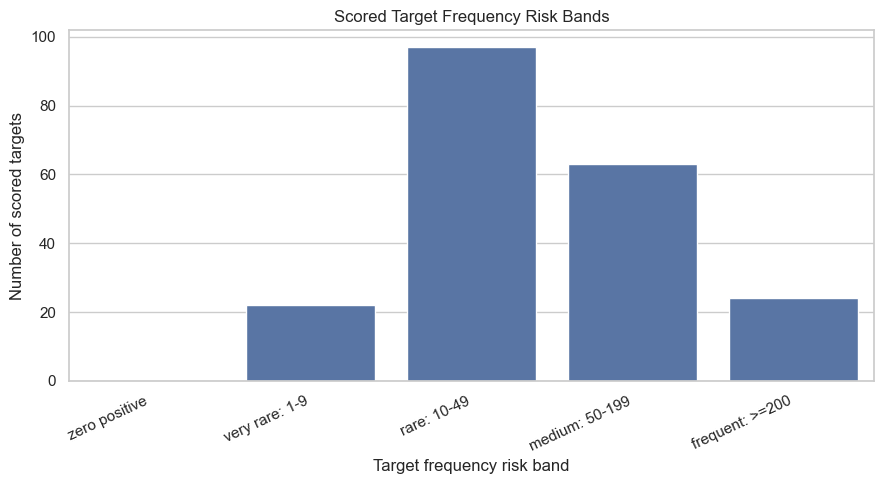

In [141]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=target_risk_band_summary,
    x="risk_band",
    y="target_count",
    order=risk_band_order
)

plt.title("Scored Target Frequency Risk Bands")
plt.xlabel("Target frequency risk band")
plt.ylabel("Number of scored targets")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_6_3_target_risk_band_counts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 6.3.3 Random K-Fold Label Coverage

Now we simulate a 5-fold random split and count how many positives each scored target receives in each validation fold.

This helps identify labels that may become zero-positive or very low-positive inside validation folds.

In [142]:
from sklearn.model_selection import KFold

label_fold_kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_label_positive_records = []
fold_level_label_risk_records = []

for fold, train_idx, valid_idx in [
    (fold_id, train_idx, valid_idx)
    for fold_id, (train_idx, valid_idx) in enumerate(label_fold_kf.split(y_scored_matrix), start=1)
]:
    valid_targets = y_scored_matrix.iloc[valid_idx][scored_target_features]
    valid_positive_counts = valid_targets.sum(axis=0).astype(int)
    
    for target_name, positive_count in valid_positive_counts.items():
        fold_label_positive_records.append({
            "fold": fold,
            "target": target_name,
            "validation_positive_count": int(positive_count)
        })
    
    fold_level_label_risk_records.append({
        "fold": fold,
        "validation_samples": len(valid_idx),
        "total_validation_positive_labels": int(valid_targets.values.sum()),
        "mean_active_targets_per_validation_sample": valid_targets.sum(axis=1).mean(),
        "zero_positive_targets": int((valid_positive_counts == 0).sum()),
        "one_positive_targets": int((valid_positive_counts == 1).sum()),
        "two_positive_targets": int((valid_positive_counts == 2).sum()),
        "low_positive_targets_less_than_5": int((valid_positive_counts < 5).sum()),
        "low_positive_targets_less_than_10": int((valid_positive_counts < 10).sum())
    })

random_fold_label_positive_counts = pd.DataFrame(fold_label_positive_records)
fold_level_label_risk_summary = pd.DataFrame(fold_level_label_risk_records)

fold_level_label_risk_summary

,fold,validation_samples,total_validation_positive_labels,mean_active_targets_per_validation_sample,zero_positive_targets,one_positive_targets,two_positive_targets,low_positive_targets_less_than_5,low_positive_targets_less_than_10
0,1,4763,3433,0.720764,6,12,12,61,113
1,2,4763,3346,0.702498,7,18,11,62,111
2,3,4763,3372,0.707957,7,12,14,63,114
3,4,4763,3373,0.708167,10,13,10,62,120
4,5,4762,3320,0.697186,11,10,13,59,112


In [143]:
random_fold_label_positive_pivot = (
    random_fold_label_positive_counts
    .pivot(index="target", columns="fold", values="validation_positive_count")
    .reset_index()
)

random_fold_label_positive_pivot.columns = [
    "target" if col == "target" else f"fold_{col}_positive_count"
    for col in random_fold_label_positive_pivot.columns
]

random_fold_label_positive_pivot = (
    target_frequency_risk_table[["target", "positive_count", "risk_band"]]
    .merge(random_fold_label_positive_pivot, on="target", how="left")
    .sort_values("positive_count", ascending=True)
    .reset_index(drop=True)
)

random_fold_label_positive_pivot.head(20)

,target,positive_count,risk_band,fold_1_positive_count,fold_2_positive_count,fold_3_positive_count,fold_4_positive_count,fold_5_positive_count
0,atp-sensitive_potassium_channel_antagonist,1,very rare: 1-9,1,0,0,0,0
1,erbb2_inhibitor,1,very rare: 1-9,0,1,0,0,0
2,atm_kinase_inhibitor,6,very rare: 1-9,1,1,2,1,1
3,antiarrhythmic,6,very rare: 1-9,1,1,2,1,1
4,calcineurin_inhibitor,6,very rare: 1-9,1,1,3,1,0
5,elastase_inhibitor,6,very rare: 1-9,2,0,0,3,1
6,coagulation_factor_inhibitor,6,very rare: 1-9,3,1,2,0,0
7,autotaxin_inhibitor,6,very rare: 1-9,1,1,2,2,0
8,diuretic,6,very rare: 1-9,2,2,0,2,0
9,lxr_agonist,6,very rare: 1-9,1,2,0,1,2


In [144]:
fold_count_columns = [
    col for col in random_fold_label_positive_pivot.columns
    if col.startswith("fold_") and col.endswith("_positive_count")
]

random_fold_label_positive_pivot["zero_positive_fold_count"] = (
    random_fold_label_positive_pivot[fold_count_columns] == 0
).sum(axis=1)

random_fold_label_positive_pivot["min_validation_positive_count"] = (
    random_fold_label_positive_pivot[fold_count_columns].min(axis=1)
)

random_fold_label_positive_pivot["max_validation_positive_count"] = (
    random_fold_label_positive_pivot[fold_count_columns].max(axis=1)
)

random_fold_label_positive_pivot["mean_validation_positive_count"] = (
    random_fold_label_positive_pivot[fold_count_columns].mean(axis=1)
)

random_fold_label_zero_positive_summary = (
    random_fold_label_positive_pivot
    .sort_values(
        ["zero_positive_fold_count", "positive_count"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

random_fold_label_zero_positive_summary.head(30)

,target,positive_count,risk_band,fold_1_positive_count,fold_2_positive_count,fold_3_positive_count,fold_4_positive_count,fold_5_positive_count,zero_positive_fold_count,min_validation_positive_count,max_validation_positive_count,mean_validation_positive_count
0,atp-sensitive_potassium_channel_antagonist,1,very rare: 1-9,1,0,0,0,0,4,0,1,0.2
1,erbb2_inhibitor,1,very rare: 1-9,0,1,0,0,0,4,0,1,0.2
2,elastase_inhibitor,6,very rare: 1-9,2,0,0,3,1,2,0,3,1.2
3,coagulation_factor_inhibitor,6,very rare: 1-9,3,1,2,0,0,2,0,3,1.2
4,diuretic,6,very rare: 1-9,2,2,0,2,0,2,0,2,1.2
5,retinoid_receptor_antagonist,6,very rare: 1-9,0,3,2,0,1,2,0,3,1.2
6,nicotinic_receptor_agonist,6,very rare: 1-9,1,0,3,2,0,2,0,3,1.2
7,tropomyosin_receptor_kinase_inhibitor,6,very rare: 1-9,0,3,1,0,2,2,0,3,1.2
8,ubiquitin_specific_protease_inhibitor,6,very rare: 1-9,0,3,1,0,2,2,0,3,1.2
9,norepinephrine_reuptake_inhibitor,7,very rare: 1-9,2,0,2,0,3,2,0,3,1.4


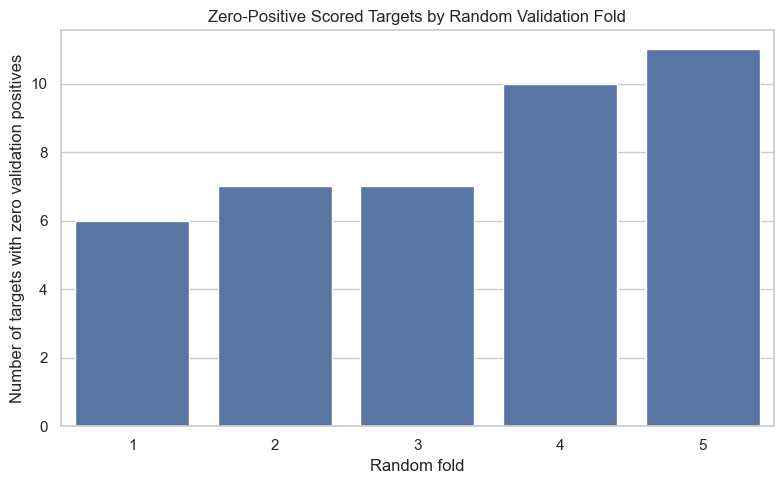

In [145]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=fold_level_label_risk_summary,
    x="fold",
    y="zero_positive_targets"
)

plt.title("Zero-Positive Scored Targets by Random Validation Fold")
plt.xlabel("Random fold")
plt.ylabel("Number of targets with zero validation positives")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "section_6_3_zero_positive_targets_by_fold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [146]:
rare_target_monitoring_list = (
    random_fold_label_zero_positive_summary[
        (random_fold_label_zero_positive_summary["positive_count"] < 50)
        | (random_fold_label_zero_positive_summary["zero_positive_fold_count"] > 0)
    ]
    .copy()
)

rare_target_monitoring_list = rare_target_monitoring_list.sort_values(
    ["positive_count", "zero_positive_fold_count"],
    ascending=[True, False]
).reset_index(drop=True)

rare_target_monitoring_list.head(30)

,target,positive_count,risk_band,fold_1_positive_count,fold_2_positive_count,fold_3_positive_count,fold_4_positive_count,fold_5_positive_count,zero_positive_fold_count,min_validation_positive_count,max_validation_positive_count,mean_validation_positive_count
0,atp-sensitive_potassium_channel_antagonist,1,very rare: 1-9,1,0,0,0,0,4,0,1,0.2
1,erbb2_inhibitor,1,very rare: 1-9,0,1,0,0,0,4,0,1,0.2
2,elastase_inhibitor,6,very rare: 1-9,2,0,0,3,1,2,0,3,1.2
3,coagulation_factor_inhibitor,6,very rare: 1-9,3,1,2,0,0,2,0,3,1.2
4,diuretic,6,very rare: 1-9,2,2,0,2,0,2,0,2,1.2
5,retinoid_receptor_antagonist,6,very rare: 1-9,0,3,2,0,1,2,0,3,1.2
6,nicotinic_receptor_agonist,6,very rare: 1-9,1,0,3,2,0,2,0,3,1.2
7,tropomyosin_receptor_kinase_inhibitor,6,very rare: 1-9,0,3,1,0,2,2,0,3,1.2
8,ubiquitin_specific_protease_inhibitor,6,very rare: 1-9,0,3,1,0,2,2,0,3,1.2
9,calcineurin_inhibitor,6,very rare: 1-9,1,1,3,1,0,1,0,3,1.2


In [147]:
section_6_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
section_6_output_dir.mkdir(parents=True, exist_ok=True)

target_frequency_risk_table.to_csv(
    section_6_output_dir / "section_6_3_target_frequency_risk_table.csv",
    index=False
)

target_risk_band_summary.to_csv(
    section_6_output_dir / "section_6_3_target_risk_band_summary.csv",
    index=False
)

random_fold_label_positive_counts.to_csv(
    section_6_output_dir / "section_6_3_random_fold_label_positive_counts.csv",
    index=False
)

random_fold_label_positive_pivot.to_csv(
    section_6_output_dir / "section_6_3_random_fold_label_positive_pivot.csv",
    index=False
)

random_fold_label_zero_positive_summary.to_csv(
    section_6_output_dir / "section_6_3_random_fold_label_zero_positive_summary.csv",
    index=False
)

fold_level_label_risk_summary.to_csv(
    section_6_output_dir / "section_6_3_fold_level_label_risk_summary.csv",
    index=False
)

rare_target_monitoring_list.to_csv(
    section_6_output_dir / "section_6_3_rare_target_monitoring_list.csv",
    index=False
)

print("Section 6.3 rare-label fold risk outputs saved successfully.")

Section 6.3 rare-label fold risk outputs saved successfully.


#### 6.3.8 Rare-Label Fold Risk Decision

The rare-label fold-risk check shows that validation instability is a real concern for the scored target matrix.

There are no zero-positive scored targets overall, but many targets are rare. Among the 206 scored targets, 22 targets have only 1–9 positive samples, and 97 targets have 10–49 positive samples. This means that more than half of the scored targets have fewer than 50 positive examples.

In the simulated random 5-fold split, each validation fold contains several targets with zero positive samples. The number of zero-positive targets ranges from 6 to 11 across folds. Also, more than 100 targets in each fold have fewer than 10 positive validation samples.

This means random validation can give unstable target-wise evaluation for rare mechanisms. The overall score can still be useful, but rare-label performance should be interpreted carefully.

Main decisions:

* do not remove rare targets from the target matrix;
* do not rely only on aggregate validation score;
* monitor rare-label performance separately during modeling;
* use a validation strategy that tries to preserve multi-label target coverage;
* treat very rare labels as high-risk targets during model evaluation;
* final validation design should consider multi-label-aware splitting rather than plain random splitting alone.


In [148]:
rare_label_fold_risk_decision_table = pd.DataFrame({
    "finding": [
        "No scored target has zero positives overall",
        "Many scored targets are rare",
        "Very rare targets are difficult to evaluate fold-wise",
        "Random folds contain zero-positive targets",
        "Many targets have very low validation positives per fold",
        "Aggregate validation score may hide rare-label instability"
    ],
    "evidence": [
        "All 206 scored targets have at least one positive sample",
        "22 targets have 1-9 positives and 97 targets have 10-49 positives",
        "Targets with 1-9 positives cannot be reliably represented in every 5-fold validation fold",
        "Random folds show about 6 to 11 zero-positive targets per validation fold",
        "Each fold has more than 100 targets with fewer than 10 positive validation samples",
        "Frequent targets can dominate the overall validation signal"
    ],
    "decision": [
        "Keep all scored targets",
        "Create rare-target monitoring during modeling",
        "Interpret very rare target metrics carefully",
        "Avoid relying only on plain random split behavior",
        "Prefer multi-label-aware validation when possible",
        "Report both overall validation score and rare-label risk observations"
    ]
})

rare_label_fold_risk_decision_table

,finding,evidence,decision
0,No scored target has zero positives overall,All 206 scored targets have at least one posit...,Keep all scored targets
1,Many scored targets are rare,22 targets have 1-9 positives and 97 targets h...,Create rare-target monitoring during modeling
2,Very rare targets are difficult to evaluate fo...,Targets with 1-9 positives cannot be reliably ...,Interpret very rare target metrics carefully
3,Random folds contain zero-positive targets,Random folds show about 6 to 11 zero-positive ...,Avoid relying only on plain random split behavior
4,Many targets have very low validation positive...,Each fold has more than 100 targets with fewer...,Prefer multi-label-aware validation when possible
5,Aggregate validation score may hide rare-label...,Frequent targets can dominate the overall vali...,Report both overall validation score and rare-...


In [149]:
section_6_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
section_6_output_dir.mkdir(parents=True, exist_ok=True)

rare_label_fold_risk_decision_table.to_csv(
    section_6_output_dir / "section_6_3_rare_label_fold_risk_decision_table.csv",
    index=False
)

print("Section 6.3 rare-label fold-risk decision table saved successfully.")

Section 6.3 rare-label fold-risk decision table saved successfully.


#### 6.4 Leakage-Sensitive Transformation Checklist

This subsection lists transformations and feature-engineering steps that may create leakage if implemented incorrectly.

No model is trained here.  
The goal is to create implementation guardrails for the feature engineering and modeling notebooks.

In [150]:
transformation_risk_inventory = pd.DataFrame({
    "transformation_or_step": [
        "Raw gene/cell summary features",
        "Gene-cell interaction features",
        "Metadata encoding",
        "StandardScaler / RobustScaler / MinMaxScaler",
        "PCA / dimensionality reduction",
        "Feature selection by variance",
        "Feature selection by target relationship",
        "Response-level quantile thresholds",
        "Outlier thresholds",
        "Target-derived features",
        "Nonscored targets as auxiliary outputs",
        "Nonscored targets as input features",
        "Control-row zero prediction rule"
    ],
    "risk_level": [
        "low",
        "low",
        "low",
        "medium",
        "high",
        "medium",
        "high",
        "high",
        "high",
        "forbidden",
        "advanced-safe",
        "forbidden",
        "safe-at-inference"
    ],
    "why_it_can_be_risky": [
        "Uses only row-level input values",
        "Uses only row-level input values",
        "Uses experimental metadata only",
        "Learns distribution statistics such as mean, median, or scale",
        "Learns global directions of variation from data",
        "Learns which features vary across the dataset",
        "Uses target information to choose features",
        "Learns cutoffs from data distribution",
        "Learns cutoffs from data distribution",
        "Directly leaks label information",
        "Can help only as extra supervised outputs",
        "Would leak unavailable target-side information",
        "Uses known structural behavior of control rows"
    ],
    "safe_implementation_rule": [
        "Can be created in feature engineering from input features",
        "Can be created in feature engineering from input features",
        "Can be encoded in preprocessing",
        "Fit only on training fold inside CV pipeline",
        "Fit only on training fold inside CV pipeline",
        "Fit only on training fold inside CV pipeline",
        "Use only inside nested/CV-safe feature selection",
        "Learn thresholds only on training fold",
        "Learn thresholds only on training fold",
        "Never use as model input",
        "Use only as auxiliary output in advanced models",
        "Never use as model input",
        "Apply only during inference/submission stage"
    ]
})

transformation_risk_inventory

,transformation_or_step,risk_level,why_it_can_be_risky,safe_implementation_rule
0,Raw gene/cell summary features,low,Uses only row-level input values,Can be created in feature engineering from inp...
1,Gene-cell interaction features,low,Uses only row-level input values,Can be created in feature engineering from inp...
2,Metadata encoding,low,Uses experimental metadata only,Can be encoded in preprocessing
3,StandardScaler / RobustScaler / MinMaxScaler,medium,"Learns distribution statistics such as mean, m...",Fit only on training fold inside CV pipeline
4,PCA / dimensionality reduction,high,Learns global directions of variation from data,Fit only on training fold inside CV pipeline
5,Feature selection by variance,medium,Learns which features vary across the dataset,Fit only on training fold inside CV pipeline
6,Feature selection by target relationship,high,Uses target information to choose features,Use only inside nested/CV-safe feature selection
7,Response-level quantile thresholds,high,Learns cutoffs from data distribution,Learn thresholds only on training fold
8,Outlier thresholds,high,Learns cutoffs from data distribution,Learn thresholds only on training fold
9,Target-derived features,forbidden,Directly leaks label information,Never use as model input


In [151]:
safe_vs_pipeline_feature_rules = pd.DataFrame({
    "feature_or_method": [
        "gene_mean",
        "gene_std",
        "gene_abs_mean",
        "gene_min",
        "gene_max",
        "cell_mean",
        "cell_std",
        "cell_abs_mean",
        "cell_min",
        "cell_max",
        "cell_range",
        "gene_cell_abs_mean_product",
        "gene_minus_cell_abs_mean",
        "gene_to_cell_abs_mean_ratio",
        "one-hot metadata encoding",
        "scaling",
        "PCA features",
        "high-response flags",
        "response-level bins",
        "outlier flags",
        "feature selection",
        "target activity count",
        "scored target frequency features",
        "nonscored target values as input"
    ],
    "implementation_category": [
        "safe row-wise feature",
        "safe row-wise feature",
        "safe row-wise feature",
        "safe row-wise feature",
        "safe row-wise feature",
        "safe row-wise feature",
        "safe row-wise feature",
        "safe row-wise feature",
        "safe row-wise feature",
        "safe row-wise feature",
        "safe row-wise feature",
        "safe row-wise feature",
        "safe row-wise feature",
        "safe row-wise feature",
        "safe preprocessing",
        "pipeline-only",
        "pipeline-only",
        "pipeline-only",
        "pipeline-only",
        "pipeline-only",
        "pipeline-only",
        "forbidden",
        "forbidden",
        "forbidden"
    ],
    "reason": [
        "Calculated from the same sample's gene values",
        "Calculated from the same sample's gene values",
        "Calculated from the same sample's gene values",
        "Calculated from the same sample's gene values",
        "Calculated from the same sample's gene values",
        "Calculated from the same sample's cell values",
        "Calculated from the same sample's cell values",
        "Calculated from the same sample's cell values",
        "Calculated from the same sample's cell values",
        "Calculated from the same sample's cell values",
        "Calculated from the same sample's cell values",
        "Uses only input-derived gene/cell summaries",
        "Uses only input-derived gene/cell summaries",
        "Uses only input-derived gene/cell summaries",
        "Uses metadata available in train and test",
        "Learns distribution scale",
        "Learns representation directions",
        "Requires learned thresholds",
        "Requires learned quantile cutoffs",
        "Requires learned cutoffs",
        "May learn from validation/target information",
        "Uses target labels",
        "Uses target label distribution",
        "Uses target-side auxiliary labels"
    ],
    "where_to_implement": [
        "03_feature_engineering.ipynb",
        "03_feature_engineering.ipynb",
        "03_feature_engineering.ipynb",
        "03_feature_engineering.ipynb",
        "03_feature_engineering.ipynb",
        "03_feature_engineering.ipynb",
        "03_feature_engineering.ipynb",
        "03_feature_engineering.ipynb",
        "03_feature_engineering.ipynb",
        "03_feature_engineering.ipynb",
        "03_feature_engineering.ipynb",
        "03_feature_engineering.ipynb",
        "03_feature_engineering.ipynb",
        "03_feature_engineering.ipynb",
        "preprocessing/model pipeline",
        "model pipeline only",
        "model pipeline only",
        "model pipeline only",
        "model pipeline only",
        "model pipeline only",
        "model pipeline only",
        "do not implement",
        "do not implement",
        "do not implement"
    ]
})

safe_vs_pipeline_feature_rules

,feature_or_method,implementation_category,reason,where_to_implement
0,gene_mean,safe row-wise feature,Calculated from the same sample's gene values,03_feature_engineering.ipynb
1,gene_std,safe row-wise feature,Calculated from the same sample's gene values,03_feature_engineering.ipynb
2,gene_abs_mean,safe row-wise feature,Calculated from the same sample's gene values,03_feature_engineering.ipynb
3,gene_min,safe row-wise feature,Calculated from the same sample's gene values,03_feature_engineering.ipynb
4,gene_max,safe row-wise feature,Calculated from the same sample's gene values,03_feature_engineering.ipynb
5,cell_mean,safe row-wise feature,Calculated from the same sample's cell values,03_feature_engineering.ipynb
6,cell_std,safe row-wise feature,Calculated from the same sample's cell values,03_feature_engineering.ipynb
7,cell_abs_mean,safe row-wise feature,Calculated from the same sample's cell values,03_feature_engineering.ipynb
8,cell_min,safe row-wise feature,Calculated from the same sample's cell values,03_feature_engineering.ipynb
9,cell_max,safe row-wise feature,Calculated from the same sample's cell values,03_feature_engineering.ipynb


In [152]:
target_leakage_guardrails = pd.DataFrame({
    "not_allowed_as_model_input": [
        "active_target_count",
        "zero_label_flag",
        "multi_label_count",
        "any scored target column",
        "any scored target summary",
        "any nonscored target column",
        "nonscored active target count",
        "fold-level target frequency",
        "validation positive count per target",
        "target co-occurrence features"
    ],
    "why_not_allowed": [
        "Directly uses scored label information",
        "Derived from scored labels",
        "Derived from scored labels",
        "This is the prediction target",
        "Derived from the prediction target",
        "Auxiliary target labels are not input features",
        "Derived from nonscored target labels",
        "Uses validation/fold target information",
        "Uses validation label distribution",
        "Uses target-label relationships"
    ],
    "safe_alternative": [
        "Use gene/cell summary features instead",
        "Use input-derived response summaries instead",
        "Use input-derived response summaries instead",
        "Use only as y target",
        "Use only for EDA monitoring",
        "Use only as auxiliary output in advanced training",
        "Use only for EDA/auxiliary-label analysis",
        "Use only for validation diagnostics",
        "Use only for validation diagnostics",
        "Use only for EDA label-space analysis"
    ]
})

target_leakage_guardrails

,not_allowed_as_model_input,why_not_allowed,safe_alternative
0,active_target_count,Directly uses scored label information,Use gene/cell summary features instead
1,zero_label_flag,Derived from scored labels,Use input-derived response summaries instead
2,multi_label_count,Derived from scored labels,Use input-derived response summaries instead
3,any scored target column,This is the prediction target,Use only as y target
4,any scored target summary,Derived from the prediction target,Use only for EDA monitoring
5,any nonscored target column,Auxiliary target labels are not input features,Use only as auxiliary output in advanced training
6,nonscored active target count,Derived from nonscored target labels,Use only for EDA/auxiliary-label analysis
7,fold-level target frequency,Uses validation/fold target information,Use only for validation diagnostics
8,validation positive count per target,Uses validation label distribution,Use only for validation diagnostics
9,target co-occurrence features,Uses target-label relationships,Use only for EDA label-space analysis


In [153]:
pipeline_implementation_rules = pd.DataFrame({
    "pipeline_rule": [
        "Split before fitting any learned transformation",
        "Fit scaler only on training fold",
        "Fit PCA only on training fold",
        "Fit feature selector only on training fold",
        "Learn quantile thresholds only on training fold",
        "Transform validation fold using objects fitted on training fold",
        "Never fit preprocessing on train + validation together inside CV",
        "Never use test data to fit preprocessing",
        "Keep target-derived variables out of X",
        "Apply control-row zeroing only at inference/submission stage"
    ],
    "wrong_example": [
        "Fit scaler, then split",
        "Scaler.fit(full_training_data)",
        "PCA.fit(full_training_data)",
        "Select features using full y",
        "qcut/full-data quantile threshold before CV",
        "Fit separate scaler on validation fold",
        "Fit PCA using all CV data",
        "Scaler.fit(train + test)",
        "X includes active_target_count",
        "Change y labels during EDA"
    ],
    "correct_example": [
        "Split first, then fit inside fold",
        "Scaler.fit(X_train_fold)",
        "PCA.fit(X_train_fold)",
        "Selector.fit(X_train_fold, y_train_fold)",
        "Thresholds learned from X_train_fold only",
        "Validation transformed with training-fitted object",
        "Fit only on fold training data",
        "Use test only for final transform/prediction",
        "X uses only input features",
        "Post-process predictions for control rows"
    ]
})

pipeline_implementation_rules

,pipeline_rule,wrong_example,correct_example
0,Split before fitting any learned transformation,"Fit scaler, then split","Split first, then fit inside fold"
1,Fit scaler only on training fold,Scaler.fit(full_training_data),Scaler.fit(X_train_fold)
2,Fit PCA only on training fold,PCA.fit(full_training_data),PCA.fit(X_train_fold)
3,Fit feature selector only on training fold,Select features using full y,"Selector.fit(X_train_fold, y_train_fold)"
4,Learn quantile thresholds only on training fold,qcut/full-data quantile threshold before CV,Thresholds learned from X_train_fold only
5,Transform validation fold using objects fitted...,Fit separate scaler on validation fold,Validation transformed with training-fitted ob...
6,Never fit preprocessing on train + validation ...,Fit PCA using all CV data,Fit only on fold training data
7,Never use test data to fit preprocessing,Scaler.fit(train + test),Use test only for final transform/prediction
8,Keep target-derived variables out of X,X includes active_target_count,X uses only input features
9,Apply control-row zeroing only at inference/su...,Change y labels during EDA,Post-process predictions for control rows


In [154]:
section_6_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
section_6_output_dir.mkdir(parents=True, exist_ok=True)

transformation_risk_inventory.to_csv(
    section_6_output_dir / "section_6_4_transformation_risk_inventory.csv",
    index=False
)

safe_vs_pipeline_feature_rules.to_csv(
    section_6_output_dir / "section_6_4_safe_vs_pipeline_feature_rules.csv",
    index=False
)

target_leakage_guardrails.to_csv(
    section_6_output_dir / "section_6_4_target_leakage_guardrails.csv",
    index=False
)

pipeline_implementation_rules.to_csv(
    section_6_output_dir / "section_6_4_pipeline_implementation_rules.csv",
    index=False
)

print("Section 6.4 leakage-sensitive transformation checklist outputs saved successfully.")

Section 6.4 leakage-sensitive transformation checklist outputs saved successfully.


#### 6.4.7 Leakage-Sensitive Transformation Checklist Closing

The leakage-sensitive transformation checklist is complete.

The main rule is that row-wise input-derived features are safe to create in feature engineering, but any transformation that learns from the data distribution must be fitted only inside the validation or modeling pipeline.

Scaling, PCA, learned thresholds, outlier cutoffs, and feature selection should not be fitted on the full dataset before cross-validation. Target-derived variables must never be used as model inputs.

This checklist will guide the implementation of `03_feature_engineering.ipynb` and later modeling notebooks.


In [155]:
leakage_checklist_closing_table = pd.DataFrame({
    "area": [
        "Safe row-wise features",
        "Scaling",
        "PCA",
        "Threshold-based features",
        "Feature selection",
        "Target-derived variables",
        "Nonscored targets",
        "Control-row rule"
    ],
    "final_rule": [
        "Can be created from input gene/cell/metadata values",
        "Fit only inside CV/modeling pipeline",
        "Fit only inside CV/modeling pipeline",
        "Learn thresholds only from training folds",
        "Perform only inside validation-safe pipeline",
        "Never use as model input",
        "Use only as auxiliary outputs in advanced models, not inputs",
        "Apply only at inference/submission stage"
    ]
})

leakage_checklist_closing_table

,area,final_rule
0,Safe row-wise features,Can be created from input gene/cell/metadata v...
1,Scaling,Fit only inside CV/modeling pipeline
2,PCA,Fit only inside CV/modeling pipeline
3,Threshold-based features,Learn thresholds only from training folds
4,Feature selection,Perform only inside validation-safe pipeline
5,Target-derived variables,Never use as model input
6,Nonscored targets,Use only as auxiliary outputs in advanced mode...
7,Control-row rule,Apply only at inference/submission stage


In [156]:
section_6_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
section_6_output_dir.mkdir(parents=True, exist_ok=True)

leakage_checklist_closing_table.to_csv(
    section_6_output_dir / "section_6_4_leakage_checklist_closing_table.csv",
    index=False
)

print("Section 6.4 leakage checklist closing table saved successfully.")

Section 6.4 leakage checklist closing table saved successfully.


#### 6.5 Inference Rules and Submission Guardrails

This subsection records the final inference-time rules needed after model prediction.

The most important structural rule is that `ctl_vehicle` samples have zero scored target activity in the training data. Therefore, final predictions for control rows should be zeroed during submission post-processing.

This subsection also checks that prediction output columns must match the scored target columns and sample submission format.


In [157]:
control_row_inference_summary = pd.DataFrame({
    "dataset": [
        "train",
        "test"
    ],
    "total_samples": [
        train_features.shape[0],
        test_features.shape[0]
    ],
    "control_samples": [
        int((train_features["cp_type"] == "ctl_vehicle").sum()),
        int((test_features["cp_type"] == "ctl_vehicle").sum())
    ],
    "control_percentage": [
        (train_features["cp_type"] == "ctl_vehicle").mean() * 100,
        (test_features["cp_type"] == "ctl_vehicle").mean() * 100
    ]
})

control_row_inference_summary

,dataset,total_samples,control_samples,control_percentage
0,train,23814,1866,7.835727
1,test,3982,358,8.990457


In [158]:
control_row_inference_rule_table = pd.DataFrame({
    "rule": [
        "Identify control rows using cp_type == ctl_vehicle",
        "Set all scored target predictions to zero for control rows",
        "Apply this rule only after model prediction",
        "Do not remove control rows from training data in EDA",
        "Keep the rule documented for submission pipeline"
    ],
    "reason": [
        "Control samples have structural zero scored-target behavior",
        "Training data showed control rows have zero scored positives",
        "The model should still be trained/evaluated safely before final post-processing",
        "Control rows are part of the experimental design",
        "Submission post-processing must be reproducible"
    ],
    "where_to_apply": [
        "inference/submission stage",
        "inference/submission stage",
        "after predicted probabilities are generated",
        "EDA/modeling input handling",
        "final prediction script"
    ]
})

control_row_inference_rule_table

,rule,reason,where_to_apply
0,Identify control rows using cp_type == ctl_veh...,Control samples have structural zero scored-ta...,inference/submission stage
1,Set all scored target predictions to zero for ...,Training data showed control rows have zero sc...,inference/submission stage
2,Apply this rule only after model prediction,The model should still be trained/evaluated sa...,after predicted probabilities are generated
3,Do not remove control rows from training data ...,Control rows are part of the experimental design,EDA/modeling input handling
4,Keep the rule documented for submission pipeline,Submission post-processing must be reproducible,final prediction script


In [159]:
sample_submission_path = PROJECT_ROOT / "data" / "raw" / "sample_submission.csv"

if "sample_submission" not in globals():
    if sample_submission_path.exists():
        sample_submission = pd.read_csv(sample_submission_path)
    else:
        sample_submission = None

if sample_submission is not None:
    sample_submission_target_columns = [
        col for col in sample_submission.columns
        if col != ID_COL
    ]
    
    submission_alignment_check = {
        "sample_submission_available": True,
        "sample_submission_rows": sample_submission.shape[0],
        "test_rows": test_features.shape[0],
        "row_count_matches_test": sample_submission.shape[0] == test_features.shape[0],
        "sample_submission_target_count": len(sample_submission_target_columns),
        "scored_target_count": len(scored_target_features),
        "target_column_count_matches": len(sample_submission_target_columns) == len(scored_target_features),
        "target_columns_match_scored_targets": sample_submission_target_columns == scored_target_features,
        "sig_id_order_matches_test": sample_submission[ID_COL].tolist() == test_features[ID_COL].tolist()
    }
else:
    submission_alignment_check = {
        "sample_submission_available": False,
        "note": "sample_submission.csv was not found in the expected raw data path"
    }

submission_alignment_check

{'sample_submission_available': True,
 'sample_submission_rows': 3982,
 'test_rows': 3982,
 'row_count_matches_test': True,
 'sample_submission_target_count': 206,
 'scored_target_count': 206,
 'target_column_count_matches': True,
 'target_columns_match_scored_targets': True,
 'sig_id_order_matches_test': True}

In [160]:
submission_guardrail_table = pd.DataFrame({
    "guardrail": [
        "Prediction dataframe must include sig_id",
        "Prediction target columns must match scored target columns",
        "Prediction row order must match test/sample submission order",
        "Prediction values should be probabilities",
        "Control-row predictions should be zeroed",
        "No nonscored target should appear in final submission",
        "No training-only column should appear in final submission"
    ],
    "why_it_matters": [
        "Submission requires sample identifiers",
        "Competition evaluates only scored targets",
        "Wrong row order creates invalid predictions",
        "Multi-label output expects probability-like scores",
        "Control rows have structural zero-target behavior",
        "Nonscored targets are not evaluated submission columns",
        "Submission must match expected format exactly"
    ],
    "check_or_action": [
        "Keep sig_id from test_features/sample_submission",
        "Use scored_target_features column order",
        "Align predictions with sample_submission sig_id order",
        "Clip probabilities if needed in modeling stage",
        "Set predictions.loc[control_rows, scored_targets] = 0",
        "Drop nonscored columns from submission output",
        "Keep only sig_id + scored target columns"
    ]
})

submission_guardrail_table

,guardrail,why_it_matters,check_or_action
0,Prediction dataframe must include sig_id,Submission requires sample identifiers,Keep sig_id from test_features/sample_submission
1,Prediction target columns must match scored ta...,Competition evaluates only scored targets,Use scored_target_features column order
2,Prediction row order must match test/sample su...,Wrong row order creates invalid predictions,Align predictions with sample_submission sig_i...
3,Prediction values should be probabilities,Multi-label output expects probability-like sc...,Clip probabilities if needed in modeling stage
4,Control-row predictions should be zeroed,Control rows have structural zero-target behavior,"Set predictions.loc[control_rows, scored_targe..."
5,No nonscored target should appear in final sub...,Nonscored targets are not evaluated submission...,Drop nonscored columns from submission output
6,No training-only column should appear in final...,Submission must match expected format exactly,Keep only sig_id + scored target columns


In [161]:
section_6_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
section_6_output_dir.mkdir(parents=True, exist_ok=True)

control_row_inference_summary.to_csv(
    section_6_output_dir / "section_6_5_control_row_inference_summary.csv",
    index=False
)

control_row_inference_rule_table.to_csv(
    section_6_output_dir / "section_6_5_control_row_inference_rule_table.csv",
    index=False
)

submission_guardrail_table.to_csv(
    section_6_output_dir / "section_6_5_submission_guardrail_table.csv",
    index=False
)

pd.DataFrame([submission_alignment_check]).to_csv(
    section_6_output_dir / "section_6_5_submission_alignment_check.csv",
    index=False
)

print("Section 6.5 inference rule outputs saved successfully.")

Section 6.5 inference rule outputs saved successfully.


#### 6.6 Section 6 Closing Summary

Section 6 is complete.

This section identified the main validation and modeling risks before feature engineering and model training. Repeated drugs create potential random-split optimism, rare labels create fold-level evaluation instability, and several preprocessing steps can cause leakage if fitted outside the validation pipeline.

The final inference rule is also clear: control-row predictions should be zeroed during submission post-processing, and the final submission must match the scored target column structure exactly.


In [163]:
section_6_main_risk_summary = pd.DataFrame({
    "section": [
        "6.1 Repeated drug structure",
        "6.2 Random split / drug overlap risk",
        "6.3 Rare-label fold risk",
        "6.4 Leakage-sensitive transformations",
        "6.5 Inference rules"
    ],
    "main_finding": [
        "Some drugs are repeated across many samples",
        "Random folds show very high drug overlap between train and validation",
        "Many scored targets are rare and unstable across folds",
        "Several transformations can leak information if fitted before CV",
        "Control rows require post-prediction zeroing"
    ],
    "modeling_implication": [
        "Drug repetition should be considered during validation design",
        "Random validation may be optimistic for unseen-drug generalization",
        "Rare-label performance should be monitored separately",
        "Preprocessing must be implemented inside validation-safe pipelines",
        "Final submission pipeline needs control-row post-processing"
    ],
    "handoff_action": [
        "Keep drug_id for diagnostics, not baseline input",
        "Consider drug-aware validation as advanced robustness check",
        "Use multi-label-aware validation if possible",
        "Keep scaler/PCA/thresholds/selection inside CV pipeline",
        "Zero ctl_vehicle predictions and align submission columns"
    ]
})

section_6_main_risk_summary

,section,main_finding,modeling_implication,handoff_action
0,6.1 Repeated drug structure,Some drugs are repeated across many samples,Drug repetition should be considered during va...,"Keep drug_id for diagnostics, not baseline input"
1,6.2 Random split / drug overlap risk,Random folds show very high drug overlap betwe...,Random validation may be optimistic for unseen...,Consider drug-aware validation as advanced rob...
2,6.3 Rare-label fold risk,Many scored targets are rare and unstable acro...,Rare-label performance should be monitored sep...,Use multi-label-aware validation if possible
3,6.4 Leakage-sensitive transformations,Several transformations can leak information i...,Preprocessing must be implemented inside valid...,Keep scaler/PCA/thresholds/selection inside CV...
4,6.5 Inference rules,Control rows require post-prediction zeroing,Final submission pipeline needs control-row po...,Zero ctl_vehicle predictions and align submiss...


In [164]:
section_6_validation_handoff = pd.DataFrame({
    "handoff_area": [
        "Baseline validation",
        "Advanced validation",
        "Rare target monitoring",
        "Drug overlap monitoring",
        "Preprocessing safety",
        "Inference post-processing",
        "Submission safety"
    ],
    "recommended_action": [
        "Use random or multi-label-aware validation as baseline, but interpret carefully",
        "Test GroupKFold or drug-aware validation as robustness experiment",
        "Track rare and very rare target performance separately",
        "Report drug overlap limitations when using random folds",
        "Fit all learned transformations only inside training folds",
        "Zero scored target predictions for ctl_vehicle test rows",
        "Ensure output columns and sig_id order match sample submission"
    ],
    "priority": [
        "baseline",
        "advanced",
        "baseline",
        "baseline",
        "mandatory",
        "mandatory",
        "mandatory"
    ]
})

section_6_validation_handoff

,handoff_area,recommended_action,priority
0,Baseline validation,Use random or multi-label-aware validation as ...,baseline
1,Advanced validation,Test GroupKFold or drug-aware validation as ro...,advanced
2,Rare target monitoring,Track rare and very rare target performance se...,baseline
3,Drug overlap monitoring,Report drug overlap limitations when using ran...,baseline
4,Preprocessing safety,Fit all learned transformations only inside tr...,mandatory
5,Inference post-processing,Zero scored target predictions for ctl_vehicle...,mandatory
6,Submission safety,Ensure output columns and sig_id order match s...,mandatory


In [165]:
section_6_output_dir = PROJECT_ROOT / "outputs" / "experiment_logs"
section_6_output_dir.mkdir(parents=True, exist_ok=True)

section_6_main_risk_summary.to_csv(
    section_6_output_dir / "section_6_6_main_risk_summary.csv",
    index=False
)

section_6_validation_handoff.to_csv(
    section_6_output_dir / "section_6_6_validation_handoff.csv",
    index=False
)

print("Section 6 closing outputs saved successfully.")

Section 6 closing outputs saved successfully.
